# FluxTransformer Reservoir Experiments on E. coli iML1515

This notebook evaluates a pretrained FluxTransformer model on E. coli iML1515 metabolism and adapts it for experimental omics-to-flux benchmarking.

The first sections load the pretrained model and inspect its behavior with loss curves, diagnostic flux plots, flux-distribution checks, and flux-level metrics. The later sections train a front MLP on experimental transcriptomics, proteomics, and measured glucose/oxygen uptake values, then use the frozen FluxTransformer as a reservoir for MINN-style flux prediction.

The notebook also reproduces comparison formats from the Tazza et al. MINN paper: a pFBA comparison analogous to their Table 4, using measured glucose/oxygen constraints and a current FluxTransformer + pFBA variant that adds predicted secretion upper caps, plus a TabPFN ML-to-flux benchmark reported with the same metric layout as their Table 2.

In [30]:
import os
from dotenv import load_dotenv

load_dotenv()
hf_token = os.getenv("HFTOKEN")

In [31]:
from datetime import date

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from IPython.display import display, Image

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.animation import FuncAnimation, PillowWriter
from openTSNE import TSNEEmbedding, affinity, initialization

from train_flux_transformer import load_data, prepare_tensors, set_seed

%matplotlib inline
pd.set_option('display.max_rows', None)

In [32]:
class AttentionBlock(nn.Module):
    """Custom multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=128, n_heads=8, dropout=0.05):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)
        x_norm = self.layer_norm(x) # pre-norm
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False)

        x_out = attn_out + x

        # Per-head diffusion of c:
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out

In [33]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.05):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [34]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=128, n_heads=8, d_ff=1024, dropout=0.05):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c
        
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        input_token_indices,          # list[int] or 1D tensor[int64]
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=1024,
        dropout=0.05,
    ):
        super().__init__()
        if vocab_size is None:
            raise ValueError("vocab_size must be provided explicitly.")
        self.vocab_size = int(vocab_size)
        self.d_model = d_model

        idx = torch.as_tensor(input_token_indices, dtype=torch.long)
        if idx.ndim != 1:
            raise ValueError("input_token_indices must be 1D.")
        if (idx < 0).any() or (idx >= self.vocab_size).any():
            raise ValueError("input_token_indices contains out-of-range indices.")
        # Register as buffer so it moves with .to(device)
        self.register_buffer("input_token_indices", idx, persistent=True)

        self.input_embedding = nn.Embedding(self.vocab_size, d_model)

        self.layers = nn.ModuleList([
            FluxTransformerLayer(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(n_layers)
        ])

    def forward(self, c, output_subset=None, return_embedding=False):
        """
        c: (batch, vocab_size, 1)
        output_subset: 1D tensor of token indices to train on (typically excludes injected tokens)
        """
        batch_size = c.size(0)

        always = self.input_token_indices  # (n_injected,)

        if output_subset is None:
            selected_indices = torch.arange(self.vocab_size, device=c.device)
        else:
            output_subset = output_subset.to(c.device).long()
            selected_indices = torch.unique(torch.cat([always, output_subset]), sorted=True)

        y = selected_indices.unsqueeze(0).expand(batch_size, -1)      # (B, S)
        x = self.input_embedding(y)                                    # (B, S, d_model)

        c_subset = c[:, selected_indices, :]                           # (B, S, 1)
        c_subset_all_layers = torch.zeros(batch_size, c_subset.size(1), len(self.layers), device=c.device)

        for e, layer in enumerate(self.layers):
            x, c_subset = layer(x, c_subset)
            c_subset_all_layers[:, :, e] = c_subset.squeeze(-1)

        if return_embedding:
            return x, selected_indices

        return c_subset_all_layers, selected_indices

In [35]:
def load_pretrained_model(checkpoint_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Load a pretrained model from a checkpoint file
    
    Args:
        checkpoint_path: Path to the checkpoint file (*_checkpoint.pth)
        device: Device to load the model onto
        
    Returns:
        model: Loaded FluxTransformer model
        config: Model configuration dictionary
        data_info: Data information dictionary
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']

    # Initialize model with saved configuration
    model = FluxTransformer(
        vocab_size=config['vocab_size'],
        input_token_indices=config['input_token_indices'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        dropout=config['dropout']
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"Configuration: d_model={config['d_model']}, "
          f"n_heads={config['n_heads']}, n_layers={config['n_layers']}, d_ff={config['d_ff']}")
    
    return model, config, train_losses, test_losses, checkpoint['data_info']

### Plotting Functions

In [36]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    import os
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_path)
        plt.show()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [37]:
def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    import os
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuals = y_true - y_pred
    display_label = str(label)
    if display_label.endswith('_flux'):
        display_label = display_label[:-5]
    if display_label.upper().startswith('BIOMASS'):
        display_label = 'Biomass iML1515'

    title_fs = 15
    label_fs = 13
    tick_fs = 11

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    axs[0, 0].plot([lo, hi], [lo, hi], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {display_label}', fontsize=title_fs)
    axs[0, 0].set_xlabel('True value', fontsize=label_fs)
    axs[0, 0].set_ylabel('Predicted', fontsize=label_fs)
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {display_label}', fontsize=title_fs)
    axs[0, 1].set_xlabel('True value', fontsize=label_fs)
    axs[0, 1].set_ylabel('Residuals', fontsize=label_fs)
    if str(label).upper().startswith('BIOMASS'):
        axs[0, 1].set_ylim(-0.05, 0.05)
    else:
        res_abs_max = float(np.nanmax(np.abs(residuals))) if residuals.size else 1.0
        if (not np.isfinite(res_abs_max)) or (res_abs_max == 0.0):
            res_abs_max = 1.0
        axs[0, 1].set_ylim(-res_abs_max, res_abs_max)
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {display_label}', fontsize=title_fs)
    axs[1, 0].set_xlabel('Prediction Error', fontsize=label_fs)
    axs[1, 0].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {display_label}', fontsize=title_fs)
    axs[1, 1].set_xlabel('True Value', fontsize=label_fs)
    axs[1, 1].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 1].grid(True)

    for ax in axs.ravel():
        ax.tick_params(labelsize=tick_fs)

    plt.tight_layout()
    if save_path:
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

In [38]:
def plot_flux(
    model,
    X_test,
    y_test,
    outputs,
    flux_name: str,
    save_path=None,
    batch_size: int = 16,
    device: str | torch.device | None = None,
):
    """
    Plot diagnostics for a token name in `outputs`.

    Assumptions:
      - outputs defines token order, len(outputs) == model.vocab_size
      - X_test is (N, vocab_size) and contains medium constraints only at injected token indices
      - y_test is (N, vocab_size) and contains realized fluxes for all tokens
      - model forward returns (preds_all_layers, selected_indices)
        where preds_all_layers is (B, S, n_layers) and selected_indices are token indices
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device)

    model = model.to(device).eval()

    # Basic sanity checks
    if len(outputs) != getattr(model, "vocab_size", None):
        raise ValueError(f"len(outputs)={len(outputs)} does not match model.vocab_size={model.vocab_size}")

    if X_test.ndim != 2 or y_test.ndim != 2:
        raise ValueError(f"Expected X_test and y_test as 2D tensors (N, vocab_size). Got {X_test.shape=}, {y_test.shape=}")

    if X_test.shape[1] != model.vocab_size or y_test.shape[1] != model.vocab_size:
        raise ValueError(
            f"Feature dim mismatch. Expected vocab_size={model.vocab_size}. "
            f"Got X_test.shape[1]={X_test.shape[1]}, y_test.shape[1]={y_test.shape[1]}"
        )

    if flux_name not in outputs:
        raise ValueError(f"Flux '{flux_name}' not in outputs (len={len(outputs)}).")

    token_idx = outputs.index(flux_name)

    pred_vals = []
    true_vals = []
    pos = None
    use_amp = device.type == "cuda"

    # Diagnostics use full-context forward (output_subset=None), which can be memory-heavy on CUDA.
    # Use a conservative default batch size on GPU unless user explicitly asks for <=2.
    if device.type == "cuda" and batch_size > 2:
        batch_size = 2

    with torch.inference_mode():
        for i in range(0, X_test.shape[0], batch_size):
            xb = X_test[i:i + batch_size].to(device)          # [B, vocab_size]
            yb_true = y_test[i:i + batch_size]                # [B, vocab_size]
            c = xb.unsqueeze(-1)                              # [B, vocab_size, 1]

            if use_amp:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    preds_all_layers, selected_indices = model(c, output_subset=None)
            else:
                preds_all_layers, selected_indices = model(c, output_subset=None)

            # Map token_idx -> its position inside selected_indices (once is enough)
            if pos is None:
                selected_indices_np = selected_indices.detach().cpu().numpy()
                if selected_indices_np.ndim > 1:
                    selected_indices_np = selected_indices_np[0]
                hit = np.where(selected_indices_np == token_idx)[0]
                if hit.size == 0:
                    raise RuntimeError(
                        f"Token index {token_idx} for '{flux_name}' was not produced by the model forward pass. "
                        "This should not happen when output_subset=None."
                    )
                pos = int(hit[0])

            yb_pred_flux = preds_all_layers[:, pos, -1].detach().cpu().numpy()
            yb_true_flux = yb_true[:, token_idx].detach().cpu().numpy()

            pred_vals.append(yb_pred_flux)
            true_vals.append(yb_true_flux)

            if device.type == "cuda":
                torch.cuda.empty_cache()

    y_pred = np.concatenate(pred_vals, axis=0)
    y_true = np.concatenate(true_vals, axis=0)

    # Is this an injected (medium constraint) token slot?
    injected = False
    if hasattr(model, "input_token_indices") and model.input_token_indices is not None:
        injected = bool((model.input_token_indices.detach().cpu() == token_idx).any().item())

    print(f"{flux_name} token index: {token_idx}")
    print(f"injected medium slot: {injected}")
    print("y_true range:", float(y_true.min()), "to", float(y_true.max()))
    print("y_pred range:", float(y_pred.min()), "to", float(y_pred.max()))

    # Per-flux metrics for the currently plotted token
    try:
        r2 = r2_score(y_true, y_pred)
    except Exception:
        r2 = float("nan")
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f"R2: {r2:.4f}")
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")

    plot_diagnostics_2x2(
        y_true=y_true,
        y_pred=y_pred,
        label=flux_name,
        save_path=save_path
    )

### Load model

In [39]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [40]:
#model_name = "iML1515_MINN_uni_50k_d256_h8_l3_ff1024"
model_name = "iML1515_MINN_log_50k_d256_h8_l3_ff1024"
#model_name = "iML1515_MINN_res_500k_d256_h8_l3_ff1024"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/iML1515_MINN_log_50k_d256_h8_l3_ff1024/iML1515_MINN_log_50k_d256_h8_l3_ff1024_checkpoint.pth
Configuration: d_model=256, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 3,069,729

Data information:
Dataset: ./data/iML1515_MINN_test_data_log_50000_samples.csv
Training samples: 40000
Test samples: 10000


### Load data

In [41]:
# Load data using the same function as during training
#set_seed()

#DATA_PATH = f"./data/iML1515_MINN_test_data_uni_50000_samples.csv"
DATA_PATH = f"./data/iML1515_MINN_test_data_log_50000_samples.csv"
#DATA_PATH = f"./data/iML1515_MINN_res_test_data_50000_samples.csv"

X, y, inputs, outputs, input_token_indices, out_indices = load_data(data_info['dataset'])
#X, y, inputs, outputs, input_token_indices, out_indices = load_data(DATA_PATH)

X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)

model.eval()


Loaded data with 50000 samples from ./data/iML1515_MINN_test_data_log_50000_samples.csv
Extracted input columns count:  27
Extracted output columns count: 2712
Medium constraints are injected into these token indices (in outputs order):
[180, 1525, 106, 40, 45, 92, 104, 164, 304, 621, 700, 859, 913, 970, 1424, 1478, 1485, 1500, 1534, 1535, 1836, 1981, 86, 934, 2243, 2320, 633]
Training samples: 40000
Test samples: 10000


FluxTransformer(
  (input_embedding): Embedding(2712, 256)
  (layers): ModuleList(
    (0-2): 3 x FluxTransformerLayer(
      (attention_block): AttentionBlock(
        (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mha): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
      )
      (feedforward_block): FeedForwardBlock(
        (layer_norm): LayerNorm((257,), eps=1e-05, elementwise_affine=True)
        (linear1): Linear(in_features=257, out_features=1024, bias=True)
        (activation): GELU(approximate='none')
        (linear2): Linear(in_features=1024, out_features=257, bias=True)
        (dropout): Dropout(p=0.02, inplace=False)
      )
    )
  )
)

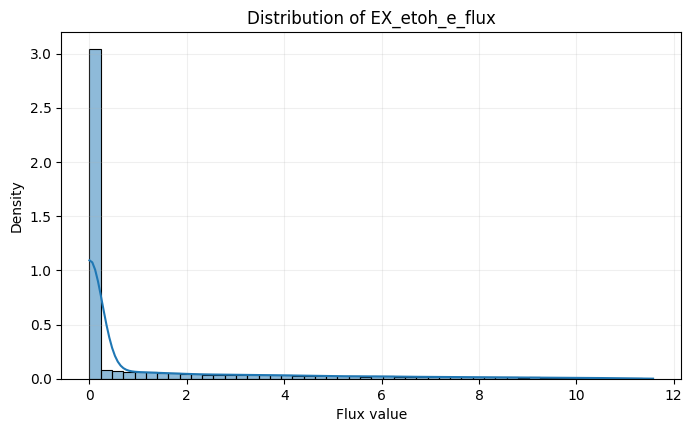

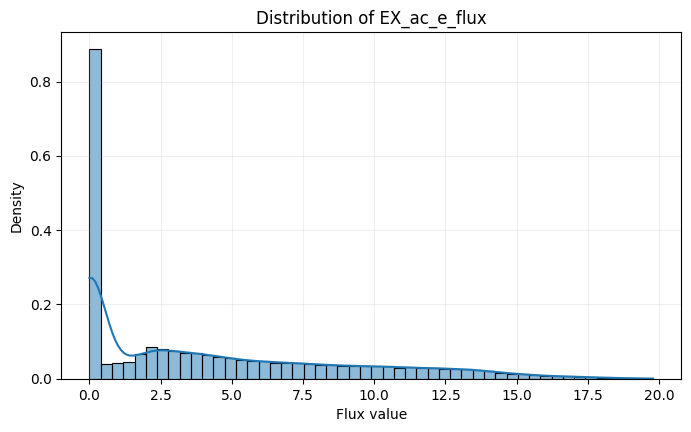

In [42]:
def plot_flux_distribution(y, outputs, flux_name, bins=50, figsize=(8, 4.5)):
    """Plot the distribution of a selected output flux from target tensor y."""
    if flux_name not in outputs:
        raise ValueError(f"{flux_name} not found in outputs.")
    flux_idx = outputs.index(flux_name)
    flux_values = y[:, flux_idx]
    if isinstance(flux_values, torch.Tensor):
        flux_values = flux_values.detach().cpu().numpy()
    else:
        flux_values = np.asarray(flux_values)

    plt.figure(figsize=figsize)
    sns.histplot(flux_values, bins=bins, kde=True, stat="density", color="tab:blue")
    plt.title(f"Distribution of {flux_name}")
    plt.xlabel("Flux value")
    plt.ylabel("Density")
    plt.grid(alpha=0.2)
    plt.show()

#plot_flux_distribution(y, outputs, "BIOMASS_Ec_iML1515_core_75p37M_flux")
plot_flux_distribution(y, outputs, "EX_etoh_e_flux")
plot_flux_distribution(y, outputs, "EX_ac_e_flux")

### Plot Results

In [43]:
today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

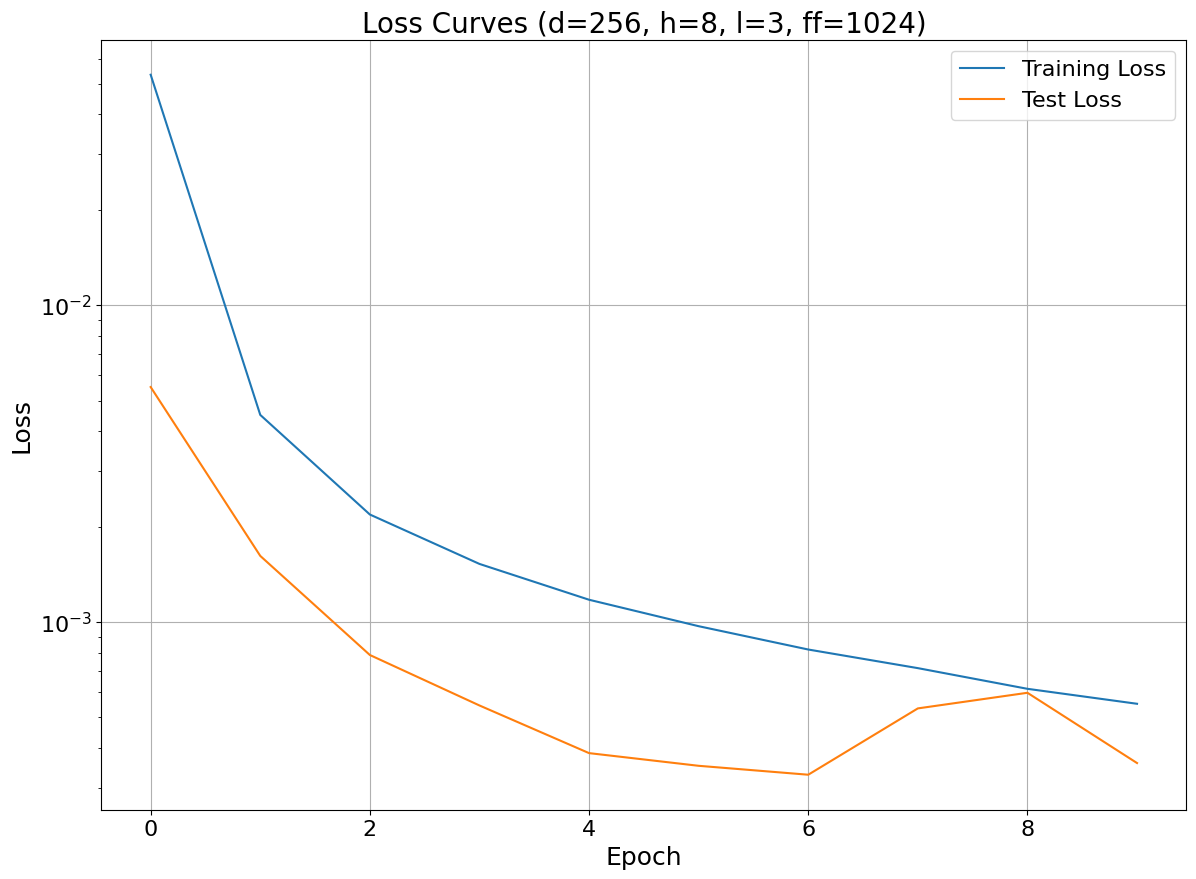

In [44]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

BIOMASS_Ec_iML1515_core_75p37M_flux:
------------------------------------------------------------
BIOMASS_Ec_iML1515_core_75p37M_flux token index: 2668
injected medium slot: False
y_true range: 0.003784395521506667 to 1.2430059909820557
y_pred range: 0.020440518856048584 to 1.352668046951294
R2: 0.9869
MAE: 0.018769
RMSE: 0.023963


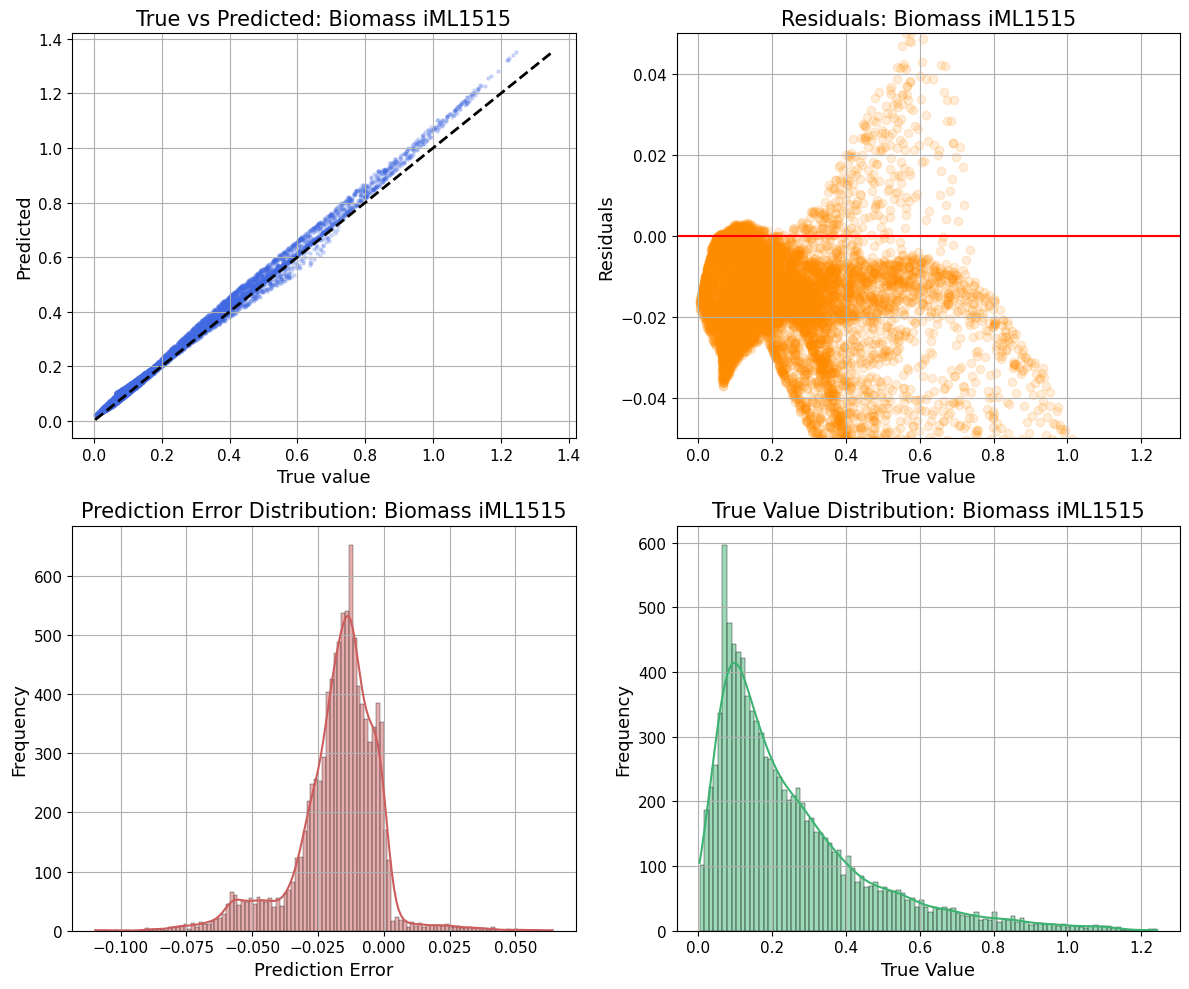

In [45]:
#diagnostics_to_plot = ['BIOMASS_Ec_iML1515_WT_75p37M_flux']
diagnostics_to_plot = ['BIOMASS_Ec_iML1515_core_75p37M_flux']

for flux_name in diagnostics_to_plot:
    save_path = f"{pic_dir}/{flux_name}"
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=save_path)

Plotting 5 diagnostic fluxes
EX_glc__D_e_flux:
------------------------------------------------------------
EX_glc__D_e_flux token index: 180
injected medium slot: True
y_true range: -14.989999771118164 to -0.9990066885948181
y_pred range: -15.034892082214355 to -0.996216893196106
R2: 0.9996
MAE: 0.060692
RMSE: 0.078798


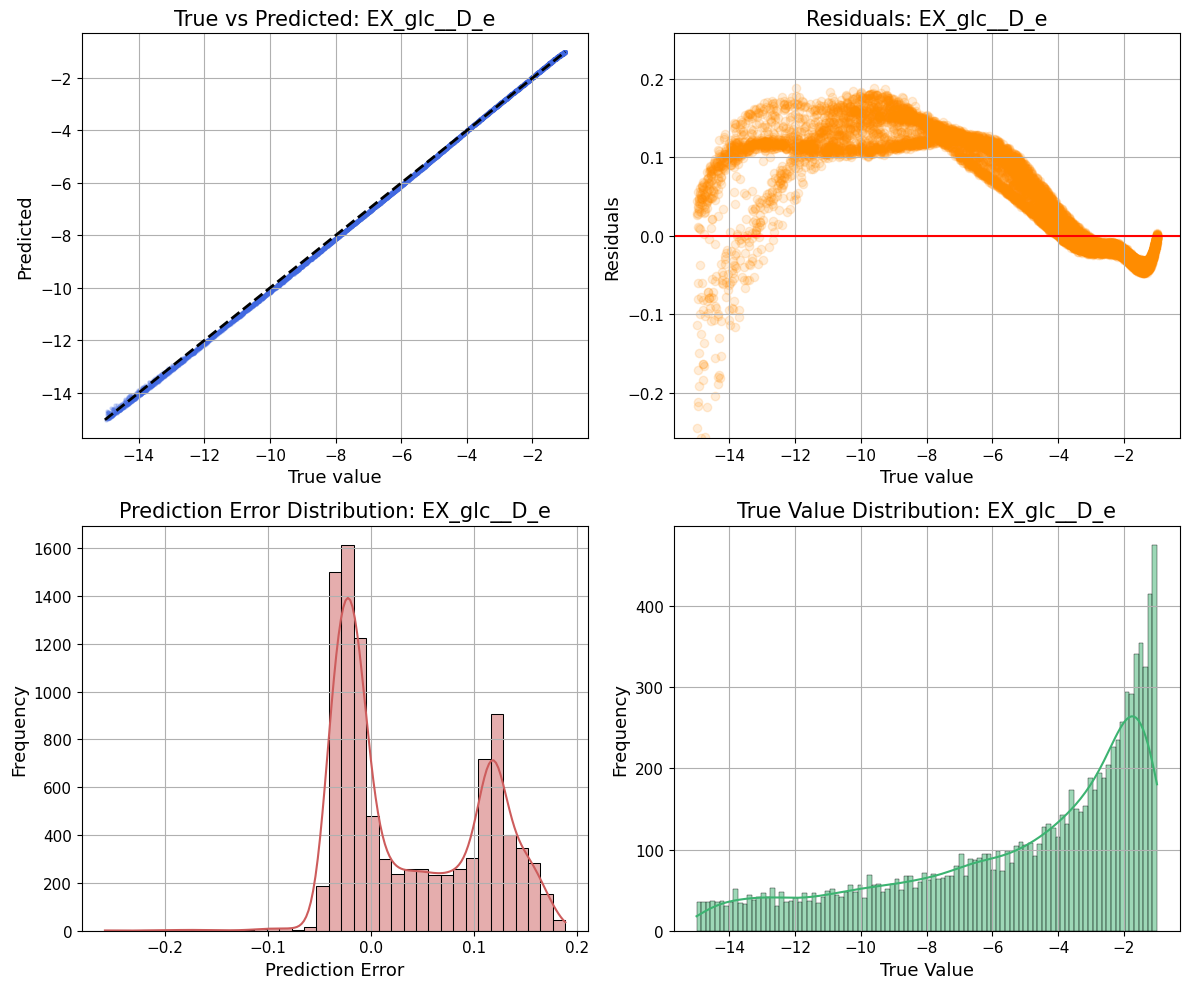

EX_o2_e_flux:
------------------------------------------------------------
EX_o2_e_flux token index: 1981
injected medium slot: True
y_true range: -29.639999389648438 to -1.0
y_pred range: -27.790077209472656 to -0.9595136642456055
R2: 0.9989
MAE: 0.083311
RMSE: 0.161701


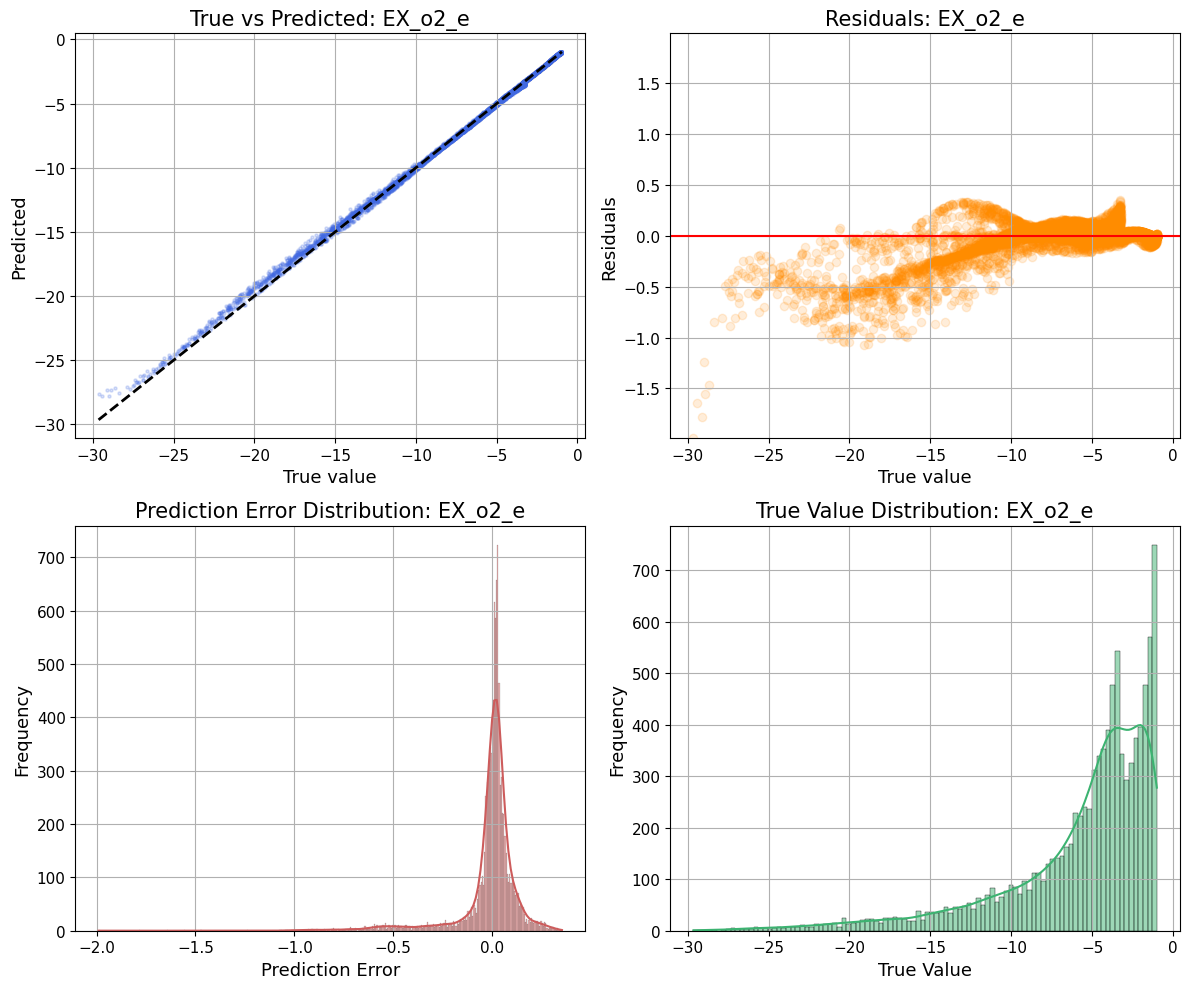

EX_co2_e_flux:
------------------------------------------------------------
EX_co2_e_flux token index: 45
injected medium slot: True
y_true range: 0.0 to 32.292598724365234
y_pred range: -0.030863970518112183 to 31.85979461669922
R2: 0.9999
MAE: 0.033858
RMSE: 0.068387


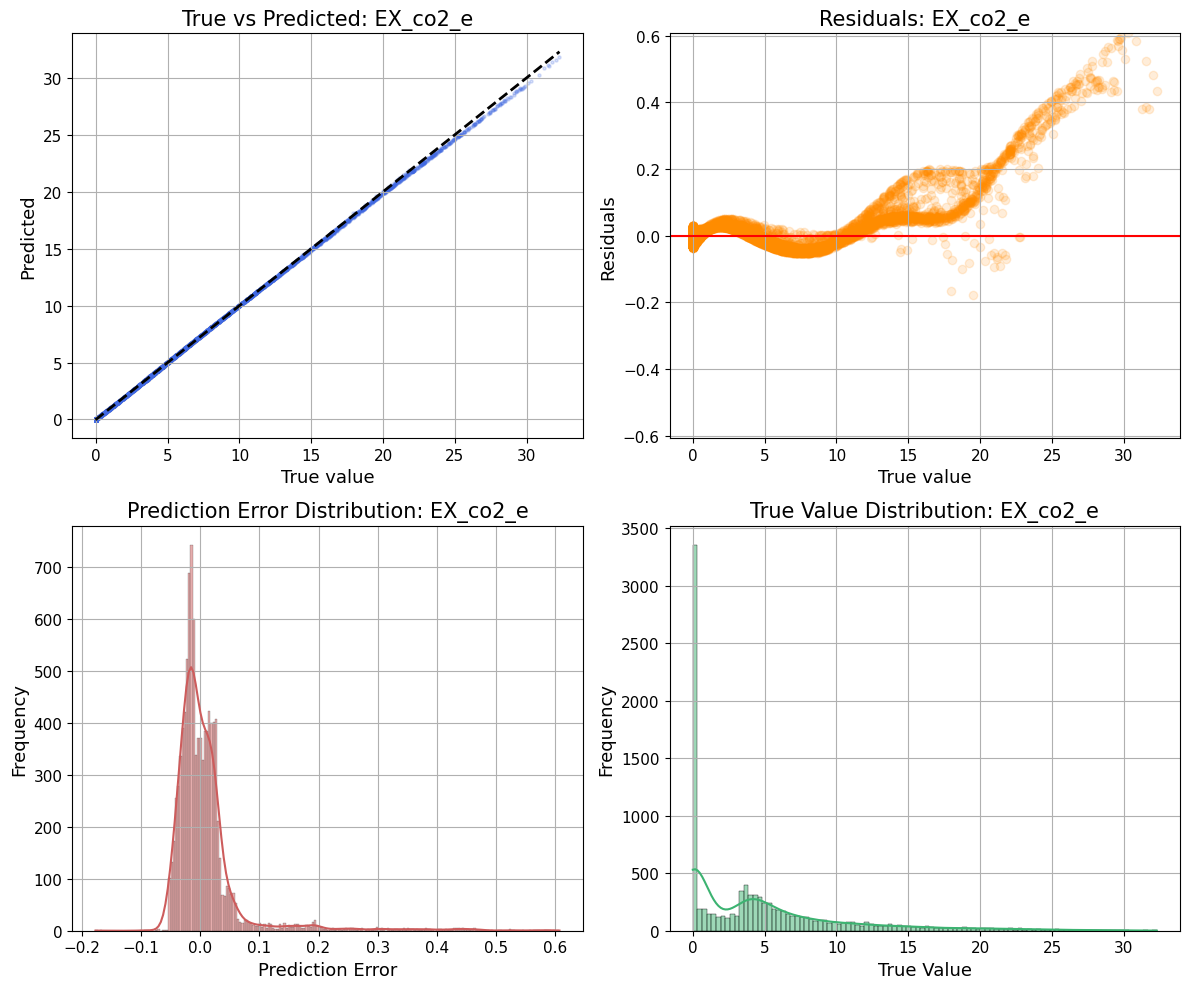

EX_etoh_e_flux:
------------------------------------------------------------
EX_etoh_e_flux token index: 1525
injected medium slot: True
y_true range: -8.258990985461653e-22 to 11.474565505981445
y_pred range: -0.007494211196899414 to 11.180604934692383
R2: 0.9998
MAE: 0.015640
RMSE: 0.029179


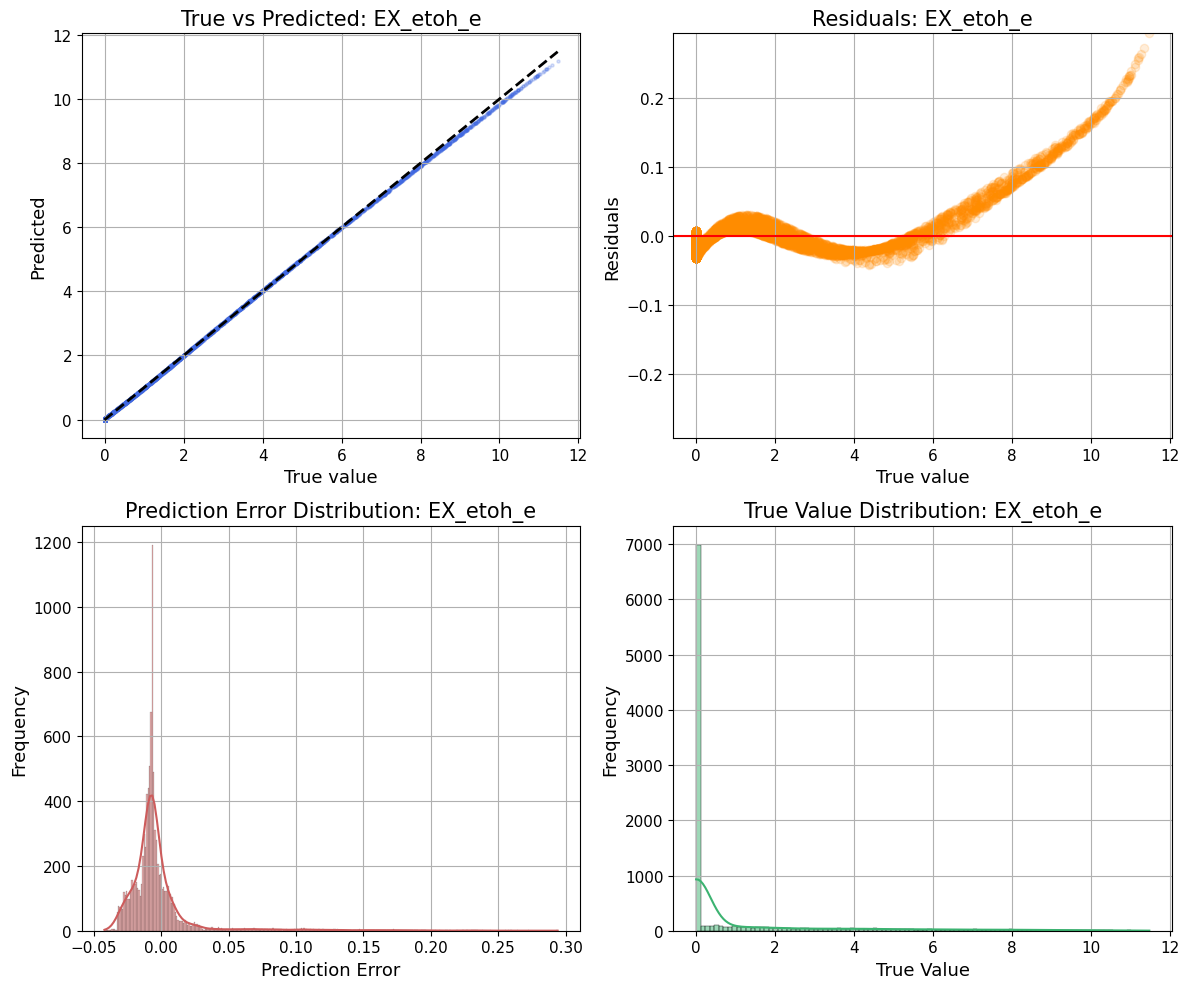

EX_ac_e_flux:
------------------------------------------------------------
EX_ac_e_flux token index: 106
injected medium slot: True
y_true range: 0.0 to 19.594263076782227
y_pred range: -0.014768719673156738 to 18.927345275878906
R2: 0.9999
MAE: 0.026393
RMSE: 0.053299


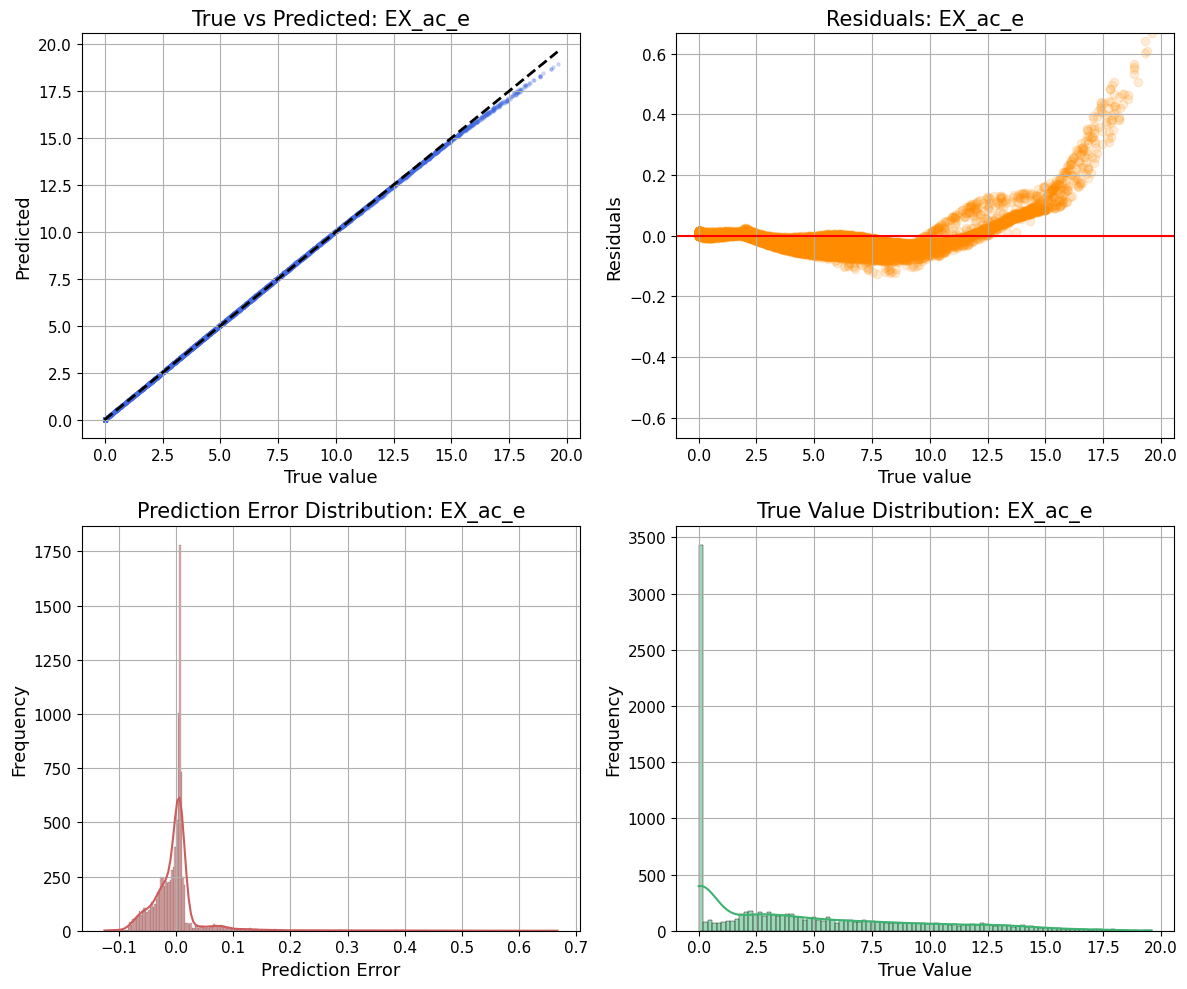

In [46]:
# Diagnostic plots for MINN/reference fluxes.
# False: plot only the 5 MINN reservoir-context fluxes.
# True: plot all 46 non-biomass reference fluxes.
PLOT_ALL_46_FLUX_DIAGNOSTICS = False

target_fluxes_5 = [
    'EX_glc__D_e_flux',
    'EX_o2_e_flux',
    'EX_co2_e_flux',
    'EX_etoh_e_flux',
    'EX_ac_e_flux',
]

target_fluxes_46 = [
    'GLCptspp_flux', 'PGI_flux', 'PFK_flux', 'FBA_flux', 'TPI_flux',
    'PGK_flux', 'GAPD_flux', 'ENO_flux', 'PGM_flux', 'PYK_flux',
    'PDH_flux', 'G6PDH2r_flux', 'PGL_flux', 'GND_flux', 'RPE_flux',
    'RPI_flux', 'TKT1_flux', 'TALA_flux', 'TKT2_flux', 'CS_flux',
    'ACONTb_flux', 'ACONTa_flux', 'ICDHyr_flux', 'SUCOAS_flux', 'AKGDH_flux',
    'SUCDi_flux', 'FUM_flux', 'MDH_flux', 'PPC_flux', 'ME2_flux',
    'ICL_flux', 'MALS_flux', 'ACKr_flux', 'PTAr_flux', 'LDH_D_flux',
    'ACALD_flux', 'ALCD2x_flux', 'EX_glc__D_e_flux', 'EX_o2_e_flux',
    'EX_co2_e_flux', 'EX_etoh_e_flux', 'EX_ac_e_flux', 'EX_lac__D_e_flux',
    'EX_succ_e_flux', 'EX_pyr_e_flux', 'EX_for_e_flux',
]

diagnostics_to_plot = target_fluxes_46 if PLOT_ALL_46_FLUX_DIAGNOSTICS else target_fluxes_5
missing_diagnostic_fluxes = [flux_name for flux_name in diagnostics_to_plot if flux_name not in outputs]
if missing_diagnostic_fluxes:
    raise ValueError('Missing diagnostic flux tokens in outputs: ' + ', '.join(missing_diagnostic_fluxes))

print(f"Plotting {len(diagnostics_to_plot)} diagnostic fluxes")
for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=None)


In [47]:
# Overall model metrics across all output fluxes (flattened)
def _compute_overall_metrics(model_ref, X_ref, y_ref, outputs_ref, device_ref, batch_size_ref):
    model_eval = model_ref.to(device_ref).eval()
    V = len(outputs_ref)

    if X_ref.shape[1] != V or y_ref.shape[1] != V:
        raise ValueError(
            f"Expected X_test/y_test second dim == len(outputs)={V}, got {X_ref.shape[1]} and {y_ref.shape[1]}"
        )

    pred_batches = []
    true_batches = []
    perm = None
    use_amp = device_ref.type == "cuda"

    with torch.inference_mode():
        for i in range(0, X_ref.shape[0], batch_size_ref):
            xb = X_ref[i:i + batch_size_ref].to(device_ref)
            yb_true = y_ref[i:i + batch_size_ref]

            if use_amp:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    preds_all_layers, selected_indices = model_eval(xb.unsqueeze(-1), output_subset=None)
            else:
                preds_all_layers, selected_indices = model_eval(xb.unsqueeze(-1), output_subset=None)

            preds_last = preds_all_layers[:, :, -1]  # (B, S)

            if perm is None:
                selected_indices_np = selected_indices.detach().cpu().numpy()
                if selected_indices_np.ndim > 1:
                    selected_indices_np = selected_indices_np[0]
                selected_indices_np = selected_indices_np.astype(int)

                if selected_indices_np.size != V:
                    raise RuntimeError(f"Model returned {selected_indices_np.size} outputs, expected {V}.")

                inv = np.full(V, -1, dtype=np.int64)
                inv[selected_indices_np] = np.arange(selected_indices_np.size, dtype=np.int64)
                if (inv < 0).any():
                    missing = np.where(inv < 0)[0].tolist()
                    raise RuntimeError(f"Missing output indices in model forward pass: {missing[:10]}")
                perm = torch.as_tensor(inv, device=preds_last.device, dtype=torch.long)

            yb_pred = preds_last.index_select(1, perm).detach().cpu().numpy().astype(np.float32, copy=False)
            pred_batches.append(yb_pred)
            true_batches.append(yb_true.detach().cpu().numpy().astype(np.float32, copy=False))

            del xb, preds_all_layers, preds_last, selected_indices
            if device_ref.type == "cuda":
                torch.cuda.empty_cache()

    y_pred_full = np.concatenate(pred_batches, axis=0)
    y_true_full = np.concatenate(true_batches, axis=0)

    overall_r2 = r2_score(y_true_full.ravel(), y_pred_full.ravel())
    overall_mae = mean_absolute_error(y_true_full.ravel(), y_pred_full.ravel())
    overall_rmse = root_mean_squared_error(y_true_full.ravel(), y_pred_full.ravel())
    return overall_r2, overall_mae, overall_rmse

original_device = next(model.parameters()).device
preferred_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if preferred_device.type == "cuda":
    batch_size_metrics = 2
else:
    batch_size_metrics = 32

used_device = preferred_device
try:
    overall_r2, overall_mae, overall_rmse = _compute_overall_metrics(
        model, X_test, y_test, outputs, preferred_device, batch_size_metrics
    )
except RuntimeError as e:
    if preferred_device.type == "cuda" and "out of memory" in str(e).lower():
        print("CUDA OOM during overall metrics; falling back to CPU...")
        torch.cuda.empty_cache()
        used_device = torch.device("cpu")
        overall_r2, overall_mae, overall_rmse = _compute_overall_metrics(
            model, X_test, y_test, outputs, used_device, 32
        )
    else:
        raise
finally:
    model.to(original_device)

print("Overall model metrics (all fluxes, flattened):")
print(f"Device used: {used_device}")
print(f"R2:   {overall_r2:.4f}")
print(f"MAE:  {overall_mae:.6f}")
print(f"RMSE: {overall_rmse:.6f}")

Overall model metrics (all fluxes, flattened):
Device used: cuda
R2:   0.9995
MAE:  0.008769
RMSE: 0.027590


### FluxTransformer Reservoir Training

This section trains the front MLP that feeds the frozen FluxTransformer reservoir.

This mirrors the MINN repository's reservoir training structure: transcriptomics, proteomics, and measured glucose/oxygen uptake are merged into the front-MLP input matrix. The trainable front MLP maps those inputs to a five-value reservoir vector, and that five-value vector is passed to the frozen pretrained block. In this notebook, the frozen pretrained block is FluxTransformer using the unsplit, unpruned iML1515 reaction/token vocabulary.

Measured glucose and oxygen are therefore inputs to the front MLP, not values copied directly into the FluxTransformer input vector. FluxTransformer still receives a full vocabulary-sized input vector: the five reservoir-context positions are filled with front-MLP predictions for glucose, oxygen, CO2, ethanol, and acetate; the configured base-exchange positions are filled with fixed medium/background values; all remaining positions are set to zero.

The downstream pFBA evaluation is a separate comparison step. The baseline pFBA row uses only measured glucose and oxygen uptake as constraints. In the current comparison variant, the FluxTransformer + pFBA row uses the same measured glucose and oxygen constraints, and additionally applies selected out-of-fold front-MLP predictions as secretion upper caps.


In [48]:
from pathlib import Path


def _minn_to_flux_token(rxn_name: str, outputs_vocab):
    """Map MINN reaction naming to FluxTransformer token names (+ sign conversion for *_rev)."""
    if rxn_name.startswith("R_BIOMASS"):
        if "BIOMASS_Ec_iML1515_WT_75p37M_flux" in outputs_vocab:
            return "BIOMASS_Ec_iML1515_WT_75p37M_flux", 1.0
        if "BIOMASS_Ec_iML1515_core_75p37M_flux" in outputs_vocab:
            return "BIOMASS_Ec_iML1515_core_75p37M_flux", 1.0

    base = rxn_name
    if base.startswith("R_"):
        base = base[2:]

    sign = 1.0
    if base.endswith("_fwd"):
        base = base[:-4]
    elif base.endswith("_rev"):
        base = base[:-4]
        sign = -1.0

    tok = f"{base}_flux"
    if tok in outputs_vocab:
        return tok, sign
    return None, None


# ----- FluxTransformer reservoir settings -----
MINN_DATA_DIR = "./MINN_data"
MINN_FLUXOMICS_FILE = "fluxomics_iAF1260_reduced_split_fit.csv"

# 2 measured medium inputs (same as MINN dataset config)
MINN_INPUT_FLUX_COLS = ["R_EX_glc__D_e_rev", "R_EX_o2_e_rev"]
MINN_MEASURED_CONTEXT_SOURCE = list(MINN_INPUT_FLUX_COLS)

# CO2/ethanol/acetate are the learned reservoir channels supervised during training.
MINN_LEARNED_CONSTRAINT_SOURCE = [
    "R_EX_co2_e_fwd",
    "R_EX_etoh_e",
    "R_EX_ac_e",
]

# Downstream pFBA comparison mode. Reservoir training still learns all 3 added channels.
# Predicted extra exchanges are treated as nonnegative secretion upper caps, not exact fluxes.
MINN_PFBA_EXTRA_CONSTRAINT_MODE = "co2_etoh_ac_cap"  # "etoh_ac_cap" or "co2_etoh_ac_cap"
MINN_PFBA_EXTRA_CONSTRAINTS_BY_MODE = {
    "etoh_ac_cap": ["R_EX_etoh_e", "R_EX_ac_e"],
    "co2_etoh_ac_cap": ["R_EX_co2_e_fwd", "R_EX_etoh_e", "R_EX_ac_e"],
}
if MINN_PFBA_EXTRA_CONSTRAINT_MODE not in MINN_PFBA_EXTRA_CONSTRAINTS_BY_MODE:
    raise ValueError(
        f"MINN_PFBA_EXTRA_CONSTRAINT_MODE must be one of {sorted(MINN_PFBA_EXTRA_CONSTRAINTS_BY_MODE)}"
    )
MINN_PFBA_EXTRA_CONSTRAINT_SOURCE = list(MINN_PFBA_EXTRA_CONSTRAINTS_BY_MODE[MINN_PFBA_EXTRA_CONSTRAINT_MODE])
MINN_PFBA_PRED_COL_BY_SOURCE = {
    "R_EX_co2_e_fwd": "R_EX_co2_e_fwd_pred",
    "R_EX_etoh_e": "R_EX_etoh_e_pred",
    "R_EX_ac_e": "R_EX_ac_e_pred",
}
MINN_PFBA_RXN_BY_SOURCE = {
    "R_EX_co2_e_fwd": "EX_co2_e",
    "R_EX_etoh_e": "EX_etoh_e",
    "R_EX_ac_e": "EX_ac_e",
}

# Full 5-channel reservoir context passed into FluxTransformer.
MINN_RESERVOIR_CONTEXT_SOURCE = MINN_MEASURED_CONTEXT_SOURCE + MINN_LEARNED_CONSTRAINT_SOURCE

# base_exchanges from generate_ecoli_iML1515_MINN_data.py
BASE_EXCHANGES = [
    "EX_pi_e",
    "EX_co2_e",
    "EX_h_e",
    "EX_mn2_e",
    "EX_fe2_e",
    "EX_zn2_e",
    "EX_mg2_e",
    "EX_ca2_e",
    "EX_ni2_e",
    "EX_cu2_e",
    "EX_cobalt2_e",
    "EX_h2o_e",
    "EX_mobd_e",
    "EX_so4_e",
    "EX_nh4_e",
    "EX_k_e",
    "EX_na1_e",
    "EX_cl_e",
    "EX_o2_e",
    "EX_fe3_e",
    "EX_sel_e",
    "EX_tungs_e",
    "EX_slnt_e",
    "EX_cbl1_e",
]
DEFAULT_BASE_EXCHANGE_RATE = 50.0
PFBA_EXTRA_CONSTRAINT_TOL = 1e-6

# pFBA objective choice matters. The iML1515 SBML default is core biomass;
# keep that as the Table 4-style default unless explicitly changed.
PFBA_OBJECTIVE_VARIANT = globals().get("PFBA_OBJECTIVE_VARIANT", "core")  # "core" or "wt"
PFBA_OBJECTIVE_RXN_BY_VARIANT = {
    "core": "BIOMASS_Ec_iML1515_core_75p37M",
    "wt": "BIOMASS_Ec_iML1515_WT_75p37M",
}
if PFBA_OBJECTIVE_VARIANT not in PFBA_OBJECTIVE_RXN_BY_VARIANT:
    raise ValueError(f"PFBA_OBJECTIVE_VARIANT must be one of {sorted(PFBA_OBJECTIVE_RXN_BY_VARIANT)}")
PFBA_OBJECTIVE_RXN = PFBA_OBJECTIVE_RXN_BY_VARIANT[PFBA_OBJECTIVE_VARIANT]
PFBA_BIOMASS_METRIC_TOKEN = f"{PFBA_OBJECTIVE_RXN}_flux"


def load_minn_omics_for_reservoir(data_dir: str, outputs_vocab):
    """
    Load MINN-style input (omics + 2 measured fluxes) and build the 5-channel
    reservoir context labels mapped into FluxTransformer token space.
    """
    data_dir_p = Path(data_dir)
    transcript_path = data_dir_p / "transcriptomics.csv"
    proteomics_path = data_dir_p / "proteomics.csv"
    fluxomics_path = data_dir_p / MINN_FLUXOMICS_FILE

    if not transcript_path.exists() or not proteomics_path.exists() or not fluxomics_path.exists():
        raise FileNotFoundError(
            f"Expected MINN files in {data_dir}: transcriptomics.csv, proteomics.csv, {MINN_FLUXOMICS_FILE}"
        )

    tr = pd.read_csv(transcript_path)
    pr = pd.read_csv(proteomics_path)
    fl = pd.read_csv(fluxomics_path)

    # MINN-style merge
    x_df = tr.merge(pr, on="experiment", how="left")

    missing_input = [c for c in MINN_INPUT_FLUX_COLS if c not in fl.columns]
    if missing_input:
        raise ValueError(f"Missing MINN input flux columns: {missing_input}")

    x_df = x_df.merge(fl[["experiment"] + MINN_INPUT_FLUX_COLS], on="experiment", how="left")
    x_df = x_df[x_df["experiment"].isin(fl["experiment"])].reset_index(drop=True)

    fl_idx = fl.set_index("experiment")

    mapped = []  # (source_col, token_name, token_idx, sign)
    for source_col in MINN_RESERVOIR_CONTEXT_SOURCE:
        if source_col not in fl.columns:
            raise ValueError(f"Missing target source column in fluxomics file: {source_col}")
        tok, sign = _minn_to_flux_token(source_col, outputs_vocab)
        if tok is None:
            raise RuntimeError(f"Could not map {source_col} into FluxTransformer token vocabulary")
        mapped.append((source_col, tok, outputs_vocab.index(tok), sign))

    # Inputs
    x_features = [c for c in x_df.columns if c != "experiment"]
    X_np = x_df[x_features].to_numpy(dtype=np.float32)

    # Targets/context labels (5), mapped with sign for FluxTransformer output-space loss.
    experiments = x_df["experiment"].tolist()
    y_rows = []
    for exp in experiments:
        row = []
        for src, _tok, _idx, sign in mapped:
            row.append(float(fl_idx.at[exp, src]) * sign)
        y_rows.append(row)

    y_np = np.asarray(y_rows, dtype=np.float32)

    target_token_names = [tok for _src, tok, _idx, _sign in mapped]
    target_token_indices = [idx for _src, _tok, idx, _sign in mapped]

    return X_np, y_np, x_features, target_token_names, target_token_indices, mapped, experiments


(
    X_minn_np,
    y_minn_np,
    minn_feature_names,
    minn_target_token_names,
    minn_target_indices,
    minn_mapped_sources,
    minn_experiments,
) = load_minn_omics_for_reservoir(
    data_dir=MINN_DATA_DIR,
    outputs_vocab=outputs,
)

minn_target_indices_t = torch.tensor(minn_target_indices, dtype=torch.long, device=device)
# Signs used in MINN source naming (*_rev -> -1). Needed to recover positive constraint magnitudes for front-MLP supervision.
minn_target_signs = np.asarray([float(sign) for _src, _tok, _idx, sign in minn_mapped_sources], dtype=np.float32)
minn_target_signs_t = torch.tensor(minn_target_signs, dtype=torch.float32, device=device)

minn_source_to_context_position = {src: i for i, (src, _tok, _idx, _sign) in enumerate(minn_mapped_sources)}
minn_mapped_by_source = {src: (tok, idx, sign) for src, tok, idx, sign in minn_mapped_sources}
minn_learned_context_positions = [minn_source_to_context_position[src] for src in MINN_LEARNED_CONSTRAINT_SOURCE]
minn_learned_context_positions_t = torch.tensor(minn_learned_context_positions, dtype=torch.long, device=device)
minn_learned_token_names = [minn_mapped_by_source[src][0] for src in MINN_LEARNED_CONSTRAINT_SOURCE]
minn_measured_token_names = [minn_mapped_by_source[src][0] for src in MINN_MEASURED_CONTEXT_SOURCE]
minn_measured_feature_indices = [minn_feature_names.index(src) for src in MINN_MEASURED_CONTEXT_SOURCE]

# Build fixed base exchange constraints in FluxTransformer token space.
# Rules for the full input vector assembled inside the wrapper:
# - the 5 reservoir-context token positions are filled from front-MLP predictions
# - base_exchanges outside those 5 context tokens are fixed at DEFAULT_BASE_EXCHANGE_RATE
# - all other token positions are zero
context_token_set = set(minn_target_token_names)
fixed_base_token_values = {}
for ex in BASE_EXCHANGES:
    tok = f"{ex}_flux"
    if tok in outputs and tok not in context_token_set:
        fixed_base_token_values[tok] = float(DEFAULT_BASE_EXCHANGE_RATE)


class FrozenFluxTransformerWithMLP(nn.Module):
    """
    FluxTransformer reservoir wrapper:
    - Front MLP predicts the full 5-channel reservoir context
    - Full FluxTransformer input vector is assembled as:
        predicted 5 + fixed base_exchanges + zeros elsewhere
    - Frozen pretrained FluxTransformer

    pFBA evaluation later keeps measured glucose/oxygen measured and applies
    selected predicted secretion channels as upper-cap constraints.
    """
    def __init__(
        self,
        flux_transformer: nn.Module,
        input_dim: int,
        predicted_token_names,
        fixed_base_token_values,
        hidden_dim: int = 512,
        drop_rate: float = 0.25,
    ):
        super().__init__()
        self.frozen_flux_transformer = flux_transformer
        self.vocab_size = int(self.frozen_flux_transformer.vocab_size)

        self.predicted_token_names = list(predicted_token_names)
        self.fixed_base_token_values = dict(fixed_base_token_values)

        token_to_idx = {tok: i for i, tok in enumerate(outputs)}
        pred_indices = []
        for tok in self.predicted_token_names:
            if tok not in token_to_idx:
                raise ValueError(f"Predicted token not found in outputs vocab: {tok}")
            pred_indices.append(token_to_idx[tok])

        fixed_names = []
        fixed_vals = []
        for tok, val in self.fixed_base_token_values.items():
            if tok in token_to_idx:
                fixed_names.append(tok)
                fixed_vals.append(float(val))

        self.register_buffer("predicted_indices", torch.tensor(pred_indices, dtype=torch.long), persistent=True)
        self.register_buffer("fixed_indices", torch.tensor([token_to_idx[t] for t in fixed_names], dtype=torch.long), persistent=True)
        self.register_buffer("fixed_values", torch.tensor(fixed_vals, dtype=torch.float32), persistent=True)

        for p in self.frozen_flux_transformer.parameters():
            p.requires_grad = False
        self.frozen_flux_transformer.eval()

        # Predict exactly the 5 channels used by the pretrained reservoir block.
        self.front_mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(drop_rate),
            nn.Linear(hidden_dim, len(self.predicted_token_names)),
        )

    def train(self, mode: bool = True):
        super().train(mode)
        self.frozen_flux_transformer.eval()
        return self

    def build_full_input_vector(self, x):
        # x: [B, n_features]
        pred_raw = self.front_mlp(x)  # [B, 5]
        pred_vals = F.softplus(pred_raw)  # keep constraints non-negative

        B = x.size(0)
        c0 = torch.zeros(B, self.vocab_size, dtype=x.dtype, device=x.device)

        if self.fixed_indices.numel() > 0:
            c0[:, self.fixed_indices] = self.fixed_values.to(dtype=x.dtype, device=x.device).unsqueeze(0)

        c0[:, self.predicted_indices] = pred_vals
        return c0

    def forward(self, x, output_subset=None, return_embedding=False):
        if x.dim() == 3 and x.size(-1) == 1:
            x = x.squeeze(-1)
        c0 = self.build_full_input_vector(x).unsqueeze(-1)
        return self.frozen_flux_transformer(c0, output_subset=output_subset, return_embedding=return_embedding)


# Build model
minn_model = FrozenFluxTransformerWithMLP(
    flux_transformer=model,
    input_dim=X_minn_np.shape[1],
    predicted_token_names=minn_target_token_names,
    fixed_base_token_values=fixed_base_token_values,
    hidden_dim=512,
    drop_rate=0.25,
).to(device)

with torch.no_grad():
    _x2 = torch.tensor(X_minn_np[:2], dtype=torch.float32, device=device)
    _c0_sanity = minn_model.build_full_input_vector(_x2)
    _pred_sanity, _sel_sanity = minn_model(_x2, output_subset=None)

trainable_params = sum(p.numel() for p in minn_model.parameters() if p.requires_grad)
frozen_flux_params = sum(p.numel() for p in minn_model.frozen_flux_transformer.parameters() if not p.requires_grad)

print("Loaded MINN-style omics dataset")
print(f"MINN data dir: {MINN_DATA_DIR}")
print(f"Samples: {X_minn_np.shape[0]}")
print(f"Input features (omics + 2 measured fluxes): {X_minn_np.shape[1]}")
print("Measured context flux columns:", MINN_MEASURED_CONTEXT_SOURCE)
print("5 front-MLP reservoir context source fluxes:", MINN_RESERVOIR_CONTEXT_SOURCE)
print("pFBA extra predicted constraint mode:", MINN_PFBA_EXTRA_CONSTRAINT_MODE)
print("pFBA extra predicted constraints:", MINN_PFBA_EXTRA_CONSTRAINT_SOURCE)
print("Mapped context token names:", minn_target_token_names)
print("MINN source -> FluxTransformer token mapping (with sign)")
for src, tok, idx, sign in minn_mapped_sources:
    print(f"  {src:>18} -> {tok:<20} idx={idx:4d} sign={sign:+.0f}")
print("Measured input feature positions:", dict(zip(MINN_MEASURED_CONTEXT_SOURCE, minn_measured_feature_indices)))
print(f"Fixed base exchange token count: {len(fixed_base_token_values)} (value={DEFAULT_BASE_EXCHANGE_RATE})")
print(f"Trainable params (front MLP only): {trainable_params:,}")
print(f"Frozen FluxTransformer params:      {frozen_flux_params:,}")
print(f"Sanity c0 shape:                   {tuple(_c0_sanity.shape)}")
print(f"Sanity transformer output shape:   {tuple(_pred_sanity.shape)}")


Loaded MINN-style omics dataset
MINN data dir: ./MINN_data
Samples: 29
Input features (omics + 2 measured fluxes): 141
Measured context flux columns: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev']
5 front-MLP reservoir context source fluxes: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev', 'R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
pFBA extra predicted constraint mode: co2_etoh_ac_cap
pFBA extra predicted constraints: ['R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
Mapped context token names: ['EX_glc__D_e_flux', 'EX_o2_e_flux', 'EX_co2_e_flux', 'EX_etoh_e_flux', 'EX_ac_e_flux']
MINN source -> FluxTransformer token mapping (with sign)
   R_EX_glc__D_e_rev -> EX_glc__D_e_flux     idx= 180 sign=-1
       R_EX_o2_e_rev -> EX_o2_e_flux         idx=1981 sign=-1
      R_EX_co2_e_fwd -> EX_co2_e_flux        idx=  45 sign=+1
         R_EX_etoh_e -> EX_etoh_e_flux       idx=1525 sign=+1
           R_EX_ac_e -> EX_ac_e_flux         idx= 106 sign=+1
Measured input feature positions: {'R_EX_glc__D_e_rev': 139, 'R

In [49]:
# Assertions: token/reaction mapping and sign conventions for MINN -> iML1515 integration

import xml.etree.ElementTree as ET
from pathlib import Path

# 1) Required predicted tokens must exist in outputs vocab
required_pred_tokens = [
    "EX_glc__D_e_flux",
    "EX_o2_e_flux",
    "EX_co2_e_flux",
    "EX_etoh_e_flux",
    "EX_ac_e_flux",
]

missing_pred_tokens = [t for t in required_pred_tokens if t not in outputs]
assert not missing_pred_tokens, (
    "Missing required predicted tokens in outputs vocab: "
    + ", ".join(missing_pred_tokens)
)

# 2) Base exchange tokens must exist in outputs vocab
base_tokens = [f"{ex}_flux" for ex in BASE_EXCHANGES]
missing_base_tokens = [t for t in base_tokens if t not in outputs]
assert not missing_base_tokens, (
    "Missing base exchange tokens in outputs vocab: "
    + ", ".join(missing_base_tokens)
)

# 3) pFBA-constrained reactions must exist in iML1515 model
model_path = Path("./models/iML1515.xml")
assert model_path.exists(), f"SBML model not found: {model_path}"

ns = {"sbml": "http://www.sbml.org/sbml/level3/version1/core"}
root = ET.parse(model_path).getroot()
rxn_ids = [r.attrib.get("id", "") for r in root.findall('.//sbml:listOfReactions/sbml:reaction', ns)]
rxn_ids_norm = {(rid[2:] if rid.startswith("R_") else rid) for rid in rxn_ids}

required_pfba_rxns = ["EX_glc__D_e", "EX_o2_e", "EX_co2_e", "EX_etoh_e", "EX_ac_e"]
missing_rxns = [r for r in required_pfba_rxns if r not in rxn_ids_norm]
assert not missing_rxns, "Missing required pFBA reactions in iML1515 model: " + ", ".join(missing_rxns)

# 4) MINN context columns used as FluxTransformer input constraints should be nonnegative magnitudes
fluxomics_path = Path(MINN_DATA_DIR) / MINN_FLUXOMICS_FILE
assert fluxomics_path.exists(), f"Fluxomics file not found: {fluxomics_path}"

fl_check = pd.read_csv(fluxomics_path)
for col in MINN_RESERVOIR_CONTEXT_SOURCE:
    assert col in fl_check.columns, f"Expected sign-check column missing: {col}"
    cmin = float(fl_check[col].min())
    assert cmin >= -1e-9, f"Column {col} has negative values (min={cmin}), sign assumption broken."

# 5) Explicitly lock the reservoir-context source -> iML1515 token/sign mapping.
expected_context_mapping = {
    "R_EX_glc__D_e_rev": ("EX_glc__D_e_flux", -1.0),
    "R_EX_o2_e_rev": ("EX_o2_e_flux", -1.0),
    "R_EX_co2_e_fwd": ("EX_co2_e_flux", 1.0),
    "R_EX_etoh_e": ("EX_etoh_e_flux", 1.0),
    "R_EX_ac_e": ("EX_ac_e_flux", 1.0),
}
observed_context_mapping = {src: (tok, float(sign)) for src, tok, _idx, sign in minn_mapped_sources}
assert observed_context_mapping == expected_context_mapping, (
    "Unexpected reservoir-context mapping/signs: " + str(observed_context_mapping)
)

# 6) Mapping coverage sanity for measured flux columns used in metrics
metric_source_cols = [c for c in fl_check.columns if c != "experiment"]
unmapped = []
for src in metric_source_cols:
    tok, sign = _minn_to_flux_token(src, outputs)
    if tok is None:
        unmapped.append(src)
    else:
        assert sign in (-1.0, 1.0), f"Unexpected sign {sign} for {src}"

assert not unmapped, "Some measured flux columns could not map into iML1515 token space: " + ", ".join(unmapped[:20])

print("Assertions passed: token existence, reaction existence, mapping coverage, and sign conventions are consistent.")


Assertions passed: token existence, reaction existence, mapping coverage, and sign conventions are consistent.


CUDA detected: overriding batch_size 5 -> 2 to avoid OOM with full-output forward.
Aux-loss sweep configuration
  channel-weight mode: equal
  channel weights: {'R_EX_glc__D_e_rev': 1.0, 'R_EX_o2_e_rev': 1.0, 'R_EX_co2_e_fwd': 1.0, 'R_EX_etoh_e': 1.0, 'R_EX_ac_e': 1.0}

Available auxiliary channel-weight modes


,R_EX_glc__D_e_rev,R_EX_o2_e_rev,R_EX_co2_e_fwd,R_EX_etoh_e,R_EX_ac_e
equal,1.0,1.0,1.0,1.0,1.0
etoh_ac_emphasized,1.0,1.0,1.0,2.0,2.0
etoh_ac_only,0.0,0.0,0.0,1.0,1.0


c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-30 08:27:48,583] A new study created in memory with name: no-name-2a3a9751-20d4-4d62-9305-30bbaaa06948


  fixed aux+hyperparams: False
  aux grid: [0.3, 0.35, 0.4, 0.45, 0.5]
  HPO once: True
  redo HPO per aux weight: False
Running one-time global HPO on full dataset...


[I 2026-05-30 08:35:48,711] Trial 0 finished with value: 0.8420959136974535 and parameters: {'drop_rate': 0.0, 'learning_rate': 0.00184797049710708, 'weight_decay': 9.499998022702225e-06}. Best is trial 0 with value: 0.8420959136974535.
[I 2026-05-30 08:42:09,923] Trial 1 finished with value: 0.7732429672399277 and parameters: {'drop_rate': 0.0, 'learning_rate': 0.00279695071410329, 'weight_decay': 0.0006405214533017087}. Best is trial 1 with value: 0.7732429672399277.
[I 2026-05-30 08:47:59,933] Trial 2 finished with value: 0.7402207187537347 and parameters: {'drop_rate': 0.25, 'learning_rate': 0.003226878079693836, 'weight_decay': 0.00022955120063380515}. Best is trial 2 with value: 0.7402207187537347.
[I 2026-05-30 08:55:57,344] Trial 3 finished with value: 0.8419244697921413 and parameters: {'drop_rate': 0.0, 'learning_rate': 0.0014674692565520351, 'weight_decay': 4.2454466496665834e-07}. Best is trial 2 with value: 0.7402207187537347.
[I 2026-05-30 09:03:13,823] Trial 4 finished w

...

,aux_weight,source_flux,mapped_token,target_index,sign,R2,MAE,RMSE,NE
0,0.30,R_EX_ac_e,EX_ac_e_flux,106,1.0,-0.069812,0.095820,0.373405,1.007437
1,0.35,R_EX_ac_e,EX_ac_e_flux,106,1.0,-0.067579,0.094557,0.373015,1.006385
2,0.40,R_EX_ac_e,EX_ac_e_flux,106,1.0,-0.070688,0.098067,0.373558,1.007849
3,0.45,R_EX_ac_e,EX_ac_e_flux,106,1.0,-0.072648,0.100308,0.373900,1.008771
4,0.50,R_EX_ac_e,EX_ac_e_flux,106,1.0,-0.067634,0.095929,0.373025,1.006410
5,0.30,R_EX_co2_e_fwd,EX_co2_e_flux,45,1.0,0.910421,0.582589,0.921425,0.107614
6,0.35,R_EX_co2_e_fwd,EX_co2_e_flux,45,1.0,0.856818,0.676155,1.164937,0.136054
7,0.40,R_EX_co2_e_fwd,EX_co2_e_flux,45,1.0,0.902458,0.629839,0.961508,0.112296
8,0.45,R_EX_co2_e_fwd,EX_co2_e_flux,45,1.0,0.684599,0.949985,1.728976,0.201929
9,0.50,R_EX_co2_e_fwd,EX_co2_e_flux,45,1.0,0.817320,0.763081,1.315838,0.153678


pFBA aux selection model ready: BIOMASS_Ec_iML1515_core_75p37M

=== Aux-weight comparison: final FluxTransformer->pFBA metrics ===


,aux_weight,n_eval,n_total,pfba_R2_avg,pfba_R2_std,pfba_MAE_avg,pfba_MAE_std,pfba_RMSE_avg,pfba_RMSE_std,pfba_NE_avg,pfba_NE_std
0,0.35,29,29,0.889552,0.111101,0.510728,0.390196,0.852329,0.653360,0.306095,0.314890
1,0.30,29,29,0.888320,0.111310,0.513437,0.372937,0.860720,0.639363,0.307936,0.309453
2,0.40,29,29,0.887150,0.111861,0.514933,0.370928,0.864718,0.631261,0.309531,0.311175
3,0.50,29,29,0.885832,0.112229,0.522102,0.379911,0.862689,0.621463,0.312433,0.321687
4,0.45,29,29,0.872365,0.129956,0.534597,0.391416,0.900718,0.632727,0.325574,0.329895


Selected by pFBA metrics -> aux_weight=0.35

Selected aux weight for downstream cells: 0.35 | mode= pfba
=== MINN-style nested CV summary (selected) ===
LOO mean R2:   0.956279 +/- 0.095738
LOO mean MAE:  0.574558 +/- 0.501202
LOO mean RMSE: 0.908678 +/- 0.853787
LOO mean NE:   0.146232 +/- 0.124516
Pooled OOF R2:   0.960940
Pooled OOF MAE:  0.574558
Pooled OOF RMSE: 1.236734

Per-LOO validation loss table (selected aux weight)


,epochs_trained,aux_weight,loo_run,sample_idx,val_loss,R2,MAE,RMSE,NE
0,46,0.35,1,0,0.598513,0.959079,0.693914,0.906224,0.199285
1,36,0.35,2,1,1.576204,0.497615,1.374699,2.327081,0.574632
2,30,0.35,3,2,0.019749,0.999386,0.119780,0.176945,0.024545
3,30,0.35,4,3,0.274311,0.994760,0.493294,0.643002,0.071383
4,69,0.35,5,4,1.921219,0.966220,2.065403,2.826517,0.179241
5,66,0.35,6,5,1.615899,0.832286,1.685534,3.103017,0.393628
6,45,0.35,7,6,0.163718,0.990877,0.311320,0.495708,0.095407
7,36,0.35,8,7,0.181258,0.990159,0.384816,0.497676,0.098953
8,36,0.35,9,8,0.011590,0.999054,0.110596,0.134034,0.030587
9,32,0.35,10,9,0.826622,0.924470,0.953746,1.363261,0.262055


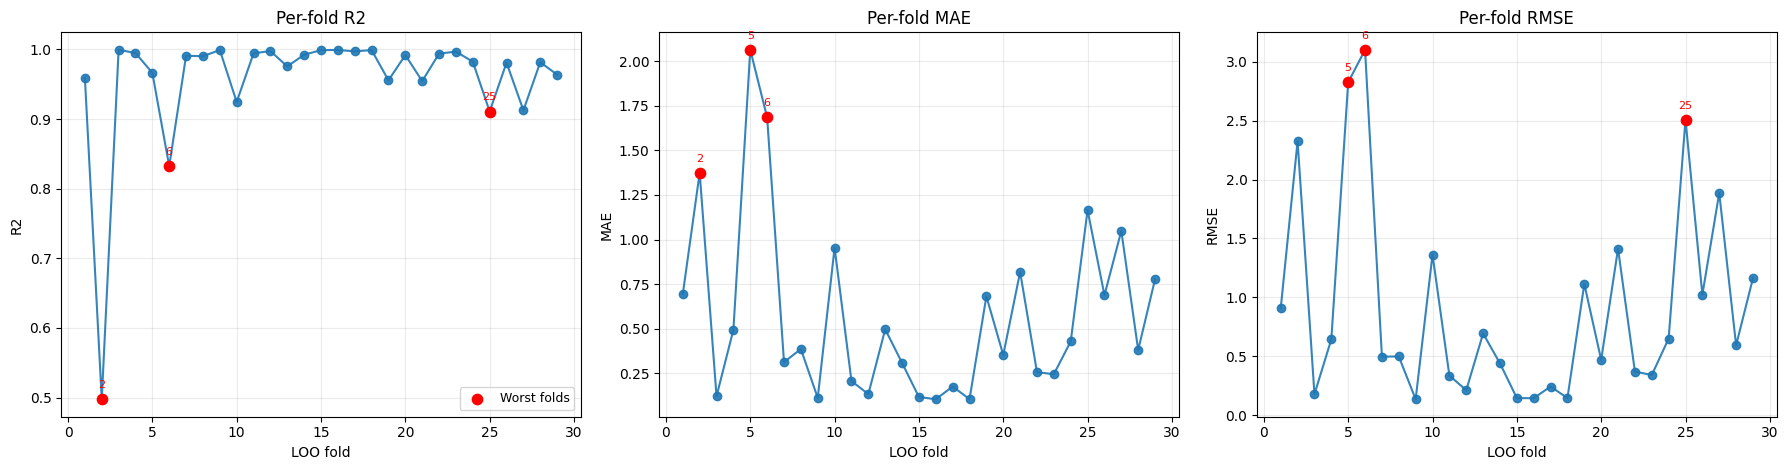


Constraint diagnostics (target magnitude vs front-MLP prediction)
   R_EX_glc__D_e_rev (sign=-1) | target med/mean=3.135200/3.880190 | pred med/mean=3.698890/4.021178
       R_EX_o2_e_rev (sign=-1) | target med/mean=7.953300/9.602582 | pred med/mean=9.093863/9.868145
      R_EX_co2_e_fwd (sign=+1) | target med/mean=7.557200/7.989682 | pred med/mean=7.769954/8.406872
         R_EX_etoh_e (sign=+1) | target med/mean=0.000000/0.011659 | pred med/mean=0.005814/0.010163
           R_EX_ac_e (sign=+1) | target med/mean=0.000000/0.083952 | pred med/mean=0.007877/0.011376


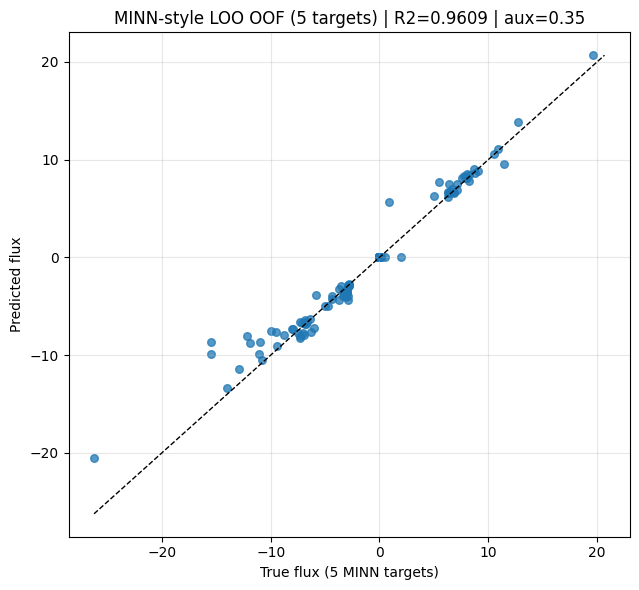

In [50]:
# Train exactly in MINN-repo manner: nested CV
# Outer loop: Leave-One-Out CV
# Inner loop: 5-fold CV hyperparameter search on training split only
# Model specifics here:
# - MLP predicts the same 5-channel reservoir context used by MINN
# - pFBA handoff keeps measured glucose/oxygen measured and adds selected predicted secretion upper caps
# - full transformer input is reconstructed as predicted5 + fixed base_exchanges + zeros
#
# Aux-loss tuning:
# - Compare aux-loss weights [0.1, 0.3, 1.0]
# - Report pooled OOF metrics and per-target metrics for each weight
# - Keep downstream variables bound to the best aux weight by pooled OOF R2

from sklearn.model_selection import LeaveOneOut, KFold
from sklearn.preprocessing import MinMaxScaler

try:
    import optuna
    OPTUNA_AVAILABLE = True
except Exception:
    OPTUNA_AVAILABLE = False

set_seed(12345)

# MINN-style CV/HPO settings
minn_cv_seed = 12345
minn_cv_n_fold = 5
minn_cv_max_trials = 50
minn_cv_epochs = 150
minn_cv_batch_size = 5
minn_cv_early_stopping_patience = 25
minn_cv_early_stopping_min_delta = 1e-5

if device.type == "cuda" and minn_cv_batch_size > 2:
    print("CUDA detected: overriding batch_size 5 -> 2 to avoid OOM with full-output forward.")
    minn_cv_batch_size = 2

search_space = {
    "drop_rate": [0.0, 0.05, 0.1, 0.25],
    "learning_rate": {"low": 5e-4, "high": 5e-3, "log": True},
    "weight_decay": {"low": 1e-8, "high": 1e-3, "log": True},
}

# Optuna objective = mean(inner-fold val loss) + lambda * std(inner-fold val loss)
# (stability-aware global tuning)
MINN_INNER_CV_STD_PENALTY = 0.25

# Training-stability settings
MINN_GRAD_CLIP_MAX_NORM = 1.0
MINN_LR_WARMUP_EPOCHS = max(3, min(10, minn_cv_epochs // 10))
MINN_LR_COSINE_MIN_FACTOR = 0.05

# IMPORTANT: run HPO once globally (not once per LOO split) to avoid extremely long runtimes.
MINN_HPO_ONCE = True

# Fixed run mode: use the latest selected aux weight and HPO parameters, skipping aux-grid and Optuna searches.
MINN_USE_FIXED_AUX_AND_HYPERPARAMS = False
MINN_FIXED_CONSTRAINT_AUX_WEIGHT = 0.5
MINN_FIXED_BEST_PARAMS = {
    "drop_rate": 0.25,
    "learning_rate": 0.0009736777696601047,
    "weight_decay": 4.738391288843704e-05,
}
MINN_FIXED_INNER_CV_OBJECTIVE = 1.1122118454919798

# Aux-loss tuning grid used only when MINN_USE_FIXED_AUX_AND_HYPERPARAMS=False.
MINN_CONSTRAINT_AUX_WEIGHT_GRID = [0.3, 0.35, 0.4, 0.45, 0.5]
MINN_HPO_ANCHOR_AUX_WEIGHT = 0.4

# Per-channel auxiliary-loss mode. Set back to "equal" to reproduce the current baseline behavior.
MINN_AUX_CHANNEL_WEIGHT_MODE = "equal"  # "equal", "etoh_ac_emphasized", or "etoh_ac_only"
MINN_AUX_CHANNEL_WEIGHTS_BY_MODE = {
    "equal": {
        "R_EX_glc__D_e_rev": 1.0,
        "R_EX_o2_e_rev": 1.0,
        "R_EX_co2_e_fwd": 1.0,
        "R_EX_etoh_e": 1.0,
        "R_EX_ac_e": 1.0,
    },
    "etoh_ac_emphasized": {
        "R_EX_glc__D_e_rev": 1.0,
        "R_EX_o2_e_rev": 1.0,
        "R_EX_co2_e_fwd": 1.0,
        "R_EX_etoh_e": 2.0,
        "R_EX_ac_e": 2.0,
    },
    "etoh_ac_only": {
        "R_EX_glc__D_e_rev": 0.0,
        "R_EX_o2_e_rev": 0.0,
        "R_EX_co2_e_fwd": 0.0,
        "R_EX_etoh_e": 1.0,
        "R_EX_ac_e": 1.0,
    },
}
if MINN_AUX_CHANNEL_WEIGHT_MODE not in MINN_AUX_CHANNEL_WEIGHTS_BY_MODE:
    raise ValueError(
        f"MINN_AUX_CHANNEL_WEIGHT_MODE must be one of {sorted(MINN_AUX_CHANNEL_WEIGHTS_BY_MODE)}"
    )
minn_aux_channel_weights = np.asarray(
    [MINN_AUX_CHANNEL_WEIGHTS_BY_MODE[MINN_AUX_CHANNEL_WEIGHT_MODE][src] for src in MINN_RESERVOIR_CONTEXT_SOURCE],
    dtype=np.float32,
)
if float(minn_aux_channel_weights.sum()) <= 0.0:
    raise ValueError("At least one auxiliary channel weight must be positive.")
minn_aux_channel_weights_t = torch.tensor(minn_aux_channel_weights, dtype=torch.float32, device=device)
minn_aux_channel_weight_modes_df = pd.DataFrame.from_dict(
    MINN_AUX_CHANNEL_WEIGHTS_BY_MODE,
    orient="index",
)[MINN_RESERVOIR_CONTEXT_SOURCE]

# Runtime guard used only when fixed run mode is disabled:
# False -> run HPO once on the anchor aux weight, then reuse those hyperparameters for all aux weights.
# True  -> rerun HPO separately for each aux weight.
MINN_REDO_HPO_PER_AUX_WEIGHT = False

# Aux-weight selection criterion for downstream pipeline:
# - "pfba": choose aux by final FluxTransformer->pFBA metrics (Option 2).
# - "oof": choose aux by pooled OOF R2 on 5 supervised targets.
MINN_AUX_WEIGHT_SELECTION_MODE = "pfba"


def _make_model(drop_rate: float, device_obj):
    return FrozenFluxTransformerWithMLP(
        flux_transformer=model,
        input_dim=X_minn_np.shape[1],
        predicted_token_names=minn_target_token_names,
        fixed_base_token_values=fixed_base_token_values,
        hidden_dim=512,
        drop_rate=drop_rate,
    ).to(device_obj)


def _safe_r2(y_true_np, y_pred_np):
    y_true_np = np.asarray(y_true_np, dtype=np.float64)
    y_pred_np = np.asarray(y_pred_np, dtype=np.float64)
    if np.std(y_true_np) == 0 or np.std(y_pred_np) == 0:
        return 0.0
    return float(r2_score(y_true_np, y_pred_np))


def _weighted_constraint_huber_loss(pred_constraints, constraint_targets, channel_weights_t):
    per_channel_loss = F.huber_loss(pred_constraints, constraint_targets, reduction="none")
    channel_weights_t = channel_weights_t.to(device=per_channel_loss.device, dtype=per_channel_loss.dtype)
    return (
        (per_channel_loss * channel_weights_t.unsqueeze(0)).sum(dim=1)
        / channel_weights_t.sum()
    ).mean()


def _train_eval_split(
    X_tr_np, y_tr_np, X_va_np, y_va_np,
    params, epochs, batch_size, device_obj,
    aux_weight,
    early_stopping_patience=minn_cv_early_stopping_patience,
    early_stopping_min_delta=minn_cv_early_stopping_min_delta,
):
    # MINN-repo-style preprocessing: fit scaler on train fold only, apply to train/val.
    x_scaler = MinMaxScaler()
    X_tr_np_scaled = x_scaler.fit_transform(X_tr_np)
    X_va_np_scaled = x_scaler.transform(X_va_np)

    model_local = _make_model(drop_rate=float(params["drop_rate"]), device_obj=device_obj)

    optimizer = torch.optim.AdamW(
        model_local.front_mlp.parameters(),
        lr=float(params["learning_rate"]),
        weight_decay=float(params["weight_decay"]),
    )
    criterion = nn.HuberLoss()

    use_amp = device_obj.type == "cuda"
    amp_device_type = "cuda" if use_amp else device_obj.type
    scaler = torch.amp.GradScaler(amp_device_type, enabled=use_amp)

    # Warmup + cosine decay LR schedule for stabler optimization on tiny folds.
    warmup_epochs = int(max(1, min(int(MINN_LR_WARMUP_EPOCHS), int(epochs))))

    def _lr_lambda(epoch_idx: int):
        if epoch_idx < warmup_epochs:
            return float(epoch_idx + 1) / float(warmup_epochs)

        progress_denom = max(1, int(epochs) - warmup_epochs)
        progress = float(epoch_idx - warmup_epochs) / float(progress_denom)
        progress = max(0.0, min(1.0, progress))

        cosine = 0.5 * (1.0 + np.cos(np.pi * progress))
        min_factor = float(MINN_LR_COSINE_MIN_FACTOR)
        return min_factor + (1.0 - min_factor) * cosine

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=_lr_lambda)

    X_tr = torch.tensor(X_tr_np_scaled, dtype=torch.float32)
    y_tr = torch.tensor(y_tr_np, dtype=torch.float32)
    X_va = torch.tensor(X_va_np_scaled, dtype=torch.float32)
    y_va = torch.tensor(y_va_np, dtype=torch.float32)

    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, y_tr),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=(device_obj.type == "cuda"),
    )
    val_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_va, y_va),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(device_obj.type == "cuda"),
    )

    target_idx_t = minn_target_indices_t.to(device_obj)
    target_signs_t = minn_target_signs_t.to(device_obj)
    aux_channel_weights_t = minn_aux_channel_weights_t.to(device_obj)

    best_val_loss = float("inf")
    best_front_state = None
    no_improve_epochs = 0

    trained_epochs = 0

    for _epoch in range(epochs):
        trained_epochs = int(_epoch) + 1
        model_local.train()
        for xb, yb in train_loader:
            xb = xb.to(device_obj, non_blocking=True)
            yb = yb.to(device_obj, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=amp_device_type, enabled=use_amp):
                preds_all_layers, _sel = model_local(xb, output_subset=None)
                preds_last = preds_all_layers[:, :, -1]
                preds_target = preds_last.index_select(1, target_idx_t)

                # Front-MLP constraints are positive magnitudes; recover matching magnitude targets
                # from signed yb using source signs (*_rev columns had sign=-1 during mapping).
                pred_constraints = F.softplus(model_local.front_mlp(xb))
                constraint_targets = torch.clamp(yb * target_signs_t.unsqueeze(0), min=0.0)

                loss_flux = criterion(preds_target, yb)
                loss_constraints = _weighted_constraint_huber_loss(pred_constraints, constraint_targets, aux_channel_weights_t)
                loss = loss_flux + float(aux_weight) * loss_constraints

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model_local.front_mlp.parameters(),
                max_norm=float(MINN_GRAD_CLIP_MAX_NORM),
            )
            scaler.step(optimizer)
            scaler.update()

        # Epoch-level validation for early stopping
        model_local.eval()
        epoch_val_loss_sum = 0.0
        epoch_val_count = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device_obj, non_blocking=True)
                yb = yb.to(device_obj, non_blocking=True)

                with torch.amp.autocast(device_type=amp_device_type, enabled=use_amp):
                    preds_all_layers, _sel = model_local(xb, output_subset=None)
                    preds_last = preds_all_layers[:, :, -1]
                    preds_target = preds_last.index_select(1, target_idx_t)
                    pred_constraints = F.softplus(model_local.front_mlp(xb))
                    constraint_targets = torch.clamp(yb * target_signs_t.unsqueeze(0), min=0.0)

                    val_flux_loss = criterion(preds_target, yb)
                    val_constraint_loss = _weighted_constraint_huber_loss(pred_constraints, constraint_targets, aux_channel_weights_t)
                    val_loss = val_flux_loss + float(aux_weight) * val_constraint_loss

                bs = xb.size(0)
                epoch_val_loss_sum += float(val_loss.item()) * bs
                epoch_val_count += bs

        epoch_val_loss = epoch_val_loss_sum / max(epoch_val_count, 1)
        scheduler.step()

        if epoch_val_loss + float(early_stopping_min_delta) < best_val_loss:
            best_val_loss = epoch_val_loss
            best_front_state = {k: v.detach().cpu().clone() for k, v in model_local.front_mlp.state_dict().items()}
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= int(early_stopping_patience):
                break

    if best_front_state is not None:
        model_local.front_mlp.load_state_dict(best_front_state)

    model_local.eval()
    val_loss_sum = 0.0
    val_count = 0
    preds_list = []
    true_list = []
    constraints_list = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device_obj, non_blocking=True)
            yb = yb.to(device_obj, non_blocking=True)

            with torch.amp.autocast(device_type=amp_device_type, enabled=use_amp):
                preds_all_layers, _sel = model_local(xb, output_subset=None)
                preds_last = preds_all_layers[:, :, -1]
                preds_target = preds_last.index_select(1, target_idx_t)

                pred_constraints = F.softplus(model_local.front_mlp(xb))
                constraint_targets = torch.clamp(yb * target_signs_t.unsqueeze(0), min=0.0)

                val_flux_loss = criterion(preds_target, yb)
                val_constraint_loss = _weighted_constraint_huber_loss(pred_constraints, constraint_targets, aux_channel_weights_t)
                val_loss = val_flux_loss + float(aux_weight) * val_constraint_loss

            bs = xb.size(0)
            val_loss_sum += float(val_loss.item()) * bs
            val_count += bs

            preds_list.append(preds_target.detach().cpu().numpy())
            true_list.append(yb.detach().cpu().numpy())

            # Front-MLP predicted 5-channel reservoir context; pFBA uses only the added constraints.
            constraints_list.append(pred_constraints.detach().cpu().numpy())

    mean_val_loss = val_loss_sum / max(val_count, 1)
    y_pred = np.concatenate(preds_list, axis=0)
    y_true = np.concatenate(true_list, axis=0)
    y_constraints = np.concatenate(constraints_list, axis=0)

    if device_obj.type == "cuda":
        torch.cuda.empty_cache()

    return mean_val_loss, y_pred, y_true, y_constraints, trained_epochs


def _evaluate_params_inner_kfold(X_train_np, y_train_np, params, aux_weight, trial=None):
    kf = KFold(n_splits=minn_cv_n_fold, shuffle=True, random_state=minn_cv_seed)
    fold_losses = []

    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_train_np)):
        X_tr, y_tr = X_train_np[tr_idx], y_train_np[tr_idx]
        X_va, y_va = X_train_np[va_idx], y_train_np[va_idx]

        try:
            val_loss, _pred, _true, _c, _trained_epochs = _train_eval_split(
                X_tr, y_tr, X_va, y_va,
                params=params,
                epochs=minn_cv_epochs,
                batch_size=minn_cv_batch_size,
                device_obj=device,
                aux_weight=aux_weight,
            )
        except RuntimeError as e:
            if device.type == "cuda" and "out of memory" in str(e).lower():
                torch.cuda.empty_cache()
                val_loss, _pred, _true, _c, _trained_epochs = _train_eval_split(
                    X_tr, y_tr, X_va, y_va,
                    params=params,
                    epochs=minn_cv_epochs,
                    batch_size=1,
                    device_obj=torch.device("cpu"),
                    aux_weight=aux_weight,
                )
            else:
                raise

        fold_losses.append(float(val_loss))

        if trial is not None:
            running_mean = float(np.mean(fold_losses))
            running_std = float(np.std(fold_losses, ddof=1)) if len(fold_losses) > 1 else 0.0
            running_objective = running_mean + float(MINN_INNER_CV_STD_PENALTY) * running_std
            trial.report(float(running_objective), step=int(fold_idx))
            if trial.should_prune():
                raise optuna.TrialPruned()

    mean_loss = float(np.mean(fold_losses))
    std_loss = float(np.std(fold_losses, ddof=1)) if len(fold_losses) > 1 else 0.0
    objective = mean_loss + float(MINN_INNER_CV_STD_PENALTY) * std_loss
    return float(objective), mean_loss, std_loss, fold_losses


def _hpo_on_train_split(X_train_np, y_train_np, aux_weight):
    if OPTUNA_AVAILABLE:
        def objective(trial):
            params = {
                "drop_rate": trial.suggest_categorical("drop_rate", search_space["drop_rate"]),
                "learning_rate": trial.suggest_float(
                    "learning_rate",
                    float(search_space["learning_rate"]["low"]),
                    float(search_space["learning_rate"]["high"]),
                    log=bool(search_space["learning_rate"]["log"]),
                ),
                "weight_decay": trial.suggest_float(
                    "weight_decay",
                    float(search_space["weight_decay"]["low"]),
                    float(search_space["weight_decay"]["high"]),
                    log=bool(search_space["weight_decay"]["log"]),
                ),
            }
            objective_value, mean_loss, std_loss, _fold_losses = _evaluate_params_inner_kfold(
                X_train_np,
                y_train_np,
                params,
                aux_weight=aux_weight,
                trial=trial,
            )
            trial.set_user_attr("mean_val_loss", float(mean_loss))
            trial.set_user_attr("std_val_loss", float(std_loss))
            return float(objective_value)

        sampler = optuna.samplers.TPESampler(seed=minn_cv_seed, multivariate=True, group=True)
        pruner = optuna.pruners.MedianPruner(
            n_startup_trials=max(5, minn_cv_n_fold),
            n_warmup_steps=1,
            interval_steps=1,
        )
        study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
        study.optimize(objective, n_trials=minn_cv_max_trials, n_jobs=1)

        trial_rows = []
        for t in study.trials:
            if t.value is None:
                continue
            trial_rows.append({
                "trial": int(t.number),
                "value": float(t.value),
                "mean_val_loss": float(t.user_attrs.get("mean_val_loss", np.nan)),
                "std_val_loss": float(t.user_attrs.get("std_val_loss", np.nan)),
                "aux_weight": float(aux_weight),
                "drop_rate": t.params.get("drop_rate", np.nan),
                "learning_rate": t.params.get("learning_rate", np.nan),
                "weight_decay": t.params.get("weight_decay", np.nan),
                "state": str(t.state),
            })
        trials_df = pd.DataFrame(trial_rows).sort_values("value", ascending=True).reset_index(drop=True)
        best_params = study.best_params
        best_value = float(study.best_value)
        attempted_trials = int(len(study.trials))
        completed_trials = int(len([t for t in study.trials if t.value is not None]))
        print(f"HPO completed for aux_weight={float(aux_weight)}: {attempted_trials}/{minn_cv_max_trials} trials attempted ({completed_trials} completed)")
        print(f"Best hyperparameters after trials: {best_params}")
        print(f"Best inner_cv_objective after trials: {best_value:.6f}")
        return best_params, best_value, trials_df

    best_params = None
    best_score = float("inf")
    grid_rows = []
    # Coarse deterministic fallback grid that samples log-space ranges used in Optuna mode.
    lr_grid = [5e-4, 1e-3, 2e-3, 3e-3, 5e-3]
    wd_grid = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3]
    for dr in search_space["drop_rate"]:
        for lr in lr_grid:
            for wd in wd_grid:
                params = {"drop_rate": dr, "learning_rate": float(lr), "weight_decay": float(wd)}
                score, mean_loss, std_loss, _fold_losses = _evaluate_params_inner_kfold(
                    X_train_np,
                    y_train_np,
                    params,
                    aux_weight=aux_weight,
                    trial=None,
                )
                grid_rows.append({
                    "trial": len(grid_rows),
                    "value": float(score),
                    "mean_val_loss": float(mean_loss),
                    "std_val_loss": float(std_loss),
                    "aux_weight": float(aux_weight),
                    "drop_rate": dr,
                    "learning_rate": float(lr),
                    "weight_decay": float(wd),
                    "state": "COMPLETE",
                })
                if score < best_score:
                    best_score = score
                    best_params = params
    trials_df = pd.DataFrame(grid_rows).sort_values("value", ascending=True).reset_index(drop=True)
    print(f"Grid HPO completed for aux_weight={float(aux_weight)}: {len(grid_rows)} combinations")
    print(f"Best hyperparameters after trials: {best_params}")
    print(f"Best inner_cv_objective after trials: {float(best_score):.6f}")
    return best_params, float(best_score), trials_df


def _run_nested_loo_for_aux(aux_weight, best_params_global=None, best_inner_loss_global=None):
    loo = LeaveOneOut()

    R2_loo = []
    MAE_loo = []
    RMSE_loo = []
    NE_loo = []
    best_params_per_split = []
    loo_val_loss_rows = []
    epochs_trained_loo = []

    total_run = X_minn_np.shape[0]
    count = 1

    oof_true_local = np.zeros_like(y_minn_np, dtype=np.float32)
    oof_pred_local = np.zeros_like(y_minn_np, dtype=np.float32)
    oof_pred_constraints_local = np.zeros_like(y_minn_np, dtype=np.float32)

    print("=" * 80)
    print(f"MINN-style nested CV training started | aux_weight={aux_weight}")
    print(f"Outer LOO runs: {total_run}")
    print(f"Inner KFold: {minn_cv_n_fold}, trials: {minn_cv_max_trials}, epochs: {minn_cv_epochs}, batch: {minn_cv_batch_size}")
    print(f"Stability objective: mean + {MINN_INNER_CV_STD_PENALTY} * std")
    print(f"Grad clip max norm: {MINN_GRAD_CLIP_MAX_NORM} | warmup epochs: {MINN_LR_WARMUP_EPOCHS} | cosine min factor: {MINN_LR_COSINE_MIN_FACTOR}")
    print(f"Early stopping: patience={minn_cv_early_stopping_patience}, min_delta={minn_cv_early_stopping_min_delta}")
    print(f"Reservoir context predicted by front MLP: {MINN_RESERVOIR_CONTEXT_SOURCE}")
    print(f"Auxiliary channel-weight mode: {MINN_AUX_CHANNEL_WEIGHT_MODE}")
    print(f"Auxiliary channel weights: {dict(zip(MINN_RESERVOIR_CONTEXT_SOURCE, minn_aux_channel_weights.tolist()))}")
    print(f"pFBA extra constraint mode: {MINN_PFBA_EXTRA_CONSTRAINT_MODE}")
    print(f"pFBA extra constraints extracted from OOF predictions: {MINN_PFBA_EXTRA_CONSTRAINT_SOURCE}")
    print(f"Optuna available: {OPTUNA_AVAILABLE}")

    if MINN_HPO_ONCE and best_params_global is not None:
        print(f"Using provided global best_params: {best_params_global}")
        print(f"Provided global inner_cv_loss: {float(best_inner_loss_global):.6f}")

    for train_idx, val_idx in loo.split(X_minn_np):
        X_train_np = X_minn_np[train_idx]
        y_train_np = y_minn_np[train_idx]
        X_val_np = X_minn_np[val_idx]
        y_val_np = y_minn_np[val_idx]

        if MINN_HPO_ONCE:
            if best_params_global is None:
                best_params, best_inner_loss, _trials_df = _hpo_on_train_split(X_train_np, y_train_np, aux_weight=aux_weight)
            else:
                best_params, best_inner_loss = best_params_global, best_inner_loss_global
        else:
            best_params, best_inner_loss, _trials_df = _hpo_on_train_split(X_train_np, y_train_np, aux_weight=aux_weight)

        best_params_per_split.append(best_params)

        try:
            _val_loss, y_pred_val, y_true_val, y_pred_constraints_val, _epochs_trained = _train_eval_split(
                X_train_np, y_train_np, X_val_np, y_val_np,
                params=best_params,
                epochs=minn_cv_epochs,
                batch_size=minn_cv_batch_size,
                device_obj=device,
                aux_weight=aux_weight,
            )
        except RuntimeError as e:
            if device.type == "cuda" and "out of memory" in str(e).lower():
                torch.cuda.empty_cache()
                _val_loss, y_pred_val, y_true_val, y_pred_constraints_val, _epochs_trained = _train_eval_split(
                    X_train_np, y_train_np, X_val_np, y_val_np,
                    params=best_params,
                    epochs=minn_cv_epochs,
                    batch_size=1,
                    device_obj=torch.device("cpu"),
                    aux_weight=aux_weight,
                )
            else:
                raise

        i = int(val_idx[0])
        left_out_experiment = minn_experiments[i] if i < len(minn_experiments) else f"idx_{i}"
        left_out_flux_str = ", ".join(
            [f"{src}={float(y_true_val[0, j]):.6f}" for j, (src, _tok, _idx, _sign) in enumerate(minn_mapped_sources)]
        )
        oof_true_local[i] = y_true_val[0]
        oof_pred_local[i] = y_pred_val[0]
        oof_pred_constraints_local[i] = y_pred_constraints_val[0]

        R2_value = _safe_r2(y_true_val.flatten(), y_pred_val.flatten())
        mae_value = float(np.mean(np.abs(y_true_val - y_pred_val)))
        rmse_value = float(np.sqrt(np.mean((y_true_val - y_pred_val) ** 2)))
        ne_value = float(np.nan_to_num(np.linalg.norm(y_true_val - y_pred_val) / np.linalg.norm(y_true_val), posinf=0, neginf=0, nan=0))

        R2_loo.append(R2_value)
        MAE_loo.append(mae_value)
        RMSE_loo.append(rmse_value)
        NE_loo.append(ne_value)
        epochs_trained_loo.append(int(_epochs_trained))
        loo_val_loss_rows.append({
            "epochs_trained": int(_epochs_trained),
            "aux_weight": float(aux_weight),
            "loo_run": int(count),
            "sample_idx": int(i),
            "val_loss": float(_val_loss),
            "R2": float(R2_value),
            "MAE": float(mae_value),
            "RMSE": float(rmse_value),
            "NE": float(ne_value),
        })

        print(f"run {count}/{total_run}")
        print(f"  left_out_experiment: {left_out_experiment}")
        print(f"  left_out_target_fluxes(signed): {left_out_flux_str}")
        print(f"  best_params: {best_params}")
        print(f"  inner_cv_objective: {float(best_inner_loss):.6f}")
        print(f"  epochs_trained: {_epochs_trained}/{minn_cv_epochs}")
        print(f"  R2: {R2_value:.6f} | MAE: {mae_value:.6f} | RMSE: {rmse_value:.6f} | NE: {ne_value:.6f}")

        count += 1

    r2_oof = _safe_r2(oof_true_local.ravel(), oof_pred_local.ravel())
    mae_oof = mean_absolute_error(oof_true_local.ravel(), oof_pred_local.ravel())
    rmse_oof = root_mean_squared_error(oof_true_local.ravel(), oof_pred_local.ravel())
    ne_oof = float(np.nan_to_num(np.linalg.norm(oof_true_local.ravel() - oof_pred_local.ravel()) / np.linalg.norm(oof_true_local.ravel()), posinf=0, neginf=0, nan=0))

    per_target_rows = []
    for j, (src, tok, idx, sign) in enumerate(minn_mapped_sources):
        yt = oof_true_local[:, j]
        yp = oof_pred_local[:, j]
        per_target_rows.append({
            "aux_weight": float(aux_weight),
            "source_flux": src,
            "mapped_token": tok,
            "target_index": int(idx),
            "sign": float(sign),
            "R2": _safe_r2(yt, yp),
            "MAE": float(np.mean(np.abs(yt - yp))),
            "RMSE": float(np.sqrt(np.mean((yt - yp) ** 2))),
            "NE": float(np.nan_to_num(np.linalg.norm(yt - yp) / np.linalg.norm(yt), posinf=0, neginf=0, nan=0)),
        })
    per_target_df = pd.DataFrame(per_target_rows)

    loo_val_loss_df_local = pd.DataFrame(loo_val_loss_rows)

    print(f"=== MINN-style nested CV summary | aux_weight={aux_weight} ===")
    print(f"LOO mean R2:   {np.mean(R2_loo):.6f} +/- {np.std(R2_loo, ddof=1):.6f}")
    print(f"LOO mean MAE:  {np.mean(MAE_loo):.6f} +/- {np.std(MAE_loo, ddof=1):.6f}")
    print(f"LOO mean RMSE: {np.mean(RMSE_loo):.6f} +/- {np.std(RMSE_loo, ddof=1):.6f}")
    print(f"LOO mean NE:   {np.mean(NE_loo):.6f} +/- {np.std(NE_loo, ddof=1):.6f}")
    print(f"Pooled OOF R2:   {r2_oof:.6f}")
    print(f"Pooled OOF MAE:  {mae_oof:.6f}")
    print(f"Pooled OOF RMSE: {rmse_oof:.6f}")
    print(f"Pooled OOF NE:   {ne_oof:.6f}")
    if len(epochs_trained_loo) > 0:
        print(f"Epochs trained per LOO: mean={float(np.mean(epochs_trained_loo)):.2f}, min={int(np.min(epochs_trained_loo))}, max={int(np.max(epochs_trained_loo))}")

    return {
        "aux_weight": float(aux_weight),
        "R2_loo": R2_loo,
        "MAE_loo": MAE_loo,
        "RMSE_loo": RMSE_loo,
        "NE_loo": NE_loo,
        "best_params_per_split": best_params_per_split,
        "loo_val_loss_df": loo_val_loss_df_local,
        "epochs_trained_loo": epochs_trained_loo,
        "oof_true": oof_true_local,
        "oof_pred": oof_pred_local,
        "oof_pred_constraints": oof_pred_constraints_local,
        "pooled_R2": float(r2_oof),
        "pooled_MAE": float(mae_oof),
        "pooled_RMSE": float(rmse_oof),
        "pooled_NE": float(ne_oof),
        "loo_mean_R2": float(np.mean(R2_loo)),
        "loo_std_R2": float(np.std(R2_loo, ddof=1)),
        "loo_mean_MAE": float(np.mean(MAE_loo)),
        "loo_std_MAE": float(np.std(MAE_loo, ddof=1)),
        "loo_mean_RMSE": float(np.mean(RMSE_loo)),
        "loo_std_RMSE": float(np.std(RMSE_loo, ddof=1)),
        "loo_mean_NE": float(np.mean(NE_loo)),
        "loo_std_NE": float(np.std(NE_loo, ddof=1)),
        "per_target_df": per_target_df,
    }


print("Aux-loss sweep configuration")
print(f"  channel-weight mode: {MINN_AUX_CHANNEL_WEIGHT_MODE}")
print(f"  channel weights: {dict(zip(MINN_RESERVOIR_CONTEXT_SOURCE, minn_aux_channel_weights.tolist()))}")
print("\nAvailable auxiliary channel-weight modes")
display(minn_aux_channel_weight_modes_df)
print(f"  fixed aux+hyperparams: {MINN_USE_FIXED_AUX_AND_HYPERPARAMS}")
if MINN_USE_FIXED_AUX_AND_HYPERPARAMS:
    print(f"  fixed aux_weight: {MINN_FIXED_CONSTRAINT_AUX_WEIGHT}")
    print(f"  fixed best_params: {MINN_FIXED_BEST_PARAMS}")
if MINN_USE_FIXED_AUX_AND_HYPERPARAMS:
    print(f"  aux grid: disabled ({MINN_CONSTRAINT_AUX_WEIGHT_GRID})")
else:
    print(f"  aux grid: {MINN_CONSTRAINT_AUX_WEIGHT_GRID}")
print(f"  HPO once: {MINN_HPO_ONCE}")
print(f"  redo HPO per aux weight: {MINN_REDO_HPO_PER_AUX_WEIGHT}")

results_by_aux = {}
optuna_trials_by_aux = {}

if MINN_USE_FIXED_AUX_AND_HYPERPARAMS:
    fixed_aux_weight = float(MINN_FIXED_CONSTRAINT_AUX_WEIGHT)
    best_params_fixed = dict(MINN_FIXED_BEST_PARAMS)
    best_inner_loss_fixed = float(MINN_FIXED_INNER_CV_OBJECTIVE)
    print("Using fixed aux weight and hyperparameters; skipping Optuna and aux-grid search.")
    print(f"Fixed best_params (aux={fixed_aux_weight}): {best_params_fixed}")
    print(f"Fixed inner_cv_objective: {best_inner_loss_fixed:.6f}")
    results_by_aux[fixed_aux_weight] = _run_nested_loo_for_aux(
        aux_weight=fixed_aux_weight,
        best_params_global=best_params_fixed,
        best_inner_loss_global=best_inner_loss_fixed,
    )
elif MINN_HPO_ONCE and not MINN_REDO_HPO_PER_AUX_WEIGHT:
    # Keep runtime bounded: one HPO on the anchor aux weight, reuse params for all weights.
    if float(MINN_HPO_ANCHOR_AUX_WEIGHT) not in [float(w) for w in MINN_CONSTRAINT_AUX_WEIGHT_GRID]:
        raise ValueError("MINN_HPO_ANCHOR_AUX_WEIGHT must be included in MINN_CONSTRAINT_AUX_WEIGHT_GRID")
    hpo_anchor_weight = float(MINN_HPO_ANCHOR_AUX_WEIGHT)
    print("Running one-time global HPO on full dataset...")
    best_params_global, best_inner_loss_global, trials_df_global = _hpo_on_train_split(
        X_minn_np,
        y_minn_np,
        aux_weight=hpo_anchor_weight,
    )
    print(f"Global best_params (anchor aux={hpo_anchor_weight}): {best_params_global}")
    print(f"Global inner_cv_objective: {best_inner_loss_global:.6f}")
    optuna_trials_by_aux[float(hpo_anchor_weight)] = trials_df_global

    for aw in MINN_CONSTRAINT_AUX_WEIGHT_GRID:
        awf = float(aw)
        results_by_aux[awf] = _run_nested_loo_for_aux(
            aux_weight=awf,
            best_params_global=best_params_global,
            best_inner_loss_global=best_inner_loss_global,
        )
else:
    # Full tuning path: each aux weight can have its own HPO.
    for aw in MINN_CONSTRAINT_AUX_WEIGHT_GRID:
        awf = float(aw)
        print("Running global HPO on full dataset for aux_weight=", awf)
        best_params_aw, best_inner_loss_aw, trials_df_aw = _hpo_on_train_split(
            X_minn_np,
            y_minn_np,
            aux_weight=awf,
        )
        optuna_trials_by_aux[awf] = trials_df_aw
        print(f"Global best_params (aux={awf}): {best_params_aw}")
        print(f"Global inner_cv_objective: {best_inner_loss_aw:.6f}")

        results_by_aux[awf] = _run_nested_loo_for_aux(
            aux_weight=awf,
            best_params_global=best_params_aw if MINN_HPO_ONCE else None,
            best_inner_loss_global=best_inner_loss_aw if MINN_HPO_ONCE else None,
        )

# Build pooled comparison table
pooled_rows = []
for awf, res in results_by_aux.items():
    pooled_rows.append({
        "aux_weight": float(awf),
        "pooled_R2": float(res["pooled_R2"]),
        "pooled_MAE": float(res["pooled_MAE"]),
        "pooled_RMSE": float(res["pooled_RMSE"]),
        "pooled_NE": float(res["pooled_NE"]),
        "loo_mean_R2": float(res["loo_mean_R2"]),
        "loo_std_R2": float(res["loo_std_R2"]),
        "loo_mean_MAE": float(res["loo_mean_MAE"]),
        "loo_std_MAE": float(res["loo_std_MAE"]),
        "loo_mean_RMSE": float(res["loo_mean_RMSE"]),
        "loo_std_RMSE": float(res["loo_std_RMSE"]),
        "loo_mean_NE": float(res["loo_mean_NE"]),
        "loo_std_NE": float(res["loo_std_NE"]),
    })
minn_aux_weight_pooled_df = pd.DataFrame(pooled_rows).sort_values("pooled_R2", ascending=False).reset_index(drop=True)

# Build per-target comparison table
minn_aux_weight_per_target_df = pd.concat(
    [res["per_target_df"] for res in results_by_aux.values()],
    axis=0,
    ignore_index=True,
)

print("\n=== Aux-weight comparison: pooled OOF metrics ===")
display(minn_aux_weight_pooled_df)

print("\n=== Aux-weight comparison: per-target metrics ===")
display(minn_aux_weight_per_target_df.sort_values(["source_flux", "aux_weight"]).reset_index(drop=True))

def _evaluate_fluxtransformer_to_pfba_from_oof_constraints(oof_constraints_np):
    from pathlib import Path

    tr_df = pd.read_csv(Path(MINN_DATA_DIR) / "transcriptomics.csv")
    pr_df = pd.read_csv(Path(MINN_DATA_DIR) / "proteomics.csv")
    fl_df = pd.read_csv(Path(MINN_DATA_DIR) / MINN_FLUXOMICS_FILE)

    x_df_tmp = tr_df.merge(pr_df, on="experiment", how="left")
    x_df_tmp = x_df_tmp.merge(fl_df[["experiment"] + MINN_INPUT_FLUX_COLS], on="experiment", how="left")
    x_df_tmp = x_df_tmp[x_df_tmp["experiment"].isin(fl_df["experiment"])].reset_index(drop=True)
    exp_order_oof = x_df_tmp["experiment"].tolist()

    if len(exp_order_oof) != oof_constraints_np.shape[0]:
        raise RuntimeError(
            f"Experiment/OOF length mismatch: {len(exp_order_oof)} vs {oof_constraints_np.shape[0]}."
        )
    if oof_constraints_np.shape[1] != len(MINN_RESERVOIR_CONTEXT_SOURCE):
        raise RuntimeError(
            f"Expected {len(MINN_RESERVOIR_CONTEXT_SOURCE)} reservoir-context predictions in oof_pred_constraints, "
            f"got {oof_constraints_np.shape[1]}. Re-run the MINN training cell after updating the reservoir setup."
        )

    src_to_idx = {s: i for i, s in enumerate(MINN_RESERVOIR_CONTEXT_SOURCE)}
    for s in MINN_PFBA_EXTRA_CONSTRAINT_SOURCE:
        if s not in src_to_idx:
            raise ValueError(f"Missing expected learned source in MINN_RESERVOIR_CONTEXT_SOURCE: {s}")

    pred_vin_local_data = {"experiment": exp_order_oof}
    for src in MINN_PFBA_EXTRA_CONSTRAINT_SOURCE:
        pred_vin_local_data[MINN_PFBA_PRED_COL_BY_SOURCE[src]] = np.maximum(0.0, oof_constraints_np[:, src_to_idx[src]])
    pred_vin_local_df = pd.DataFrame(pred_vin_local_data)

    flux_df_eval_local = fl_df.merge(pred_vin_local_df, on="experiment", how="inner")
    if flux_df_eval_local.empty:
        raise RuntimeError("Empty merged dataframe for FluxTransformer to pFBA evaluation.")

    if "mapped_metrics" in globals() and mapped_metrics:
        mapped_metrics_local = mapped_metrics
    else:
        if "_minn_to_flux_token" not in globals():
            raise RuntimeError("_minn_to_flux_token not found. Run the FluxTransformer reservoir settings cell before pFBA-based aux selection.")
        metric_source_cols_local = [c for c in fl_df.columns if c != "experiment"]
        mapped_metrics_local = []
        for src_m in metric_source_cols_local:
            tok, sign = _minn_to_flux_token(src_m, outputs)
            if src_m.startswith("R_BIOMASS") and "PFBA_BIOMASS_METRIC_TOKEN" in globals() and PFBA_BIOMASS_METRIC_TOKEN in outputs:
                tok, sign = PFBA_BIOMASS_METRIC_TOKEN, 1.0
            if tok is not None:
                mapped_metrics_local.append((src_m, tok, float(sign)))

    if not mapped_metrics_local:
        raise RuntimeError("No mapped metrics available for FluxTransformer to pFBA evaluation.")

    def _metric_row_local(y_true, y_pred):
        y_true = np.asarray(y_true, dtype=np.float64)
        y_pred = np.asarray(y_pred, dtype=np.float64)
        if np.std(y_true) == 0 or np.std(y_pred) == 0:
            R2 = 0.0
        else:
            r = np.corrcoef(y_true, y_pred)[0, 1]
            R2 = 0.0 if np.isnan(r) else float(r * r)
        mae = float(np.mean(np.abs(y_true - y_pred)))
        rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
        ne = float(np.nan_to_num(np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true), posinf=0.0, neginf=0.0, nan=0.0))
        return R2, mae, rmse, ne

    def _set_nonnegative_exchange_upper_cap(rxn, value):
        cap = max(0.0, float(value))
        rxn.lower_bound = max(0.0, min(float(rxn.lower_bound), cap))
        rxn.upper_bound = cap

    pred_rows_local = []
    metric_rows_local = []
    failed_samples_local = []

    for _, row in flux_df_eval_local.iterrows():
        exp_name = row["experiment"]

        glc_uptake_meas = float(row["R_EX_glc__D_e_rev"])
        o2_uptake_meas = float(row["R_EX_o2_e_rev"])
        m = base_cobra_model.copy()
        try:
            # measured uptake magnitudes -> lower-bound uptake caps (negative), not exact fixed fluxes
            m.reactions.get_by_id("EX_glc__D_e").lower_bound = -glc_uptake_meas
            m.reactions.get_by_id("EX_o2_e").lower_bound = -o2_uptake_meas

            for src in MINN_PFBA_EXTRA_CONSTRAINT_SOURCE:
                pred_value = float(row[MINN_PFBA_PRED_COL_BY_SOURCE[src]])
                rxn = m.reactions.get_by_id(MINN_PFBA_RXN_BY_SOURCE[src])
                _set_nonnegative_exchange_upper_cap(rxn, pred_value)
        except KeyError as e:
            raise KeyError("Expected measured-input and selected extra-constraint reactions in iML1515 model.") from e

        try:
            sol = cobra_pfba(m)
            sol_status = getattr(sol, "status", "optimal")
            if sol_status != "optimal":
                raise RuntimeError(f"pFBA status={sol_status}")
        except Exception as e:
            failed_samples_local.append((exp_name, str(e)))
            continue

        y_true = []
        y_pred = []
        pred_row = {"experiment": exp_name}
        for src_m, tok_m, sign_m in mapped_metrics_local:
            rxn_id = tok_m[:-5] if tok_m.endswith("_flux") else tok_m
            pred_val = float(sol.fluxes.get(rxn_id, 0.0)) * sign_m
            true_val = float(row[src_m])
            y_true.append(true_val)
            y_pred.append(pred_val)
            pred_row[src_m] = pred_val

        R2, mae, rmse, ne = _metric_row_local(y_true, y_pred)
        metric_rows_local.append({
            "experiment": exp_name,
            "R2": R2,
            "MAE": mae,
            "RMSE": rmse,
            "NE": ne,
        })
        pred_rows_local.append(pred_row)

    metrics_df_local = pd.DataFrame(metric_rows_local)
    pred_df_local = pd.DataFrame(pred_rows_local)

    if metrics_df_local.empty:
        summary_df_local = pd.DataFrame(columns=["avg", "std"], index=["R2", "MAE", "RMSE", "NE"])
    else:
        summary_df_local = pd.DataFrame({
            "avg": [
                float(metrics_df_local["R2"].mean()),
                float(metrics_df_local["MAE"].mean()),
                float(metrics_df_local["RMSE"].mean()),
                float(metrics_df_local["NE"].mean()),
            ],
            "std": [
                float(metrics_df_local["R2"].std(ddof=0)),
                float(metrics_df_local["MAE"].std(ddof=0)),
                float(metrics_df_local["RMSE"].std(ddof=0)),
                float(metrics_df_local["NE"].std(ddof=0)),
            ],
        }, index=["R2", "MAE", "RMSE", "NE"])

    return {
        "summary_df": summary_df_local,
        "metrics_per_sample_df": metrics_df_local,
        "pred_df": pred_df_local,
        "pred_vin_df": pred_vin_local_df,
        "failed_samples": failed_samples_local,
        "n_total": int(len(flux_df_eval_local)),
        "n_eval": int(len(metrics_df_local)),
    }


def _ensure_pfba_globals_for_aux_selection():
    global read_sbml_model, cobra_pfba, base_cobra_model
    from pathlib import Path

    try:
        from cobra.io import read_sbml_model as _read_sbml_model
        from cobra.flux_analysis import pfba as _cobra_pfba
    except Exception as e:
        return False, [f"cobra import failed: {e}"]

    read_sbml_model = _read_sbml_model
    cobra_pfba = _cobra_pfba

    model_path = Path("./models/iML1515.xml")
    if not model_path.exists():
        return False, [f"SBML model not found: {model_path}"]

    if "base_cobra_model" not in globals():
        base_cobra_model = read_sbml_model(str(model_path))

    try:
        base_cobra_model.objective = PFBA_OBJECTIVE_RXN
    except KeyError as e:
        return False, [f"expected pFBA objective reaction missing: {PFBA_OBJECTIVE_RXN}; {e}"]

    print(f"pFBA aux selection model ready: {PFBA_OBJECTIVE_RXN}")
    return True, []


minn_aux_weight_selection_mode = str(MINN_AUX_WEIGHT_SELECTION_MODE).lower().strip()
if MINN_USE_FIXED_AUX_AND_HYPERPARAMS:
    minn_aux_weight_selection_mode = "fixed"
minn_aux_weight_pfba_df = pd.DataFrame()
minn_aux_weight_pfba_by_aux = {}

if minn_aux_weight_selection_mode == "pfba":
    pfba_ready, pfba_setup_errors = _ensure_pfba_globals_for_aux_selection()
    required_pfba_globals = [
        "base_cobra_model",
        "cobra_pfba",
        "outputs",
        "MINN_RESERVOIR_CONTEXT_SOURCE",
        "MINN_PFBA_EXTRA_CONSTRAINT_MODE",
        "MINN_PFBA_EXTRA_CONSTRAINT_SOURCE",
        "MINN_PFBA_PRED_COL_BY_SOURCE",
        "MINN_PFBA_RXN_BY_SOURCE",
    ]
    missing_pfba_globals = [g for g in required_pfba_globals if g not in globals()]

    if (not pfba_ready) or missing_pfba_globals:
        if pfba_setup_errors:
            print("Warning: pFBA setup failed for aux selection:", pfba_setup_errors)
        if missing_pfba_globals:
            print("Warning: missing globals for pFBA-based aux selection:", missing_pfba_globals)
        print("Falling back to OOF-based aux selection.")
        minn_aux_weight_selection_mode = "oof"
    else:
        pfba_rows = []
        for awf, res in results_by_aux.items():
            pfba_res = _evaluate_fluxtransformer_to_pfba_from_oof_constraints(res["oof_pred_constraints"])
            minn_aux_weight_pfba_by_aux[float(awf)] = pfba_res

            if pfba_res["summary_df"].empty:
                pfba_rows.append({
                    "aux_weight": float(awf),
                    "n_eval": int(pfba_res["n_eval"]),
                    "n_total": int(pfba_res["n_total"]),
                    "pfba_R2_avg": np.nan,
                    "pfba_R2_std": np.nan,
                    "pfba_MAE_avg": np.nan,
                    "pfba_MAE_std": np.nan,
                    "pfba_RMSE_avg": np.nan,
                    "pfba_RMSE_std": np.nan,
                    "pfba_NE_avg": np.nan,
                    "pfba_NE_std": np.nan,
                })
            else:
                s = pfba_res["summary_df"]
                pfba_rows.append({
                    "aux_weight": float(awf),
                    "n_eval": int(pfba_res["n_eval"]),
                    "n_total": int(pfba_res["n_total"]),
                    "pfba_R2_avg": float(s.loc["R2", "avg"]),
                    "pfba_R2_std": float(s.loc["R2", "std"]),
                    "pfba_MAE_avg": float(s.loc["MAE", "avg"]),
                    "pfba_MAE_std": float(s.loc["MAE", "std"]),
                    "pfba_RMSE_avg": float(s.loc["RMSE", "avg"]),
                    "pfba_RMSE_std": float(s.loc["RMSE", "std"]),
                    "pfba_NE_avg": float(s.loc["NE", "avg"]),
                    "pfba_NE_std": float(s.loc["NE", "std"]),
                })

        minn_aux_weight_pfba_df = pd.DataFrame(pfba_rows)
        print("\n=== Aux-weight comparison: final FluxTransformer->pFBA metrics ===")
        display(minn_aux_weight_pfba_df.sort_values(["pfba_R2_avg", "pfba_MAE_avg", "pfba_RMSE_avg", "pfba_NE_avg"], ascending=[False, True, True, True]).reset_index(drop=True))

# Select best aux and expose canonical variables for downstream cells.
if minn_aux_weight_selection_mode == "fixed":
    best_aux_weight = float(MINN_FIXED_CONSTRAINT_AUX_WEIGHT)
    print(f"Selected fixed aux_weight={best_aux_weight}")
elif minn_aux_weight_selection_mode == "pfba" and not minn_aux_weight_pfba_df.empty:
    feasible_pfba = minn_aux_weight_pfba_df.dropna(subset=["pfba_R2_avg"]).copy()
    if feasible_pfba.empty:
        print("Warning: no feasible pFBA rows across aux weights; falling back to OOF-based selection.")
        best_aux_weight = float(minn_aux_weight_pooled_df.iloc[0]["aux_weight"])
    else:
        feasible_pfba = feasible_pfba.sort_values(
            ["pfba_R2_avg", "pfba_MAE_avg", "pfba_RMSE_avg", "pfba_NE_avg"],
            ascending=[False, True, True, True],
        ).reset_index(drop=True)
        best_aux_weight = float(feasible_pfba.iloc[0]["aux_weight"])
        print(f"Selected by pFBA metrics -> aux_weight={best_aux_weight}")
else:
    best_aux_weight = float(minn_aux_weight_pooled_df.iloc[0]["aux_weight"])
    print(f"Selected by OOF metrics -> aux_weight={best_aux_weight}")

best_res = results_by_aux[best_aux_weight]
MINN_CONSTRAINT_AUX_WEIGHT = best_aux_weight

R2_loo = best_res["R2_loo"]
MAE_loo = best_res["MAE_loo"]
RMSE_loo = best_res["RMSE_loo"]
NE_loo = best_res["NE_loo"]
best_params_per_split = best_res["best_params_per_split"]
loo_val_loss_df = best_res["loo_val_loss_df"]

oof_true = best_res["oof_true"]
oof_pred = best_res["oof_pred"]
oof_pred_constraints = best_res["oof_pred_constraints"]

r2_oof = float(best_res["pooled_R2"])
mae_oof = float(best_res["pooled_MAE"])
rmse_oof = float(best_res["pooled_RMSE"])

# Optuna trials table for the selected aux-weight run.
last_optuna_trials_df = optuna_trials_by_aux.get(best_aux_weight, pd.DataFrame())

print("\nSelected aux weight for downstream cells:", MINN_CONSTRAINT_AUX_WEIGHT, "| mode=", minn_aux_weight_selection_mode)
print("=== MINN-style nested CV summary (selected) ===")
print(f"LOO mean R2:   {np.mean(R2_loo):.6f} +/- {np.std(R2_loo, ddof=1):.6f}")
print(f"LOO mean MAE:  {np.mean(MAE_loo):.6f} +/- {np.std(MAE_loo, ddof=1):.6f}")
print(f"LOO mean RMSE: {np.mean(RMSE_loo):.6f} +/- {np.std(RMSE_loo, ddof=1):.6f}")
print(f"LOO mean NE:   {np.mean(NE_loo):.6f} +/- {np.std(NE_loo, ddof=1):.6f}")
print(f"Pooled OOF R2:   {r2_oof:.6f}")
print(f"Pooled OOF MAE:  {mae_oof:.6f}")
print(f"Pooled OOF RMSE: {rmse_oof:.6f}")

print("\nPer-LOO validation loss table (selected aux weight)")
display(loo_val_loss_df)

# Visual diagnostics: per-fold R2/MAE/RMSE (selected aux weight)
if isinstance(loo_val_loss_df, pd.DataFrame) and not loo_val_loss_df.empty:
    fold_x = loo_val_loss_df["loo_run"].astype(int).values

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
    metric_specs = [
        ("R2", False),   # lower is worse
        ("MAE", True),   # higher is worse
        ("RMSE", True),  # higher is worse
    ]

    for ax, (metric_name, higher_is_worse) in zip(axes, metric_specs):
        y = loo_val_loss_df[metric_name].astype(float).values
        ax.plot(fold_x, y, marker="o", lw=1.5, color="#1f77b4", alpha=0.9)

        # Highlight the 3 worst folds for each metric
        k = min(3, len(y))
        if higher_is_worse:
            worst_idx = np.argsort(-y)[:k]
        else:
            worst_idx = np.argsort(y)[:k]

        ax.scatter(fold_x[worst_idx], y[worst_idx], color="red", s=55, zorder=5, label="Worst folds")

        for wi in worst_idx:
            ax.annotate(
                str(int(fold_x[wi])),
                (fold_x[wi], y[wi]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=8,
                color="red",
            )

        ax.set_title(f"Per-fold {metric_name}")
        ax.set_xlabel("LOO fold")
        ax.set_ylabel(metric_name)
        ax.grid(alpha=0.25)

    axes[0].legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()

if isinstance(last_optuna_trials_df, pd.DataFrame) and not last_optuna_trials_df.empty:
    print("\nCompact HPO trials (top 10 by inner-CV loss) for selected/anchor aux weight")
    display(last_optuna_trials_df.head(10))
    if "state" in last_optuna_trials_df.columns:
        print("Pruning/state counts:")
        print(last_optuna_trials_df["state"].value_counts(dropna=False))

# Diagnostic prints for split->unsplit sign handling and front-MLP constraint quality.
target_magnitudes = np.maximum(0.0, oof_true * minn_target_signs.reshape(1, -1))
pred_magnitudes = np.maximum(0.0, oof_pred_constraints)
print("\nConstraint diagnostics (target magnitude vs front-MLP prediction)")
for j, (src, tok, idx, sign) in enumerate(minn_mapped_sources):
    t_med = float(np.median(target_magnitudes[:, j]))
    p_med = float(np.median(pred_magnitudes[:, j]))
    t_mean = float(np.mean(target_magnitudes[:, j]))
    p_mean = float(np.mean(pred_magnitudes[:, j]))
    print(
        f"  {src:>18} (sign={sign:+.0f}) | "
        f"target med/mean={t_med:.6f}/{t_mean:.6f} | "
        f"pred med/mean={p_med:.6f}/{p_mean:.6f}"
    )

plt.figure(figsize=(6.5, 6.0))
plt.scatter(oof_true.ravel(), oof_pred.ravel(), alpha=0.75, s=30)
xy_min = float(min(oof_true.min(), oof_pred.min()))
xy_max = float(max(oof_true.max(), oof_pred.max()))
plt.plot([xy_min, xy_max], [xy_min, xy_max], 'k--', lw=1)
plt.xlabel("True flux (5 MINN targets)")
plt.ylabel("Predicted flux")
plt.title(f"MINN-style LOO OOF (5 targets) | R2={r2_oof:.4f} | aux={MINN_CONSTRAINT_AUX_WEIGHT}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Baseline pFBA

This cell computes the baseline row for the MINN article Table 4-style comparison adapted to FluxTransformer. It runs pFBA on the unsplit, unpruned iML1515 model using only the measured medium inputs available for every sample: glucose uptake (`R_EX_glc__D_e_rev`) and oxygen uptake (`R_EX_o2_e_rev`).

No reservoir-predicted constraints are added here. The resulting metrics are the reference point for the next FluxTransformer + pFBA cell, where the current comparison variant adds predicted secretion upper caps.

Metrics are computed per sample across the mapped measured fluxes, then summarized as mean and standard deviation across samples: R2, MAE, RMSE, and NE.


In [51]:
# Baseline pFBA (paper-style metrics), without FluxTransformer to pFBA
# Uses ONLY measured glucose and oxygen uptake as inputs.

from pathlib import Path

try:
    from cobra.io import read_sbml_model
    from cobra.flux_analysis import pfba as cobra_pfba
except Exception as e:
    raise ImportError(
        "cobra is required for pFBA baseline evaluation. Install cobra in the notebook environment."
    ) from e

fluxomics_path = Path(MINN_DATA_DIR) / MINN_FLUXOMICS_FILE
if not fluxomics_path.exists():
    raise FileNotFoundError(f"Fluxomics file not found: {fluxomics_path}")

flux_df = pd.read_csv(fluxomics_path)

# pFBA objective choice matters. The iML1515 SBML default is core biomass;
# keep that as the Table 4-style default unless explicitly changed.
PFBA_OBJECTIVE_VARIANT = globals().get("PFBA_OBJECTIVE_VARIANT", "core")  # "core" or "wt"
PFBA_OBJECTIVE_RXN_BY_VARIANT = {
    "core": "BIOMASS_Ec_iML1515_core_75p37M",
    "wt": "BIOMASS_Ec_iML1515_WT_75p37M",
}
if PFBA_OBJECTIVE_VARIANT not in PFBA_OBJECTIVE_RXN_BY_VARIANT:
    raise ValueError(f"PFBA_OBJECTIVE_VARIANT must be one of {sorted(PFBA_OBJECTIVE_RXN_BY_VARIANT)}")
PFBA_OBJECTIVE_RXN = PFBA_OBJECTIVE_RXN_BY_VARIANT[PFBA_OBJECTIVE_VARIANT]
PFBA_BIOMASS_METRIC_TOKEN = f"{PFBA_OBJECTIVE_RXN}_flux"

# Paper-style evaluation flux set: all measured fluxomics columns (exclude experiment id).
metric_source_cols = [c for c in flux_df.columns if c != "experiment"]

# Map MINN split-naming columns into iML1515 FluxTransformer token naming (+ sign conversion).
mapped_metrics = []  # (source_col, token_name, sign)
for src in metric_source_cols:
    tok, sign = _minn_to_flux_token(src, outputs)
    if src.startswith("R_BIOMASS") and PFBA_BIOMASS_METRIC_TOKEN in outputs:
        tok, sign = PFBA_BIOMASS_METRIC_TOKEN, 1.0
    if tok is not None:
        mapped_metrics.append((src, tok, float(sign)))

if not mapped_metrics:
    raise RuntimeError("No metric flux columns could be mapped to iML1515 token space.")

metric_map_df = pd.DataFrame(mapped_metrics, columns=["source_flux", "mapped_token", "sign_to_iML1515"])

BASELINE_PFBA_INPUT_COLS = ["R_EX_glc__D_e_rev", "R_EX_o2_e_rev"]
FLUXTRANSFORMER_PFBA_PRED_COLS = list(MINN_PFBA_PRED_COL_BY_SOURCE.values())

# Baseline pFBA uses only these two measured uptake columns as pFBA inputs.
for c in BASELINE_PFBA_INPUT_COLS:
    if c not in flux_df.columns:
        raise ValueError(f"Required pFBA input column missing in fluxomics file: {c}")
leaked_pred_cols = [c for c in FLUXTRANSFORMER_PFBA_PRED_COLS if c in flux_df.columns]
assert not leaked_pred_cols, "Baseline pFBA input table unexpectedly contains FluxTransformer prediction columns: " + ", ".join(leaked_pred_cols)

pfba_baseline_input_df = flux_df[["experiment"] + BASELINE_PFBA_INPUT_COLS].copy()
print("Baseline pFBA input columns:", BASELINE_PFBA_INPUT_COLS)
print("FluxTransformer predictions used in baseline pFBA: False")

model_path = Path("./models/iML1515.xml")
if not model_path.exists():
    raise FileNotFoundError(f"SBML model not found: {model_path}")

base_cobra_model = read_sbml_model(str(model_path))
try:
    base_cobra_model.objective = PFBA_OBJECTIVE_RXN
except KeyError as e:
    raise KeyError(f"Expected pFBA objective reaction in iML1515 model: {PFBA_OBJECTIVE_RXN}") from e
print(f"iML1515 pFBA objective: {PFBA_OBJECTIVE_RXN}")

def _metric_row(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    # Same spirit as MINN paper implementation: per-sample r^2 across fluxes.
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        R2 = 0.0
    else:
        r = np.corrcoef(y_true, y_pred)[0, 1]
        R2 = 0.0 if np.isnan(r) else float(r * r)

    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    ne = float(np.nan_to_num(np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true), posinf=0.0, neginf=0.0, nan=0.0))
    return R2, mae, rmse, ne

pred_rows = []
metric_rows = []
failed_samples = []

for _, row in flux_df.iterrows():
    exp_name = row["experiment"]

    # Baseline pFBA: only measured glucose and oxygen uptake are injected.
    glc_uptake = float(row["R_EX_glc__D_e_rev"])  # positive uptake magnitude in MINN split data
    o2_uptake = float(row["R_EX_o2_e_rev"])

    m = base_cobra_model.copy()
    try:
        m.reactions.get_by_id("EX_glc__D_e").lower_bound = -glc_uptake
        m.reactions.get_by_id("EX_o2_e").lower_bound = -o2_uptake
    except KeyError as e:
        raise KeyError("Expected EX_glc__D_e and EX_o2_e reactions in iML1515 model.") from e

    try:
        sol = cobra_pfba(m)
        sol_status = getattr(sol, "status", "optimal")
        if sol_status != "optimal":
            raise RuntimeError(f"pFBA status={sol_status}")
    except Exception as e:
        failed_samples.append((exp_name, str(e)))
        continue

    y_true = []
    y_pred = []
    pred_row = {"experiment": exp_name}

    for src, tok, sign in mapped_metrics:
        rxn_id = tok[:-5] if tok.endswith("_flux") else tok
        pred_val = float(sol.fluxes.get(rxn_id, 0.0)) * sign
        true_val = float(row[src])

        y_true.append(true_val)
        y_pred.append(pred_val)
        pred_row[src] = pred_val

    R2, mae, rmse, ne = _metric_row(y_true, y_pred)
    metric_rows.append({
        "experiment": exp_name,
        "R2": R2,
        "MAE": mae,
        "RMSE": rmse,
        "NE": ne,
    })
    pred_rows.append(pred_row)

pfba_baseline_pred_df = pd.DataFrame(pred_rows)
pfba_baseline_metrics_per_sample_df = pd.DataFrame(metric_rows)

if pfba_baseline_metrics_per_sample_df.empty:
    raise RuntimeError("No successful pFBA samples. Check model feasibility and constraints.")

# Paper-style summary: mean +/- std across samples (population std, like np.std default).
pfba_baseline_summary_df = pd.DataFrame({
    "avg": [
        float(pfba_baseline_metrics_per_sample_df["R2"].mean()),
        float(pfba_baseline_metrics_per_sample_df["MAE"].mean()),
        float(pfba_baseline_metrics_per_sample_df["RMSE"].mean()),
        float(pfba_baseline_metrics_per_sample_df["NE"].mean()),
    ],
    "std": [
        float(pfba_baseline_metrics_per_sample_df["R2"].std(ddof=0)),
        float(pfba_baseline_metrics_per_sample_df["MAE"].std(ddof=0)),
        float(pfba_baseline_metrics_per_sample_df["RMSE"].std(ddof=0)),
        float(pfba_baseline_metrics_per_sample_df["NE"].std(ddof=0)),
    ],
}, index=["R2", "MAE", "RMSE", "NE"])

print("=== Baseline pFBA summary (without FluxTransformer to pFBA) ===")
print(f"Samples evaluated: {len(pfba_baseline_metrics_per_sample_df)}/{len(flux_df)}")
print(f"Metric fluxes mapped: {len(mapped_metrics)} / {len(metric_source_cols)}")
if failed_samples:
    print(f"Failed samples: {len(failed_samples)}")
    for exp_name, msg in failed_samples[:5]:
        print(f"  - {exp_name}: {msg}")

display(pfba_baseline_summary_df)
display(metric_map_df.head(10))



Baseline pFBA input columns: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev']
FluxTransformer predictions used in baseline pFBA: False
iML1515 pFBA objective: BIOMASS_Ec_iML1515_core_75p37M
=== Baseline pFBA summary (without FluxTransformer to pFBA) ===
Samples evaluated: 29/29
Metric fluxes mapped: 47 / 47


,avg,std
R2,0.892825,0.132254
MAE,0.495038,0.365933
RMSE,0.832498,0.633807
NE,0.309400,0.373326


,source_flux,mapped_token,sign_to_iML1515
0,R_GLCptspp,GLCptspp_flux,1.0
1,R_PGI_fwd,PGI_flux,1.0
2,R_PFK,PFK_flux,1.0
3,R_FBA_fwd,FBA_flux,1.0
4,R_TPI_fwd,TPI_flux,1.0
5,R_PGK_rev,PGK_flux,-1.0
6,R_GAPD_fwd,GAPD_flux,1.0
7,R_ENO_fwd,ENO_flux,1.0
8,R_PGM_rev,PGM_flux,-1.0
9,R_PYK,PYK_flux,1.0


### FluxTransformer to pFBA

This cell adapts the MINN article Table 4 comparison to the FluxTransformer reservoir setup: baseline pFBA is compared with pFBA enriched by reservoir-predicted exchange-flux constraints.

For each left-out sample, pFBA is run on the unsplit, unpruned iML1515 model with:

- measured glucose and oxygen uptake from fluxomics (`R_EX_glc__D_e_rev`, `R_EX_o2_e_rev`) applied as uptake lower-bound caps
- reservoir-predicted extra secretion constraints selected by `MINN_PFBA_EXTRA_CONSTRAINT_MODE` and applied as nonnegative secretion upper caps

The mode switch supports:

- `etoh_ac_cap`: predicted ethanol and acetate caps only
- `co2_etoh_ac_cap`: predicted CO2, ethanol, and acetate caps

The front MLP may predict the full 5-channel reservoir context, but pFBA must not use predicted glucose or oxygen. Those two remain measured inputs.

Metrics are computed with the same formulas as baseline pFBA: per-sample R2, MAE, RMSE, and NE across the mapped measured fluxes, then mean and standard deviation across samples.


In [52]:
# FluxTransformer to pFBA (paper-style comparison against baseline pFBA)
# Uses measured glucose/oxygen plus the selected front-MLP OOF predicted constraints.

from pathlib import Path

if "oof_pred_constraints" not in globals():
    raise RuntimeError("OOF front-MLP constraints not found. Run rc_minn_train first.")

# Rebuild experiment order exactly as load_minn_omics_for_reservoir to align with oof_pred_constraints rows.
tr_df = pd.read_csv(Path(MINN_DATA_DIR) / "transcriptomics.csv")
pr_df = pd.read_csv(Path(MINN_DATA_DIR) / "proteomics.csv")
fl_df = pd.read_csv(Path(MINN_DATA_DIR) / MINN_FLUXOMICS_FILE)

if "PFBA_EXTRA_CONSTRAINT_TOL" not in globals():
    PFBA_EXTRA_CONSTRAINT_TOL = 1e-6

x_df_tmp = tr_df.merge(pr_df, on="experiment", how="left")
x_df_tmp = x_df_tmp.merge(fl_df[["experiment"] + MINN_INPUT_FLUX_COLS], on="experiment", how="left")
x_df_tmp = x_df_tmp[x_df_tmp["experiment"].isin(fl_df["experiment"])].reset_index(drop=True)
exp_order_oof = x_df_tmp["experiment"].tolist()

if len(exp_order_oof) != oof_pred_constraints.shape[0]:
    raise RuntimeError(
        f"Experiment/OOF length mismatch: {len(exp_order_oof)} vs {oof_pred_constraints.shape[0]}."
    )
if oof_pred_constraints.shape[1] != len(MINN_RESERVOIR_CONTEXT_SOURCE):
    raise RuntimeError(
        f"Expected {len(MINN_RESERVOIR_CONTEXT_SOURCE)} reservoir-context predictions in oof_pred_constraints, "
        f"got {oof_pred_constraints.shape[1]}. Re-run the MINN training cell after updating the reservoir setup."
    )

# Column positions in oof_pred_constraints follow MINN_RESERVOIR_CONTEXT_SOURCE order.
src_to_idx = {s: i for i, s in enumerate(MINN_RESERVOIR_CONTEXT_SOURCE)}
for s in MINN_PFBA_EXTRA_CONSTRAINT_SOURCE:
    if s not in src_to_idx:
        raise ValueError(f"Missing expected learned source in MINN_RESERVOIR_CONTEXT_SOURCE: {s}")

pred_vin_data = {"experiment": exp_order_oof}
for src in MINN_PFBA_EXTRA_CONSTRAINT_SOURCE:
    pred_vin_data[MINN_PFBA_PRED_COL_BY_SOURCE[src]] = np.maximum(0.0, oof_pred_constraints[:, src_to_idx[src]])
pred_vin_df = pd.DataFrame(pred_vin_data)

if "pfba_baseline_pred_df" in globals():
    baseline_extra_cols = list(MINN_PFBA_EXTRA_CONSTRAINT_SOURCE)
    baseline_extra_available = [c for c in baseline_extra_cols if c in pfba_baseline_pred_df.columns]
    if len(baseline_extra_available) == len(baseline_extra_cols):
        pfba_extra_constraint_diagnostics_df = pred_vin_df.merge(
            pfba_baseline_pred_df[["experiment"] + baseline_extra_cols],
            on="experiment",
            how="left",
        )
        print(f"FluxTransformer pFBA extra-constraint mode: {MINN_PFBA_EXTRA_CONSTRAINT_MODE}")
        print("Predicted pFBA extra constraints vs baseline pFBA solution:")
        label_by_source = {
            "R_EX_co2_e_fwd": "CO2",
            "R_EX_etoh_e": "ethanol",
            "R_EX_ac_e": "acetate",
        }
        for src in baseline_extra_cols:
            pred_col = MINN_PFBA_PRED_COL_BY_SOURCE[src]
            diff_col = f"{src}_pred_minus_baseline"
            pfba_extra_constraint_diagnostics_df[diff_col] = (
                pfba_extra_constraint_diagnostics_df[pred_col] - pfba_extra_constraint_diagnostics_df[src]
            )
            label = label_by_source[src]
            col = diff_col
            abs_delta = pfba_extra_constraint_diagnostics_df[col].abs()
            n_changed = int((abs_delta > PFBA_EXTRA_CONSTRAINT_TOL).sum())
            print(f"  {label}: {n_changed}/{len(pfba_extra_constraint_diagnostics_df)} predicted values differ from baseline pFBA flux; max abs delta={float(abs_delta.max()):.6g}")

# Join measured fluxomics + selected predicted added constraints.
flux_df_eval = fl_df.merge(pred_vin_df, on="experiment", how="inner")
if flux_df_eval.empty:
    raise RuntimeError("Empty merged dataframe for FluxTransformer to pFBA evaluation.")

# Reuse mapped metric set from baseline cell if available; otherwise rebuild mapping.
if "mapped_metrics" not in globals() or not mapped_metrics:
    metric_source_cols = [c for c in fl_df.columns if c != "experiment"]
    mapped_metrics = []
    for src in metric_source_cols:
        tok, sign = _minn_to_flux_token(src, outputs)
        if src.startswith("R_BIOMASS") and "PFBA_BIOMASS_METRIC_TOKEN" in globals() and PFBA_BIOMASS_METRIC_TOKEN in outputs:
            tok, sign = PFBA_BIOMASS_METRIC_TOKEN, 1.0
        if tok is not None:
            mapped_metrics.append((src, tok, float(sign)))

if not mapped_metrics:
    raise RuntimeError("No mapped metrics available for FluxTransformer to pFBA evaluation.")

# Ensure baseline metric function exists
if "_metric_row" not in globals():
    def _metric_row(y_true, y_pred):
        y_true = np.asarray(y_true, dtype=np.float64)
        y_pred = np.asarray(y_pred, dtype=np.float64)
        if np.std(y_true) == 0 or np.std(y_pred) == 0:
            R2 = 0.0
        else:
            r = np.corrcoef(y_true, y_pred)[0, 1]
            R2 = 0.0 if np.isnan(r) else float(r * r)
        mae = float(np.mean(np.abs(y_true - y_pred)))
        rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
        ne = float(np.nan_to_num(np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true), posinf=0.0, neginf=0.0, nan=0.0))
        return R2, mae, rmse, ne

def _set_nonnegative_exchange_upper_cap(rxn, value):
    cap = max(0.0, float(value))
    rxn.lower_bound = max(0.0, min(float(rxn.lower_bound), cap))
    rxn.upper_bound = cap

pred_rows_minn_pfba = []
metric_rows_minn_pfba = []
failed_samples_minn_pfba = []

for _, row in flux_df_eval.iterrows():
    exp_name = row["experiment"]

    # pFBA comparison: measured glucose/oxygen plus selected predicted extra constraints.
    glc_uptake_meas = float(row["R_EX_glc__D_e_rev"])
    o2_uptake_meas = float(row["R_EX_o2_e_rev"])

    m = base_cobra_model.copy()
    try:
        # measured uptake magnitudes -> lower-bound uptake caps (negative), not exact fixed fluxes
        m.reactions.get_by_id("EX_glc__D_e").lower_bound = -glc_uptake_meas
        m.reactions.get_by_id("EX_o2_e").lower_bound = -o2_uptake_meas

        # Learned extra constraints map onto unsplit iML1515 exchange reactions as secretion upper caps.
        for src in MINN_PFBA_EXTRA_CONSTRAINT_SOURCE:
            pred_value = float(row[MINN_PFBA_PRED_COL_BY_SOURCE[src]])
            rxn = m.reactions.get_by_id(MINN_PFBA_RXN_BY_SOURCE[src])
            _set_nonnegative_exchange_upper_cap(rxn, pred_value)
    except KeyError as e:
        raise KeyError("Expected measured-input and selected extra-constraint reactions in iML1515 model.") from e

    try:
        sol = cobra_pfba(m)
        sol_status = getattr(sol, "status", "optimal")
        if sol_status != "optimal":
            raise RuntimeError(f"pFBA status={sol_status}")
    except Exception as e:
        failed_samples_minn_pfba.append((exp_name, str(e)))
        continue

    y_true = []
    y_pred = []
    pred_row = {"experiment": exp_name}
    for src, tok, sign in mapped_metrics:
        rxn_id = tok[:-5] if tok.endswith("_flux") else tok
        pred_val = float(sol.fluxes.get(rxn_id, 0.0)) * sign
        true_val = float(row[src])
        y_true.append(true_val)
        y_pred.append(pred_val)
        pred_row[src] = pred_val

    R2, mae, rmse, ne = _metric_row(y_true, y_pred)
    metric_rows_minn_pfba.append({
        "experiment": exp_name,
        "R2": R2,
        "MAE": mae,
        "RMSE": rmse,
        "NE": ne,
    })
    pred_rows_minn_pfba.append(pred_row)

minn_pfba_pred_df = pd.DataFrame(pred_rows_minn_pfba)
minn_pfba_metrics_per_sample_df = pd.DataFrame(metric_rows_minn_pfba)

if minn_pfba_metrics_per_sample_df.empty:
    raise RuntimeError("No successful FluxTransformer to pFBA samples. Check constraint feasibility.")

minn_pfba_summary_df = pd.DataFrame({
    "avg": [
        float(minn_pfba_metrics_per_sample_df["R2"].mean()),
        float(minn_pfba_metrics_per_sample_df["MAE"].mean()),
        float(minn_pfba_metrics_per_sample_df["RMSE"].mean()),
        float(minn_pfba_metrics_per_sample_df["NE"].mean()),
    ],
    "std": [
        float(minn_pfba_metrics_per_sample_df["R2"].std(ddof=0)),
        float(minn_pfba_metrics_per_sample_df["MAE"].std(ddof=0)),
        float(minn_pfba_metrics_per_sample_df["RMSE"].std(ddof=0)),
        float(minn_pfba_metrics_per_sample_df["NE"].std(ddof=0)),
    ],
}, index=["R2", "MAE", "RMSE", "NE"])

if "pfba_baseline_pred_df" in globals():
    common_experiments = sorted(set(pfba_baseline_pred_df["experiment"]).intersection(minn_pfba_pred_df["experiment"]))
    common_pred_cols = [
        c for c in minn_pfba_pred_df.columns
        if c != "experiment" and c in pfba_baseline_pred_df.columns
    ]
    if common_experiments and common_pred_cols:
        base_cmp_pred = pfba_baseline_pred_df.set_index("experiment").loc[common_experiments, common_pred_cols]
        ft_cmp_pred = minn_pfba_pred_df.set_index("experiment").loc[common_experiments, common_pred_cols]
        pfba_prediction_diff_df = (ft_cmp_pred - base_cmp_pred).reset_index()
        max_abs_pfba_prediction_diff = float((ft_cmp_pred - base_cmp_pred).abs().to_numpy().max())
        print(f"Max abs prediction difference vs baseline pFBA: {max_abs_pfba_prediction_diff:.6g}")

print(f"=== FluxTransformer to pFBA summary ({MINN_PFBA_EXTRA_CONSTRAINT_MODE}) ===")
print(f"Samples evaluated: {len(minn_pfba_metrics_per_sample_df)}/{len(flux_df_eval)}")
if failed_samples_minn_pfba:
    print(f"Failed samples: {len(failed_samples_minn_pfba)}")
    for exp_name, msg in failed_samples_minn_pfba[:5]:
        print(f"  - {exp_name}: {msg}")

display(minn_pfba_summary_df)
display(pred_vin_df.head(10))

if "pfba_baseline_summary_df" in globals():
    pfba_base_cmp = pfba_baseline_summary_df.copy()
    minn_cmp = minn_pfba_summary_df.copy()

    metric_order = ["R2", "MAE", "RMSE", "NE"]
    comparison_df = pd.DataFrame(
        {
            "pFBA": [
                f"{float(pfba_base_cmp.loc[m, 'avg']):.6f} +/- {float(pfba_base_cmp.loc[m, 'std']):.6f}"
                for m in metric_order
            ],
            f"FluxTransformer to pFBA ({MINN_PFBA_EXTRA_CONSTRAINT_MODE})": [
                f"{float(minn_cmp.loc[m, 'avg']):.6f} +/- {float(minn_cmp.loc[m, 'std']):.6f}"
                for m in metric_order
            ],
        },
        index=metric_order,
    )
    print("=== Average metric comparison ===")
    display(comparison_df)


FluxTransformer pFBA extra-constraint mode: co2_etoh_ac_cap
Predicted pFBA extra constraints vs baseline pFBA solution:
  CO2: 29/29 predicted values differ from baseline pFBA flux; max abs delta=7.75112
  ethanol: 28/29 predicted values differ from baseline pFBA flux; max abs delta=0.0364702
  acetate: 29/29 predicted values differ from baseline pFBA flux; max abs delta=6.68012
Max abs prediction difference vs baseline pFBA: 14.2166
=== FluxTransformer to pFBA summary (co2_etoh_ac_cap) ===
Samples evaluated: 29/29


,avg,std
R2,0.889552,0.111101
MAE,0.510728,0.390196
RMSE,0.852329,0.653360
NE,0.306095,0.314890


,experiment,R_EX_co2_e_fwd_pred,R_EX_etoh_e_pred,R_EX_ac_e_pred
0,REF,7.422473,3.772521e-03,2.739972e-03
1,WT_0.1h-1,5.644169,2.411378e-02,2.929587e-02
2,WT_0.4h-1,11.140639,2.399608e-03,3.937829e-03
3,WT_0.5h-1,13.960938,4.898856e-04,9.043766e-04
4,WT_0.7h-1,20.812500,8.025635e-09,1.365207e-08
5,galM,8.273693,6.774236e-04,5.978480e-04
6,glk,8.601747,5.814271e-03,4.803837e-03
7,pgm,7.769954,1.850461e-02,2.106462e-02
8,pgi,6.599019,3.647022e-02,2.986514e-02
9,pfkA,7.699672,1.542471e-02,1.042228e-02


=== Average metric comparison ===


,pFBA,FluxTransformer to pFBA (co2_etoh_ac_cap)
R2,0.892825 +/- 0.132254,0.889552 +/- 0.111101
MAE,0.495038 +/- 0.365933,0.510728 +/- 0.390196
RMSE,0.832498 +/- 0.633807,0.852329 +/- 0.653360
NE,0.309400 +/- 0.373326,0.306095 +/- 0.314890


#### CO2 cap-mode note

The previous CO2 exact/band diagnostic is disabled for the cap-mode comparison. The active downstream pFBA modes now treat selected predicted secretion fluxes as upper bounds rather than exact values or symmetric bands.


In [53]:
# Exact and banded CO2 pFBA modes were removed in favor of upper-cap semantics.
print(f"CO2 exact/band sweep disabled; active pFBA mode uses secretion upper caps: {MINN_PFBA_EXTRA_CONSTRAINT_MODE}")


CO2 exact/band sweep disabled; active pFBA mode uses secretion upper caps: co2_etoh_ac_cap


5 front-MLP predicted fluxes: constraint stats + OOF metrics


,flux,vocab_idx,pre_transformer_mean,pre_transformer_std,pre_transformer_min,pre_transformer_max,oof_r2,oof_mae,oof_rmse
0,EX_glc__D_e_flux,180,26.079212,5.792361,1.391470e+01,38.437305,0.873660,0.510498,0.694623
1,EX_o2_e_flux,1981,5.115579,2.242871,1.888491e+00,10.987980,0.668247,1.564695,2.380534
2,EX_co2_e_flux,45,0.000004,0.000015,4.872875e-13,0.000068,0.856818,0.676155,1.164937
3,EX_etoh_e_flux,1525,1.856273,3.169077,2.606119e-03,9.708128,-0.415343,0.026887,0.043497
4,EX_ac_e_flux,106,0.000154,0.000485,1.014635e-09,0.002204,-0.067579,0.094557,0.373015


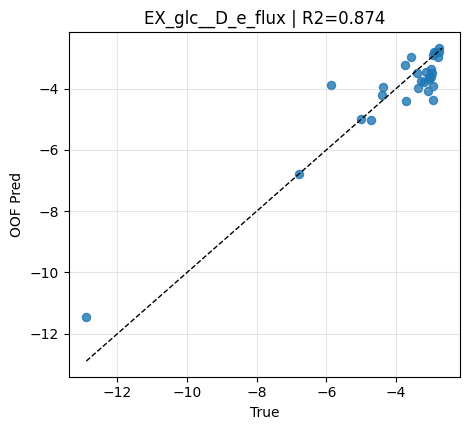

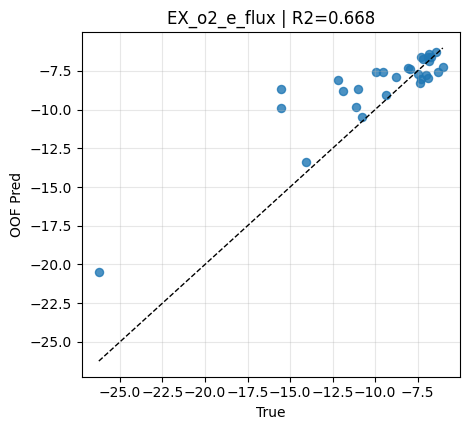

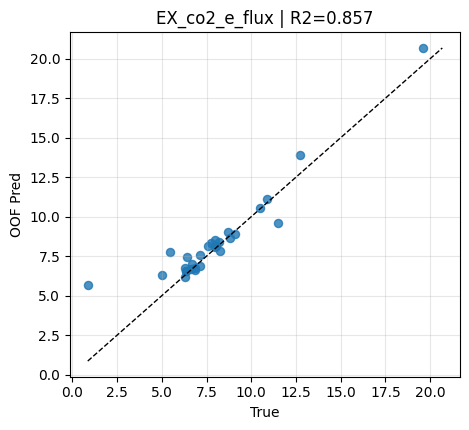

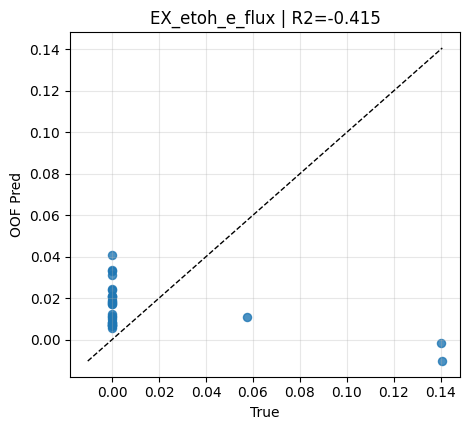

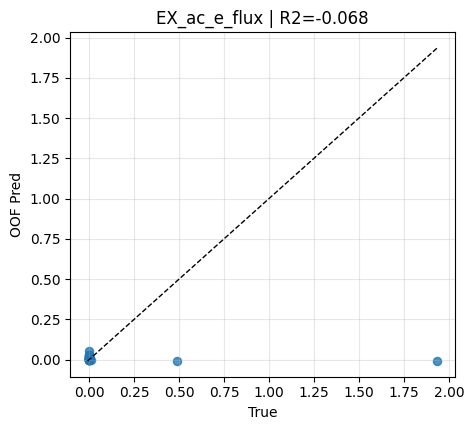

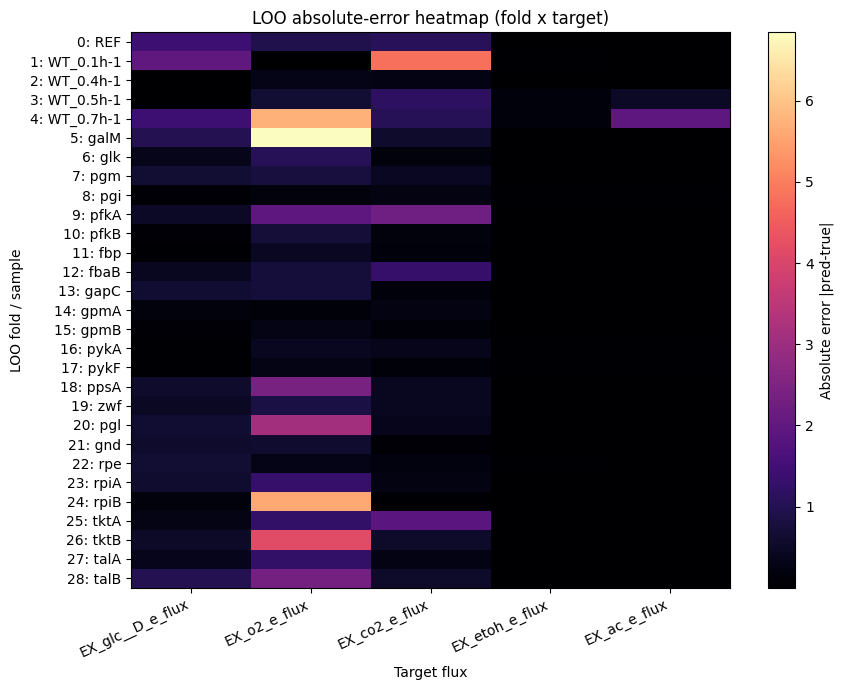

Top 5 worst folds by mean |error| across 5 targets:
  1. fold=4 exp=WT_0.7h-1 mean_abs_err=2.065403
  2. fold=5 exp=galM mean_abs_err=1.685534
  3. fold=1 exp=WT_0.1h-1 mean_abs_err=1.374699
  4. fold=24 exp=rpiB mean_abs_err=1.165173
  5. fold=26 exp=tktB mean_abs_err=1.048270


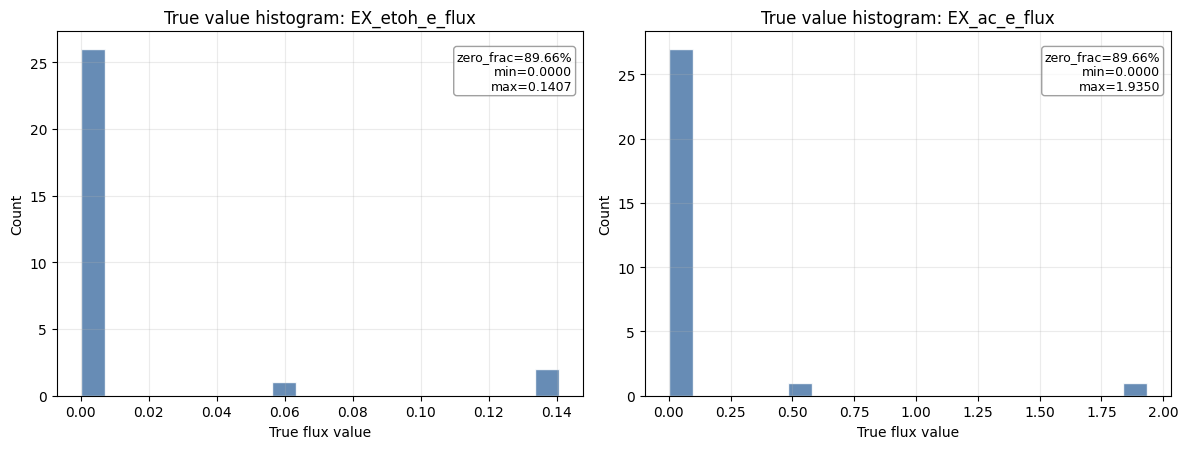

In [54]:
# Investigate the 5 fluxes predicted by the front MLP in a dedicated cell
# - pre_transformer_constraints: c0 channels before FluxTransformer
# - OOF metrics/scatter from nested CV run

inspect_fluxes = list(minn_target_token_names)

if len(inspect_fluxes) != 5:
    raise ValueError(f"Expected exactly 5 predicted fluxes, got {len(inspect_fluxes)}: {inspect_fluxes}")

# indices in vocabulary
token_to_idx = {tok: i for i, tok in enumerate(outputs)}
inspect_indices = [token_to_idx[f] for f in inspect_fluxes]

# Build c0 for all samples
X_all_t = torch.tensor(X_minn_np, dtype=torch.float32, device=device)
minn_model.eval()
with torch.no_grad():
    c0_all = minn_model.build_full_input_vector(X_all_t).detach().cpu().numpy()  # [N, vocab]

# summary
rows = []
for flux, idx in zip(inspect_fluxes, inspect_indices):
    cvals = c0_all[:, idx]
    col = inspect_fluxes.index(flux)

    row = {
        "flux": flux,
        "vocab_idx": idx,
        "pre_transformer_mean": float(np.mean(cvals)),
        "pre_transformer_std": float(np.std(cvals, ddof=1)) if len(cvals) > 1 else 0.0,
        "pre_transformer_min": float(np.min(cvals)),
        "pre_transformer_max": float(np.max(cvals)),
        "oof_r2": float(r2_score(oof_true[:, col], oof_pred[:, col])) if 'oof_true' in globals() else np.nan,
        "oof_mae": float(mean_absolute_error(oof_true[:, col], oof_pred[:, col])) if 'oof_true' in globals() else np.nan,
        "oof_rmse": float(root_mean_squared_error(oof_true[:, col], oof_pred[:, col])) if 'oof_true' in globals() else np.nan,
    }
    rows.append(row)

inspect_df = pd.DataFrame(rows)
print("5 front-MLP predicted fluxes: constraint stats + OOF metrics")
display(inspect_df)

# one scatter per flux
if 'oof_true' in globals() and 'oof_pred' in globals():
    for i, flux in enumerate(inspect_fluxes):
        y_t = oof_true[:, i]
        y_p = oof_pred[:, i]
        r2_val = r2_score(y_t, y_p)

        plt.figure(figsize=(4.8, 4.4))
        plt.scatter(y_t, y_p, alpha=0.8, s=34)
        lo = float(min(y_t.min(), y_p.min()))
        hi = float(max(y_t.max(), y_p.max()))
        plt.plot([lo, hi], [lo, hi], 'k--', lw=1)
        plt.xlabel("True")
        plt.ylabel("OOF Pred")
        plt.title(f"{flux} | R2={r2_val:.3f}")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # fold x target absolute-error heatmap
    abs_err = np.abs(oof_pred - oof_true)  # [n_folds, 5]
    fold_mean_err = abs_err.mean(axis=1)

    # Keep native LOO order by default. Optionally switch to worst-first order.
    sort_worst_first = False
    if sort_worst_first:
        row_order = np.argsort(-fold_mean_err)
    else:
        row_order = np.arange(abs_err.shape[0])

    abs_err_plot = abs_err[row_order]

    plt.figure(figsize=(9.0, 7.0))
    im = plt.imshow(abs_err_plot, aspect='auto', interpolation='nearest', cmap='magma')
    cbar = plt.colorbar(im)
    cbar.set_label('Absolute error |pred-true|')

    plt.xticks(np.arange(len(inspect_fluxes)), inspect_fluxes, rotation=25, ha='right')

    # y-axis labels: fold index (+ experiment when available)
    if 'minn_experiments' in globals() and len(minn_experiments) == abs_err.shape[0]:
        y_labels = [f"{int(i)}: {minn_experiments[i]}" for i in row_order]
    else:
        y_labels = [str(int(i)) for i in row_order]
    plt.yticks(np.arange(abs_err_plot.shape[0]), y_labels)

    plt.xlabel('Target flux')
    plt.ylabel('LOO fold / sample')
    plt.title('LOO absolute-error heatmap (fold x target)')
    plt.tight_layout()
    plt.show()

    # Print worst folds by mean absolute error across targets
    k = min(5, abs_err.shape[0])
    worst = np.argsort(-fold_mean_err)[:k]
    print(f"Top {k} worst folds by mean |error| across 5 targets:")
    for rank, i in enumerate(worst, start=1):
        exp_name = minn_experiments[i] if 'minn_experiments' in globals() and i < len(minn_experiments) else f"idx_{i}"
        print(f"  {rank}. fold={int(i)} exp={exp_name} mean_abs_err={float(fold_mean_err[i]):.6f}")

    # Histograms for ethanol and acetate TRUE values (from OOF true targets)
    etoh_idx = next((ii for ii, ff in enumerate(inspect_fluxes) if "etoh" in ff.lower()), None)
    ac_idx = next((ii for ii, ff in enumerate(inspect_fluxes) if "ac_e" in ff.lower() or "_ac_" in ff.lower()), None)

    hist_specs = []
    if etoh_idx is not None:
        hist_specs.append((etoh_idx, inspect_fluxes[etoh_idx]))
    if ac_idx is not None:
        hist_specs.append((ac_idx, inspect_fluxes[ac_idx]))

    if len(hist_specs) > 0:
        fig, axes = plt.subplots(1, len(hist_specs), figsize=(6.0 * len(hist_specs), 4.6), squeeze=False)
        axes = axes.ravel()

        for ax, (col_idx, flux_name) in zip(axes, hist_specs):
            vals = oof_true[:, col_idx].astype(float)
            ax.hist(vals, bins=20, alpha=0.85, color="#4c78a8", edgecolor="white")
            ax.set_title(f"True value histogram: {flux_name}")
            ax.set_xlabel("True flux value")
            ax.set_ylabel("Count")
            ax.grid(alpha=0.25)

            zero_frac = float(np.mean(np.isclose(vals, 0.0)))
            ax.text(
                0.98,
                0.95,
                f"zero_frac={zero_frac:.2%}\nmin={vals.min():.4f}\nmax={vals.max():.4f}",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.75, edgecolor="gray"),
            )

        plt.tight_layout()
        plt.show()
    else:
        print("Could not find etoh/ac target columns in inspect_fluxes.")
else:
    print("Run the nested CV training cell first to generate OOF outputs.")




### TabPFN ML-to-flux benchmark

Goncalves-style Table 2 benchmark: transcriptomics + proteomics + fixed glucose/O2 uptake inputs, 45 flux targets, leave-one-out CV, fold-local scaling, and R2/MAE/RMSE/NE reported as mean +/- std across samples.

In [55]:
# TabPFN benchmark in the same style as Goncalves et al. / Tazza et al. Table 2
#
# Settings intentionally mirror the ML2Flux benchmark row used in Table 2:
# - Inputs: transcriptomics + proteomics + measured glucose/O2 uptake fluxes
# - Targets: all fluxomics outputs except the fixed uptake fluxes (45 targets)
# - No omics standard-deviation features
# - Outer CV: leave-one-out over 29 Ishii samples
# - Scaling: StandardScaler fit only on each training fold for X and y
# - Metrics: per-sample R2, MAE, RMSE, NE, then mean +/- std across folds
#
# TabPFNRegressor is single-output, so each flux target is fitted independently
# inside a fold, equivalent in spirit to sklearn MultiOutputRegressor(SVR())
# used for SVM in the Goncalves repository.

import inspect
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from tabpfn import TabPFNRegressor

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

hf_token = os.getenv("HFTOKEN") or os.getenv("HF_TOKEN") or os.getenv("HUGGINGFACE_HUB_TOKEN")
if hf_token:
    os.environ.setdefault("HF_TOKEN", hf_token)
    os.environ.setdefault("HUGGINGFACE_HUB_TOKEN", hf_token)

TABPFN_DATA_DIR = Path("./MINN_data")
TABPFN_FLUXOMICS_FILE = "fluxomics.csv"  # original Goncalves/Ishii signed flux table, not the FBA-fit split table
TABPFN_PRIOR_FLUXES = ["R_EX_glc_e_", "R_EX_o2_e_"]
TABPFN_RANDOM_STATE = 12345
TABPFN_CV_RANDOM_STATE = 12345
TABPFN_DEVICE = "auto"
TABPFN_N_ESTIMATORS = 8  # TabPFN default; no HPO, analogous to default classical ML models in Goncalves
TABPFN_SHOW_TARGET_PROGRESS = False


def _load_goncalves_style_ishii_data(data_dir: Path):
    transcript_path = data_dir / "transcriptomics.csv"
    proteomics_path = data_dir / "proteomics.csv"
    fluxomics_path = data_dir / TABPFN_FLUXOMICS_FILE

    missing = [p for p in [transcript_path, proteomics_path, fluxomics_path] if not p.exists()]
    if missing:
        raise FileNotFoundError("Missing benchmark input files: " + ", ".join(str(p) for p in missing))

    tr = pd.read_csv(transcript_path).set_index("experiment")
    pr = pd.read_csv(proteomics_path).set_index("experiment")
    fl = pd.read_csv(fluxomics_path).set_index("experiment")

    # Preserve the fluxomics/Ishii sample order used for target rows.
    sample_index = fl.index.intersection(tr.index).intersection(pr.index)
    if len(sample_index) == 0:
        raise RuntimeError("No overlapping experiment IDs between transcriptomics, proteomics, and fluxomics.")
    sample_index = [idx for idx in fl.index if idx in set(sample_index)]

    x_df = pd.concat(
        [
            tr.loc[sample_index].add_prefix("transcriptomics_"),
            pr.loc[sample_index].add_prefix("proteomics_"),
        ],
        axis=1,
    )
    y_df = fl.loc[sample_index].copy()

    missing_prior = [c for c in TABPFN_PRIOR_FLUXES if c not in y_df.columns]
    if missing_prior:
        raise ValueError("Missing fixed uptake flux columns in fluxomics.csv: " + ", ".join(missing_prior))

    # ML2Flux/Goncalves fixed-uptake setup: append measured uptake fluxes to X and remove them from y.
    x_df = pd.concat([x_df, y_df[TABPFN_PRIOR_FLUXES]], axis=1)
    y_df = y_df.drop(columns=TABPFN_PRIOR_FLUXES)

    return x_df, y_df


def _make_tabpfn_regressor(seed: int):
    params = inspect.signature(TabPFNRegressor).parameters
    kwargs = {}
    if "device" in params:
        kwargs["device"] = TABPFN_DEVICE
    if "n_estimators" in params:
        kwargs["n_estimators"] = TABPFN_N_ESTIMATORS
    if "show_progress" in params:
        kwargs["show_progress"] = False
    if "random_state" in params:
        kwargs["random_state"] = seed
    elif "seed" in params:
        kwargs["seed"] = seed
    return TabPFNRegressor(**kwargs)


def _per_sample_r2_corr_squared(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    out = np.zeros(y_true.shape[0], dtype=np.float64)
    for i in range(y_true.shape[0]):
        yt = y_true[i]
        yp = y_pred[i]
        if np.std(yt) == 0.0 or np.std(yp) == 0.0:
            out[i] = 0.0
            continue
        r = np.corrcoef(yt, yp)[0, 1]
        out[i] = 0.0 if np.isnan(r) else float(r * r)
    return out


def _per_sample_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    diff = y_true - y_pred
    denom = np.linalg.norm(y_true, axis=1)
    return {
        "R2": _per_sample_r2_corr_squared(y_true, y_pred),
        "MAE": np.mean(np.abs(diff), axis=1),
        "RMSE": np.sqrt(np.mean(diff ** 2, axis=1)),
        "NE": np.nan_to_num(np.linalg.norm(diff, axis=1) / denom, posinf=0.0, neginf=0.0, nan=0.0),
    }


def _format_mean_std(avg, std):
    return f"{avg:.3f} +/- {std:.3f}"


X_tabpfn_df, y_tabpfn_df = _load_goncalves_style_ishii_data(TABPFN_DATA_DIR)
X_tabpfn = X_tabpfn_df.to_numpy(dtype=np.float32)
y_tabpfn = y_tabpfn_df.to_numpy(dtype=np.float32)

n_samples, n_features = X_tabpfn.shape
n_targets = y_tabpfn.shape[1]

if n_samples < 2:
    raise ValueError("Need at least two samples for leave-one-out CV.")

print("=== TabPFN Goncalves-style ML-to-flux benchmark ===")
print(f"Samples: {n_samples}")
print(f"Features: {n_features} (transcriptomics + proteomics + fixed uptake fluxes)")
print(f"Targets: {n_targets} fluxes (fixed uptake fluxes removed)")
print(f"Fixed uptake features: {TABPFN_PRIOR_FLUXES}")
print(f"Fluxomics file: {TABPFN_DATA_DIR / TABPFN_FLUXOMICS_FILE}")
print(f"TabPFN n_estimators: {TABPFN_N_ESTIMATORS}, device: {TABPFN_DEVICE}")

kfold = KFold(n_splits=n_samples, shuffle=True, random_state=TABPFN_CV_RANDOM_STATE)

tabpfn_predictions_matrix = []
tabpfn_fold_rows = []
tabpfn_oof_pred = np.zeros_like(y_tabpfn, dtype=np.float32)
tabpfn_oof_true = y_tabpfn.copy()

start_time = time.time()

for fold_no, (train_idx, test_idx) in enumerate(kfold.split(X_tabpfn, y_tabpfn), start=1):
    sc_X = StandardScaler()
    sc_y = StandardScaler()

    X_train_tabpfn_fold = sc_X.fit_transform(X_tabpfn[train_idx]).astype(np.float32)
    y_train_tabpfn_fold = sc_y.fit_transform(y_tabpfn[train_idx]).astype(np.float32)
    X_test_tabpfn_fold = sc_X.transform(X_tabpfn[test_idx]).astype(np.float32)
    y_test_tabpfn_fold = sc_y.transform(y_tabpfn[test_idx]).astype(np.float32)

    y_pred_scaled = np.zeros_like(y_test_tabpfn_fold, dtype=np.float32)

    print("------------------------------------------------------------------------")
    print(f"[TabPFN] Training for LOO fold {fold_no}/{n_samples} | test={X_tabpfn_df.index[test_idx[0]]}")

    for target_idx, target_name in enumerate(y_tabpfn_df.columns):
        y_train_target = y_train_tabpfn_fold[:, target_idx]

        # TabPFN can be brittle with perfectly constant training targets; this is the exact constant predictor.
        if np.allclose(y_train_target, y_train_target[0]):
            y_pred_scaled[:, target_idx] = y_train_target[0]
            continue

        reg = _make_tabpfn_regressor(seed=TABPFN_RANDOM_STATE)
        reg.fit(X_train_tabpfn_fold, y_train_target)
        pred = np.asarray(reg.predict(X_test_tabpfn_fold), dtype=np.float32).reshape(-1)
        if pred.shape[0] != X_test_tabpfn_fold.shape[0]:
            raise RuntimeError(
                f"Unexpected TabPFN prediction shape for target {target_name}: {pred.shape}, expected ({X_test_tabpfn_fold.shape[0]},)"
            )
        y_pred_scaled[:, target_idx] = pred

        if TABPFN_SHOW_TARGET_PROGRESS and (target_idx + 1) % 10 == 0:
            print(f"  fitted {target_idx + 1}/{n_targets} targets")

    y_pred = sc_y.inverse_transform(y_pred_scaled).astype(np.float32)
    y_true = sc_y.inverse_transform(y_test_tabpfn_fold).astype(np.float32)

    tabpfn_oof_pred[test_idx] = y_pred
    tabpfn_predictions_matrix.append((int(test_idx[0]), y_pred[0].copy()))

    fold_metrics = _per_sample_metrics(y_true, y_pred)
    row = {
        "fold": int(fold_no),
        "sample_index": int(test_idx[0]),
        "experiment": str(X_tabpfn_df.index[test_idx[0]]),
        "R2": float(fold_metrics["R2"][0]),
        "MAE": float(fold_metrics["MAE"][0]),
        "RMSE": float(fold_metrics["RMSE"][0]),
        "NE": float(fold_metrics["NE"][0]),
    }
    tabpfn_fold_rows.append(row)
    print(
        f"Score for fold {fold_no}: "
        f"R2={row['R2']:.4f}; MAE={row['MAE']:.6f}; "
        f"RMSE={row['RMSE']:.6f}; NE={row['NE']:.6f}"
    )

tabpfn_fold_metrics_df = pd.DataFrame(tabpfn_fold_rows)

metric_order = ["R2", "MAE", "RMSE", "NE"]
tabpfn_summary_numeric_df = pd.DataFrame(
    {
        "avg": [float(tabpfn_fold_metrics_df[m].mean()) for m in metric_order],
        "std": [float(tabpfn_fold_metrics_df[m].std(ddof=0)) for m in metric_order],
    },
    index=metric_order,
)

tabpfn_table2_row_df = pd.DataFrame(
    [
        {
            "Model": "TabPFN",
            **{
                m: _format_mean_std(
                    float(tabpfn_summary_numeric_df.loc[m, "avg"]),
                    float(tabpfn_summary_numeric_df.loc[m, "std"]),
                )
                for m in metric_order
            },
        }
    ]
)

tabpfn_predictions_matrix.sort(key=lambda x: x[0])
tabpfn_predictions_df = pd.DataFrame(
    [x[1] for x in tabpfn_predictions_matrix],
    index=X_tabpfn_df.index,
    columns=y_tabpfn_df.columns,
).T

tabpfn_oof_true_df = pd.DataFrame(tabpfn_oof_true, index=X_tabpfn_df.index, columns=y_tabpfn_df.columns)
tabpfn_oof_pred_df = pd.DataFrame(tabpfn_oof_pred, index=X_tabpfn_df.index, columns=y_tabpfn_df.columns)

elapsed_min = (time.time() - start_time) / 60.0

print("------------------------------------------------------------------------")
print(f"TabPFN benchmark finished in {elapsed_min:.1f} min")
print("=== TabPFN Table 2-style row ===")
display(tabpfn_table2_row_df)
print("=== Numeric summary ===")
display(tabpfn_summary_numeric_df)
print("=== Fold metrics ===")
display(tabpfn_fold_metrics_df)

# Keep tabpfn_table2_row_df available for the final combined Table 2-style comparison.


=== TabPFN Goncalves-style ML-to-flux benchmark ===
Samples: 29
Features: 141 (transcriptomics + proteomics + fixed uptake fluxes)
Targets: 45 fluxes (fixed uptake fluxes removed)
Fixed uptake features: ['R_EX_glc_e_', 'R_EX_o2_e_']
Fluxomics file: MINN_data\fluxomics.csv
TabPFN n_estimators: 8, device: auto
------------------------------------------------------------------------
[TabPFN] Training for LOO fold 1/29 | test=tktA
Score for fold 1: R2=0.9729; MAE=0.301595; RMSE=0.580070; NE=0.148093
------------------------------------------------------------------------
[TabPFN] Training for LOO fold 2/29 | test=gpmB
Score for fold 2: R2=0.9912; MAE=0.103702; RMSE=0.230077; NE=0.085272
------------------------------------------------------------------------
[TabPFN] Training for LOO fold 3/29 | test=zwf
Score for fold 3: R2=0.9808; MAE=0.245592; RMSE=0.339671; NE=0.129790
------------------------------------------------------------------------
[TabPFN] Training for LOO fold 4/29 | test=WT

,Model,R2,MAE,RMSE,NE
0,TabPFN,0.969 +/- 0.034,0.369 +/- 0.594,0.562 +/- 0.774,0.197 +/- 0.172


=== Numeric summary ===


,avg,std
R2,0.969187,0.034149
MAE,0.368767,0.594040
RMSE,0.561861,0.774108
NE,0.196814,0.171549


=== Fold metrics ===


,fold,sample_index,experiment,R2,MAE,RMSE,NE
0,1,25,tktA,0.972930,0.301595,0.580070,0.148093
1,2,15,gpmB,0.991164,0.103702,0.230077,0.085272
2,3,19,zwf,0.980823,0.245592,0.339671,0.129790
3,4,3,WT_0.5h-1,0.962955,0.930261,1.309730,0.278696
4,5,12,fbaB,0.967891,0.113820,0.352343,0.183031
5,6,0,REF,0.989457,0.077057,0.208225,0.096288
6,7,23,rpiA,0.983964,0.183911,0.298646,0.123428
7,8,8,pgi,0.834433,0.490874,0.765428,0.460426
8,9,20,pgl,0.990446,0.130694,0.232109,0.088275
9,10,7,pgm,0.965641,0.115923,0.419642,0.173666


### Goncalves pFBA baseline recomputed with iML1515

This cell reruns the pFBA baseline protocol from the Goncalves/omics2flux Ishii benchmark, but uses the iML1515 GEM instead of the original iAF1260 model.

For each Ishii sample, the measured glucose and oxygen uptake values from `MINN_data/fluxomics.csv` are fixed as exchange bounds. For knockout samples, the notebook uses the same ordered b-number knockout list as `omics2flux/pfba.py`; this matters because the local fluxomics table uses gene-symbol sample labels while the Goncalves pFBA script uses b-numbers. Predictions are then extracted for the same 45 non-uptake flux targets used in the Goncalves Table 2 pFBA row, with reaction-name adjustments where iML1515 uses different exchange or biomass IDs.

The output is a Table 2-style pFBA row with R2, MAE, RMSE, and NE reported as mean +/- standard deviation across the 29 Ishii samples, plus per-sample diagnostics and any failed iML1515 pFBA cases.

In [56]:
# Goncalves-style pFBA baseline, reproduced on iML1515 instead of iAF1260
#
# Matches omics2flux/pfba.py conceptually:
# - Ishii sample order from fluxomics.csv
# - fixed glucose and oxygen uptake bounds from measured fluxomics values
# - gene knockouts for b-number samples
# - pFBA predictions for the same 45 non-uptake target fluxes
# - R2, MAE, RMSE, NE as mean +/- std across samples

import logging
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from cobra.io import read_sbml_model
    from cobra.flux_analysis import pfba as cobra_pfba
except ImportError as e:
    raise ImportError("cobra is required for the iML1515 pFBA benchmark. Install cobra in the notebook environment.") from e

logging.getLogger("cobra").setLevel(logging.ERROR)

GONCALVES_PFBA_DATA_DIR = Path("./MINN_data")
GONCALVES_PFBA_FLUXOMICS_FILE = "fluxomics.csv"
GONCALVES_PFBA_MODEL_PATH = Path("./models/iML1515.xml")
GONCALVES_PFBA_OBJECTIVE = globals().get("PFBA_OBJECTIVE_RXN", "BIOMASS_Ec_iML1515_core_75p37M")
GONCALVES_PFBA_WT_SAMPLES = {"REF", "WT_0.1h-1", "WT_0.4h-1", "WT_0.5h-1", "WT_0.7h-1"}
GONCALVES_PFBA_SAMPLE_TO_B_NUMBER = {
    "galM": "b0756",
    "glk": "b2388",
    "pgm": "b0688",
    "pgi": "b4025",
    "pfkA": "b3916",
    "pfkB": "b1723",
    "fbp": "b4232",
    "fbaB": "b2097",
    "gapC": "b0118",
    "gpmA": "b0755",
    "gpmB": "b4395",
    "pykA": "b1854",
    "pykF": "b1676",
    "ppsA": "b1702",
    "zwf": "b1852",
    "pgl": "b0767",
    "gnd": "b2029",
    "rpe": "b3386",
    "rpiA": "b2914",
    "rpiB": "b4090",
    "tktA": "b2935",
    "tktB": "b2465",
    "talA": "b2464",
    "talB": "b0008",
}
# iML1515 does not contain b4395/ytjC from the original iAF1260 pFBA settings.
# Use the iML1515 PGM isozyme gene for the gpmB sample so the adapted benchmark has 29/29 samples.
GONCALVES_PFBA_iML1515_GENE_ALIASES = {"b4395": "b3612"}

GONCALVES_PFBA_TARGETS = [
    "GLCptspp", "PGI", "PFK", "FBA", "TPI", "PGK", "GAPD", "ENO", "PGM", "PYK",
    "PDH", "G6PDH2r", "PGL", "GND", "RPE", "RPI", "TKT1", "TALA", "TKT2", "CS",
    "ACONTb", "ACONTa", "ICDHyr", "SUCOAS", "AKGDH", "SUCDi", "FUM", "MDH", "PPC",
    "ME2", "ICL", "MALS", "ACKr", "PTAr", "LDH_D", "ACALD", "ALCD2x",
    "EX_co2_e_", "EX_etoh_e_", "EX_ac_e_", "EX_lac_D_e_", "EX_succ_e_", "EX_pyr_e_", "EX_for_e_",
    "Ec_biomass_iAF1260_core_59p81M",
]

GONCALVES_TO_iML1515_REACTION = {
    "EX_co2_e_": "EX_co2_e",
    "EX_etoh_e_": "EX_etoh_e",
    "EX_ac_e_": "EX_ac_e",
    "EX_lac_D_e_": "EX_lac__D_e",
    "EX_succ_e_": "EX_succ_e",
    "EX_pyr_e_": "EX_pyr_e",
    "EX_for_e_": "EX_for_e",
    "Ec_biomass_iAF1260_core_59p81M": GONCALVES_PFBA_OBJECTIVE,
}


def _goncalves_target_to_iML1515_reaction(target_name: str) -> str:
    return GONCALVES_TO_iML1515_REACTION.get(target_name, target_name)


def _get_model_gene(model_obj, gene_id: str):
    aliased_gene_id = GONCALVES_PFBA_iML1515_GENE_ALIASES.get(gene_id, gene_id)
    for candidate in (aliased_gene_id, f"G_{aliased_gene_id}"):
        try:
            return model_obj.genes.get_by_id(candidate)
        except KeyError:
            pass
    return None


def _goncalves_r2_metric(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    out = np.zeros(y_true.shape[0], dtype=np.float64)
    for i in range(y_true.shape[0]):
        yt = y_true[i]
        yp = y_pred[i]
        if np.std(yt) == 0.0 or np.std(yp) == 0.0:
            out[i] = 0.0
            continue
        r = np.corrcoef(yt, yp)[0, 1]
        out[i] = 0.0 if np.isnan(r) else float(r * r)
    return out


def _goncalves_sample_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    diff = y_true - y_pred
    denom = np.linalg.norm(y_true, axis=1)
    return {
        "R2": _goncalves_r2_metric(y_true, y_pred),
        "MAE": np.mean(np.abs(diff), axis=1),
        "RMSE": np.sqrt(np.mean(diff ** 2, axis=1)),
        "NE": np.nan_to_num(np.linalg.norm(diff, axis=1) / denom, posinf=0.0, neginf=0.0, nan=0.0),
    }


def _format_mean_std_local(avg, std):
    if "_format_mean_std" in globals():
        return _format_mean_std(avg, std)
    return f"{avg:.3f} +/- {std:.3f}"


fluxomics_path = GONCALVES_PFBA_DATA_DIR / GONCALVES_PFBA_FLUXOMICS_FILE
if not fluxomics_path.exists():
    raise FileNotFoundError(f"Missing fluxomics file: {fluxomics_path}")
if not GONCALVES_PFBA_MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing iML1515 SBML model: {GONCALVES_PFBA_MODEL_PATH}")

goncalves_pfba_fluxomics_df = pd.read_csv(fluxomics_path).set_index("experiment")
true_cols = [f"R_{c}" for c in GONCALVES_PFBA_TARGETS]
missing_true_cols = [c for c in true_cols if c not in goncalves_pfba_fluxomics_df.columns]
if missing_true_cols:
    raise ValueError("Missing Goncalves target columns in fluxomics.csv: " + ", ".join(missing_true_cols))
for c in ["R_EX_glc_e_", "R_EX_o2_e_"]:
    if c not in goncalves_pfba_fluxomics_df.columns:
        raise ValueError(f"Missing measured uptake column in fluxomics.csv: {c}")

goncalves_iML1515_model = read_sbml_model(str(GONCALVES_PFBA_MODEL_PATH))
goncalves_iML1515_model.objective = GONCALVES_PFBA_OBJECTIVE

target_rxn_map = {c: _goncalves_target_to_iML1515_reaction(c) for c in GONCALVES_PFBA_TARGETS}
missing_model_rxns = [rxn for rxn in sorted(set(target_rxn_map.values())) if rxn not in goncalves_iML1515_model.reactions]
missing_model_rxns += [rxn for rxn in ["EX_glc__D_e", "EX_o2_e"] if rxn not in goncalves_iML1515_model.reactions]
if missing_model_rxns:
    raise KeyError("Missing required reactions in iML1515: " + ", ".join(missing_model_rxns))

print("=== Goncalves-style pFBA baseline with iML1515 ===")
print(f"Samples: {len(goncalves_pfba_fluxomics_df)}")
print(f"Targets: {len(GONCALVES_PFBA_TARGETS)} fluxes")
print(f"Model: {GONCALVES_PFBA_MODEL_PATH}")
print(f"Objective: {GONCALVES_PFBA_OBJECTIVE}")
print("Fixed uptake bounds: R_EX_glc_e_ -> EX_glc__D_e, R_EX_o2_e_ -> EX_o2_e")
goncalves_pfba_ko_mapping_df = pd.DataFrame(
    [
        {
            "experiment": exp,
            "goncalves_b_number": bnum,
            "iML1515_gene_used": GONCALVES_PFBA_iML1515_GENE_ALIASES.get(bnum, bnum),
        }
        for exp, bnum in GONCALVES_PFBA_SAMPLE_TO_B_NUMBER.items()
    ]
)
print("Goncalves b-number knockout mapping used for non-WT samples:")
display(goncalves_pfba_ko_mapping_df)

prediction_rows = []
failed_rows = []

for experiment, row in goncalves_pfba_fluxomics_df.iterrows():
    glc_bound = float(row["R_EX_glc_e_"])
    o2_bound = float(row["R_EX_o2_e_"])

    with goncalves_iML1515_model as m:
        if experiment not in GONCALVES_PFBA_WT_SAMPLES:
            goncalves_gene_id = GONCALVES_PFBA_SAMPLE_TO_B_NUMBER.get(str(experiment))
            if goncalves_gene_id is None:
                failed_rows.append({"experiment": experiment, "reason": f"missing Goncalves knockout mapping for {experiment}"})
                continue
            gene = _get_model_gene(m, goncalves_gene_id)
            if gene is None:
                failed_rows.append({"experiment": experiment, "reason": f"missing iML1515 gene for Goncalves knockout {goncalves_gene_id}"})
                continue
            gene.knock_out()

        m.reactions.get_by_id("EX_glc__D_e").bounds = (glc_bound, glc_bound)
        m.reactions.get_by_id("EX_o2_e").bounds = (o2_bound, o2_bound)

        try:
            solution = cobra_pfba(m)
            sol_status = getattr(solution, "status", "optimal")
            if sol_status != "optimal":
                raise RuntimeError(f"pFBA status={sol_status}")
            prediction_rows.append(
                {
                    "experiment": experiment,
                    **{target: float(solution.fluxes[target_rxn_map[target]]) for target in GONCALVES_PFBA_TARGETS},
                }
            )
        except Exception as e:
            failed_rows.append({"experiment": experiment, "reason": str(e)})

if not prediction_rows:
    raise RuntimeError("No successful iML1515 pFBA samples. Check uptake bounds, objective, and knockout feasibility.")

goncalves_iML1515_pfba_predictions_df = pd.DataFrame(prediction_rows).set_index("experiment")
goncalves_iML1515_pfba_true_df = goncalves_pfba_fluxomics_df.loc[
    goncalves_iML1515_pfba_predictions_df.index,
    true_cols,
].copy()
goncalves_iML1515_pfba_true_df.columns = GONCALVES_PFBA_TARGETS

y_true_pfba_iML1515 = goncalves_iML1515_pfba_true_df.to_numpy(dtype=np.float64)
y_pred_pfba_iML1515 = goncalves_iML1515_pfba_predictions_df[GONCALVES_PFBA_TARGETS].to_numpy(dtype=np.float64)
pfba_iML1515_metrics = _goncalves_sample_metrics(y_true_pfba_iML1515, y_pred_pfba_iML1515)

metric_order = ["R2", "MAE", "RMSE", "NE"]
goncalves_iML1515_pfba_fold_metrics_df = pd.DataFrame(
    {
        "experiment": goncalves_iML1515_pfba_predictions_df.index,
        **{m: pfba_iML1515_metrics[m] for m in metric_order},
    }
)

goncalves_iML1515_pfba_summary_numeric_df = pd.DataFrame(
    {
        "avg": [float(np.mean(pfba_iML1515_metrics[m])) for m in metric_order],
        "std": [float(np.std(pfba_iML1515_metrics[m])) for m in metric_order],
    },
    index=metric_order,
)

goncalves_iML1515_pfba_table2_row_df = pd.DataFrame(
    [
        {
            "Model": "pFBA iML1515",
            **{
                m: _format_mean_std_local(
                    float(goncalves_iML1515_pfba_summary_numeric_df.loc[m, "avg"]),
                    float(goncalves_iML1515_pfba_summary_numeric_df.loc[m, "std"]),
                )
                for m in metric_order
            },
        }
    ]
)

goncalves_iML1515_pfba_failed_df = pd.DataFrame(failed_rows)

print(f"Successful pFBA samples: {len(goncalves_iML1515_pfba_predictions_df)}/{len(goncalves_pfba_fluxomics_df)}")
if not goncalves_iML1515_pfba_failed_df.empty:
    print("Failed samples:")
    display(goncalves_iML1515_pfba_failed_df)

print("=== iML1515 pFBA Table 2-style row ===")
display(goncalves_iML1515_pfba_table2_row_df)
print("=== Numeric summary ===")
display(goncalves_iML1515_pfba_summary_numeric_df)
print("=== Per-sample metrics ===")
display(goncalves_iML1515_pfba_fold_metrics_df)

# Published Tazza et al. Table 2 rows, kept in the original paper order.
tazza_table2_published_rows_df = pd.DataFrame(
    [
        {"Model": "pFBA*", "R2": "0.823 +/- 0.156", "MAE": "0.692 +/- 0.733", "RMSE": "1.058 +/- 1.029", "NE": "0.381 +/- 0.185"},
        {"Model": "NN*", "R2": "0.967 +/- 0.036", "MAE": "0.652 +/- 0.945", "RMSE": "0.936 +/- 1.314", "NE": "0.338 +/- 0.338"},
        {"Model": "RF*", "R2": "0.970 +/- 0.037", "MAE": "0.507 +/- 0.804", "RMSE": "0.729 +/- 1.105", "NE": "0.271 +/- 0.347"},
        {"Model": "MINN-MSE-base", "R2": "0.950 +/- 0.060", "MAE": "0.525 +/- 0.525", "RMSE": "0.736 +/- 0.703", "NE": "0.287 +/- 0.282"},
        {"Model": "MINN-unbalanced", "R2": "0.951 +/- 0.051", "MAE": "0.563 +/- 0.739", "RMSE": "0.814 +/- 1.067", "NE": "0.325 +/- 0.442"},
        {"Model": "MINN-c-balanced", "R2": "0.950 +/- 0.055", "MAE": "0.473 +/- 0.480", "RMSE": "0.678 +/- 0.653", "NE": "0.272 +/- 0.280"},
    ]
)

comparison_rows = [tazza_table2_published_rows_df]
comparison_rows.append(goncalves_iML1515_pfba_table2_row_df)
if "tabpfn_table2_row_df" in globals():
    comparison_rows.append(tabpfn_table2_row_df)
goncalves_iML1515_table2_comparison_df = pd.concat(comparison_rows, ignore_index=True)
tabpfn_row_mask = goncalves_iML1515_table2_comparison_df["Model"].astype(str).str.casefold().eq("tabpfn")
goncalves_iML1515_table2_comparison_df = pd.concat(
    [
        goncalves_iML1515_table2_comparison_df.loc[~tabpfn_row_mask],
        goncalves_iML1515_table2_comparison_df.loc[tabpfn_row_mask],
    ],
    ignore_index=True,
)
print("=== Table 2-style comparison including iML1515 pFBA ===")
display(goncalves_iML1515_table2_comparison_df)


=== Goncalves-style pFBA baseline with iML1515 ===
Samples: 29
Targets: 45 fluxes
Model: models\iML1515.xml
Objective: BIOMASS_Ec_iML1515_core_75p37M
Fixed uptake bounds: R_EX_glc_e_ -> EX_glc__D_e, R_EX_o2_e_ -> EX_o2_e
Goncalves b-number knockout mapping used for non-WT samples:


,experiment,goncalves_b_number,iML1515_gene_used
0,galM,b0756,b0756
1,glk,b2388,b2388
2,pgm,b0688,b0688
3,pgi,b4025,b4025
4,pfkA,b3916,b3916
5,pfkB,b1723,b1723
6,fbp,b4232,b4232
7,fbaB,b2097,b2097
8,gapC,b0118,b0118
9,gpmA,b0755,b0755


Successful pFBA samples: 29/29
=== iML1515 pFBA Table 2-style row ===


,Model,R2,MAE,RMSE,NE
0,pFBA iML1515,0.818 +/- 0.167,0.690 +/- 0.761,1.081 +/- 1.066,0.389 +/- 0.188


=== Numeric summary ===


,avg,std
R2,0.817741,0.166915
MAE,0.689957,0.760822
RMSE,1.080738,1.065808
NE,0.389118,0.188365


=== Per-sample metrics ===


,experiment,R2,MAE,RMSE,NE
0,REF,0.854697,0.504620,0.780408,0.360880
1,WT_0.1h-1,0.489591,0.475834,0.732902,0.792481
2,WT_0.4h-1,0.914258,0.658725,0.973097,0.280574
3,WT_0.5h-1,0.920280,0.786240,1.234688,0.262728
4,WT_0.7h-1,0.595764,4.374313,6.253833,0.640742
5,galM,0.936769,0.367946,0.577618,0.249931
6,glk,0.742725,0.810760,1.236964,0.482470
7,pgm,0.839266,0.582875,0.922983,0.381969
8,pgi,0.627307,0.841535,1.133924,0.682086
9,pfkA,0.881120,0.221903,0.701320,0.359021


=== Table 2-style comparison including iML1515 pFBA ===


,Model,R2,MAE,RMSE,NE
0,pFBA*,0.823 +/- 0.156,0.692 +/- 0.733,1.058 +/- 1.029,0.381 +/- 0.185
1,NN*,0.967 +/- 0.036,0.652 +/- 0.945,0.936 +/- 1.314,0.338 +/- 0.338
2,RF*,0.970 +/- 0.037,0.507 +/- 0.804,0.729 +/- 1.105,0.271 +/- 0.347
3,MINN-MSE-base,0.950 +/- 0.060,0.525 +/- 0.525,0.736 +/- 0.703,0.287 +/- 0.282
4,MINN-unbalanced,0.951 +/- 0.051,0.563 +/- 0.739,0.814 +/- 1.067,0.325 +/- 0.442
5,MINN-c-balanced,0.950 +/- 0.055,0.473 +/- 0.480,0.678 +/- 0.653,0.272 +/- 0.280
6,pFBA iML1515,0.818 +/- 0.167,0.690 +/- 0.761,1.081 +/- 1.066,0.389 +/- 0.188
7,TabPFN,0.969 +/- 0.034,0.369 +/- 0.594,0.562 +/- 0.774,0.197 +/- 0.172


### FluxTransformer Table 2-style ML-to-flux benchmark

This section adds a direct FluxTransformer row to the Table 2-style comparison. It does not run COBRA or pFBA. The only trainable component is a front MLP; the pretrained FluxTransformer stays frozen.

The front MLP receives transcriptomics, proteomics, and measured glucose/oxygen uptake as features. For each sample, it predicts the five exchange-context values used by the FluxTransformer input interface: glucose, oxygen, CO2, ethanol, and acetate. Those five predicted magnitudes are inserted into the corresponding FluxTransformer input-token positions, base medium exchanges are fixed to the simulated default value, and all other token inputs remain zero.

The frozen FluxTransformer predicts the full iML1515 flux vocabulary from that exchange-context input. The 45 non-uptake Goncalves/Tazza Table 2 target fluxes are then extracted from the full output and scored with R2, MAE, RMSE, and NE as mean +/- standard deviation across samples.


In [57]:
# Direct FluxTransformer Table 2-style benchmark using the pretrained exchange-constraint input interface.
# Five-context option: the front MLP predicts glucose, oxygen, CO2, ethanol, and acetate inputs.

from pathlib import Path

required_fluxtransformer_table2_globals = [
    "X_minn_np",
    "minn_experiments",
    "fixed_base_token_values",
    "outputs",
    "model",
    "device",
    "DEFAULT_BASE_EXCHANGE_RATE",
    "GONCALVES_PFBA_TARGETS",
    "_goncalves_target_to_iML1515_reaction",
    "_goncalves_sample_metrics",
    "_format_mean_std_local",
]
missing_fluxtransformer_table2_globals = [g for g in required_fluxtransformer_table2_globals if g not in globals()]
if missing_fluxtransformer_table2_globals:
    raise RuntimeError(
        "Run the MINN data setup and iML1515 pFBA/Table 2 setup cells first. Missing: "
        + ", ".join(missing_fluxtransformer_table2_globals)
    )


try:
    import optuna as _table2_optuna
    FLUXTRANSFORMER_TABLE2_OPTUNA_AVAILABLE = True
except Exception:
    _table2_optuna = None
    FLUXTRANSFORMER_TABLE2_OPTUNA_AVAILABLE = False


FLUXTRANSFORMER_TABLE2_SCALE_TARGET_LOSS = True
FLUXTRANSFORMER_TABLE2_INPUT_MODE = "predicted_5_exchange_context"
FLUXTRANSFORMER_TABLE2_EXCHANGE_CONTEXT = [
    {"target": "EX_glc_e_", "token_rxn": "EX_glc__D_e", "sign": -1.0, "max_value": 15.0},
    {"target": "EX_o2_e_", "token_rxn": "EX_o2_e", "sign": -1.0, "max_value": 30.0},
    {"target": "EX_co2_e_", "token_rxn": "EX_co2_e", "sign": 1.0, "max_value": 30.0},
    {"target": "EX_etoh_e_", "token_rxn": "EX_etoh_e", "sign": 1.0, "max_value": 1.0},
    {"target": "EX_ac_e_", "token_rxn": "EX_ac_e", "sign": 1.0, "max_value": 4.0},
]

# Standalone MINN-style nested CV/HPO for this Table 2 FluxTransformer row.
# These settings intentionally do not read best hyperparameters or selected aux weights from earlier cells.
FLUXTRANSFORMER_TABLE2_CV_RANDOM_STATE = 12345
FLUXTRANSFORMER_TABLE2_INNER_CV_FOLDS = 5
FLUXTRANSFORMER_TABLE2_MAX_TRIALS = 25
FLUXTRANSFORMER_TABLE2_HPO_PER_OUTER_FOLD = False
FLUXTRANSFORMER_TABLE2_EPOCHS = 100
FLUXTRANSFORMER_TABLE2_BATCH_SIZE = 5
if device.type == "cuda" and FLUXTRANSFORMER_TABLE2_BATCH_SIZE > 2:
    print("CUDA detected: overriding Table 2 batch_size 5 -> 2 to avoid OOM with full-output forward.")
    FLUXTRANSFORMER_TABLE2_BATCH_SIZE = 2
FLUXTRANSFORMER_TABLE2_EARLY_STOPPING_PATIENCE = 25
FLUXTRANSFORMER_TABLE2_EARLY_STOPPING_MIN_DELTA = 1e-5
FLUXTRANSFORMER_TABLE2_GRAD_CLIP_MAX_NORM = 1.0
FLUXTRANSFORMER_TABLE2_LR_WARMUP_EPOCHS = max(3, min(10, FLUXTRANSFORMER_TABLE2_EPOCHS // 10))
FLUXTRANSFORMER_TABLE2_LR_COSINE_MIN_FACTOR = 0.05
FLUXTRANSFORMER_TABLE2_SEARCH_SPACE = {
    "hidden_size": [200, 250, 300, 512],
    "drop_rate": [0.0, 0.05, 0.1, 0.25],
    "learning_rate": {"low": 2e-4, "high": 3e-3, "log": True},
    "weight_decay": {"low": 1e-8, "high": 1e-3, "log": True},
    "exchange_aux_weight": [0.0, 0.1, 0.3, 0.5],
}
class ExchangeConstraintFluxTransformerTable2MLP(nn.Module):
    """Front MLP predicts the five exchange-context inputs for the frozen FluxTransformer."""

    def __init__(
        self,
        flux_transformer,
        input_dim,
        context_token_indices,
        context_max_values,
        fixed_input_template,
        hidden_dim=512,
        drop_rate=0.1,
    ):
        super().__init__()
        self.frozen_flux_transformer = flux_transformer
        self.vocab_size = int(self.frozen_flux_transformer.vocab_size)
        self.register_buffer("context_token_indices", torch.tensor(context_token_indices, dtype=torch.long), persistent=True)
        self.register_buffer("context_max_values", torch.tensor(context_max_values, dtype=torch.float32), persistent=True)
        self.register_buffer("fixed_input_template", torch.tensor(fixed_input_template, dtype=torch.float32), persistent=True)
        for p in self.frozen_flux_transformer.parameters():
            p.requires_grad = False
        self.frozen_flux_transformer.eval()
        self.front_mlp = nn.Sequential(
            nn.Linear(input_dim, int(hidden_dim)),
            nn.ReLU(),
            nn.Dropout(float(drop_rate)),
            nn.Linear(int(hidden_dim), len(context_token_indices)),
        )

    def train(self, mode: bool = True):
        super().train(mode)
        self.frozen_flux_transformer.eval()
        return self

    def build_input_vector(self, x):
        raw_context = self.front_mlp(x)
        pred_context_inputs = torch.sigmoid(raw_context) * self.context_max_values.to(raw_context.dtype).unsqueeze(0)
        c0 = self.fixed_input_template.to(dtype=x.dtype, device=x.device).unsqueeze(0).repeat(x.size(0), 1)
        c0[:, self.context_token_indices.to(x.device)] = pred_context_inputs.to(dtype=c0.dtype)
        return c0, pred_context_inputs

    def forward(self, x):
        c0, pred_context_inputs = self.build_input_vector(x)
        preds_all_layers, _sel = self.frozen_flux_transformer(c0.unsqueeze(-1), output_subset=None)
        return preds_all_layers[:, :, -1], pred_context_inputs


def _train_exchange_constraint_fluxtransformer_table2_split(
    X_tr_np,
    X_va_np,
    y_table2_tr_np,
    y_table2_va_np,
    context_exchange_tr_np,
    context_exchange_va_np,
    table2_target_indices_np,
    table2_target_signs_np,
    context_token_indices_np,
    context_max_values_np,
    fixed_input_template_np,
    params,
    device_obj,
):
    x_scaler = MinMaxScaler()
    X_tr_np_scaled = x_scaler.fit_transform(X_tr_np)
    X_va_np_scaled = x_scaler.transform(X_va_np)

    hidden_dim = int(params.get("hidden_size", 512))
    model_local = ExchangeConstraintFluxTransformerTable2MLP(
        flux_transformer=model,
        input_dim=X_tr_np.shape[1],
        context_token_indices=context_token_indices_np,
        context_max_values=context_max_values_np,
        fixed_input_template=fixed_input_template_np,
        hidden_dim=hidden_dim,
        drop_rate=float(params["drop_rate"]),
    ).to(device_obj)
    optimizer = torch.optim.AdamW(
        model_local.front_mlp.parameters(),
        lr=float(params["learning_rate"]),
        weight_decay=float(params["weight_decay"]),
    )
    criterion = nn.HuberLoss()

    use_amp = device_obj.type == "cuda"
    amp_device_type = "cuda" if use_amp else device_obj.type
    scaler = torch.amp.GradScaler(amp_device_type, enabled=use_amp)
    n_epochs = int(FLUXTRANSFORMER_TABLE2_EPOCHS)
    batch_size = int(FLUXTRANSFORMER_TABLE2_BATCH_SIZE)
    patience = int(FLUXTRANSFORMER_TABLE2_EARLY_STOPPING_PATIENCE)
    min_delta = float(FLUXTRANSFORMER_TABLE2_EARLY_STOPPING_MIN_DELTA)
    grad_clip = float(FLUXTRANSFORMER_TABLE2_GRAD_CLIP_MAX_NORM)
    warmup_epochs = int(max(1, min(int(FLUXTRANSFORMER_TABLE2_LR_WARMUP_EPOCHS), n_epochs)))
    cosine_min_factor = float(FLUXTRANSFORMER_TABLE2_LR_COSINE_MIN_FACTOR)

    def _lr_lambda(epoch_idx: int):
        if epoch_idx < warmup_epochs:
            return float(epoch_idx + 1) / float(warmup_epochs)
        progress_denom = max(1, n_epochs - warmup_epochs)
        progress = float(epoch_idx - warmup_epochs) / float(progress_denom)
        progress = max(0.0, min(1.0, progress))
        cosine = 0.5 * (1.0 + np.cos(np.pi * progress))
        return cosine_min_factor + (1.0 - cosine_min_factor) * cosine

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=_lr_lambda)

    X_tr = torch.tensor(X_tr_np_scaled, dtype=torch.float32)
    y_table2_tr = torch.tensor(y_table2_tr_np, dtype=torch.float32)
    context_exchange_tr = torch.tensor(context_exchange_tr_np, dtype=torch.float32)
    X_va = torch.tensor(X_va_np_scaled, dtype=torch.float32)
    y_table2_va = torch.tensor(y_table2_va_np, dtype=torch.float32)
    context_exchange_va = torch.tensor(context_exchange_va_np, dtype=torch.float32)

    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, y_table2_tr, context_exchange_tr),
        batch_size=min(batch_size, len(X_tr)),
        shuffle=True,
        num_workers=0,
        pin_memory=(device_obj.type == "cuda"),
    )
    val_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_va, y_table2_va, context_exchange_va),
        batch_size=min(batch_size, len(X_va)),
        shuffle=False,
        num_workers=0,
        pin_memory=(device_obj.type == "cuda"),
    )

    table2_idx_t = torch.tensor(table2_target_indices_np, dtype=torch.long, device=device_obj)
    table2_signs_t = torch.tensor(table2_target_signs_np, dtype=torch.float32, device=device_obj)
    table2_mean_np = np.mean(y_table2_tr_np, axis=0).astype(np.float32)
    table2_std_np = np.std(y_table2_tr_np, axis=0).astype(np.float32)
    table2_std_np = np.where(table2_std_np < 1e-6, 1.0, table2_std_np).astype(np.float32)
    table2_mean_t = torch.tensor(table2_mean_np, dtype=torch.float32, device=device_obj)
    table2_std_t = torch.tensor(table2_std_np, dtype=torch.float32, device=device_obj)

    exchange_mean_np = np.mean(context_exchange_tr_np, axis=0).astype(np.float32)
    exchange_std_np = np.std(context_exchange_tr_np, axis=0).astype(np.float32)
    exchange_std_np = np.where(exchange_std_np < 1e-6, 1.0, exchange_std_np).astype(np.float32)
    exchange_mean_t = torch.tensor(exchange_mean_np, dtype=torch.float32, device=device_obj)
    exchange_std_t = torch.tensor(exchange_std_np, dtype=torch.float32, device=device_obj)

    def _table2_loss(preds_table2, yb_table2):
        if bool(FLUXTRANSFORMER_TABLE2_SCALE_TARGET_LOSS):
            preds_table2 = (preds_table2 - table2_mean_t.unsqueeze(0)) / table2_std_t.unsqueeze(0)
            yb_table2 = (yb_table2 - table2_mean_t.unsqueeze(0)) / table2_std_t.unsqueeze(0)
        return criterion(preds_table2, yb_table2)

    def _exchange_loss(pred_exchange_inputs, yb_exchange):
        pred_exchange_inputs = (pred_exchange_inputs - exchange_mean_t.unsqueeze(0)) / exchange_std_t.unsqueeze(0)
        yb_exchange = (yb_exchange - exchange_mean_t.unsqueeze(0)) / exchange_std_t.unsqueeze(0)
        return criterion(pred_exchange_inputs, yb_exchange)

    best_val_loss = float("inf")
    best_front_state = None
    no_improve_epochs = 0
    trained_epochs = 0

    for epoch_idx in range(n_epochs):
        trained_epochs = int(epoch_idx) + 1
        model_local.train()
        for xb, yb_table2, yb_exchange in train_loader:
            xb = xb.to(device_obj, non_blocking=True)
            yb_table2 = yb_table2.to(device_obj, non_blocking=True)
            yb_exchange = yb_exchange.to(device_obj, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type=amp_device_type, enabled=use_amp):
                preds_last, pred_exchange_inputs = model_local(xb)
                preds_table2 = preds_last.index_select(1, table2_idx_t) * table2_signs_t.unsqueeze(0)
                loss = _table2_loss(preds_table2, yb_table2)
                exchange_aux_weight = float(params.get("exchange_aux_weight", 0.0))
                if exchange_aux_weight > 0.0:
                    loss = loss + exchange_aux_weight * _exchange_loss(
                        pred_exchange_inputs,
                        yb_exchange,
                    )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model_local.front_mlp.parameters(), max_norm=grad_clip)
            scaler.step(optimizer)
            scaler.update()

        model_local.eval()
        val_loss_sum = 0.0
        val_count = 0
        with torch.no_grad():
            for xb, yb_table2, yb_exchange in val_loader:
                xb = xb.to(device_obj, non_blocking=True)
                yb_table2 = yb_table2.to(device_obj, non_blocking=True)
                yb_exchange = yb_exchange.to(device_obj, non_blocking=True)
                with torch.amp.autocast(device_type=amp_device_type, enabled=use_amp):
                    preds_last, pred_exchange_inputs = model_local(xb)
                    preds_table2 = preds_last.index_select(1, table2_idx_t) * table2_signs_t.unsqueeze(0)
                    val_loss = _table2_loss(preds_table2, yb_table2)
                    exchange_aux_weight = float(params.get("exchange_aux_weight", 0.0))
                    if exchange_aux_weight > 0.0:
                        val_loss = val_loss + exchange_aux_weight * _exchange_loss(
                            pred_exchange_inputs,
                            yb_exchange,
                        )
                bs = xb.size(0)
                val_loss_sum += float(val_loss.item()) * bs
                val_count += bs

        epoch_val_loss = val_loss_sum / max(val_count, 1)
        scheduler.step()

        if epoch_val_loss + min_delta < best_val_loss:
            best_val_loss = epoch_val_loss
            best_front_state = {k: v.detach().cpu().clone() for k, v in model_local.front_mlp.state_dict().items()}
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                break

    if best_front_state is not None:
        model_local.front_mlp.load_state_dict(best_front_state)

    model_local.eval()
    full_preds = []
    context_inputs = []
    with torch.no_grad():
        for xb, _yb_table2, _yb_exchange in val_loader:
            xb = xb.to(device_obj, non_blocking=True)
            with torch.amp.autocast(device_type=amp_device_type, enabled=use_amp):
                preds_last, pred_exchange_inputs = model_local(xb)
            full_preds.append(preds_last.detach().cpu().numpy())
            context_inputs.append(pred_exchange_inputs.detach().cpu().numpy())

    if device_obj.type == "cuda":
        torch.cuda.empty_cache()

    return (
        np.concatenate(full_preds, axis=0),
        np.concatenate(context_inputs, axis=0),
        float(best_val_loss),
        int(trained_epochs),
    )


def _evaluate_fluxtransformer_table2_params_inner_kfold(
    X_train_outer_np,
    y_table2_outer_np,
    context_exchange_outer_np,
    table2_target_indices_np,
    table2_target_signs_np,
    context_token_indices_np,
    context_max_values_np,
    fixed_input_template_np,
    params,
    trial=None,
):
    inner_cv = KFold(
        n_splits=FLUXTRANSFORMER_TABLE2_INNER_CV_FOLDS,
        shuffle=True,
        random_state=FLUXTRANSFORMER_TABLE2_CV_RANDOM_STATE,
    )
    fold_losses = []
    for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(
        inner_cv.split(X_train_outer_np, y_table2_outer_np),
        start=1,
    ):
        _full_pred, _context_input, val_loss, _epochs = _train_exchange_constraint_fluxtransformer_table2_split(
            X_train_outer_np[inner_train_idx],
            X_train_outer_np[inner_val_idx],
            y_table2_outer_np[inner_train_idx],
            y_table2_outer_np[inner_val_idx],
            context_exchange_outer_np[inner_train_idx],
            context_exchange_outer_np[inner_val_idx],
            table2_target_indices_np,
            table2_target_signs_np,
            context_token_indices_np,
            context_max_values_np,
            fixed_input_template_np,
            params=params,
            device_obj=device,
        )
        fold_losses.append(float(val_loss))
        if trial is not None:
            trial.report(float(np.mean(fold_losses)), step=inner_fold)
            if trial.should_prune():
                raise _table2_optuna.TrialPruned()
    return float(np.mean(fold_losses)), float(np.std(fold_losses, ddof=1)) if len(fold_losses) > 1 else 0.0, fold_losses


def _hpo_fluxtransformer_table2_on_train_split(
    X_train_outer_np,
    y_table2_outer_np,
    context_exchange_outer_np,
    table2_target_indices_np,
    table2_target_signs_np,
    context_token_indices_np,
    context_max_values_np,
    fixed_input_template_np,
    hpo_label,
):
    if not FLUXTRANSFORMER_TABLE2_OPTUNA_AVAILABLE:
        raise RuntimeError("Optuna is required for the standalone FluxTransformer Table 2 HPO cell.")

    def objective(trial):
        search_space = FLUXTRANSFORMER_TABLE2_SEARCH_SPACE
        params = {
            "hidden_size": trial.suggest_categorical("hidden_size", search_space["hidden_size"]),
            "drop_rate": trial.suggest_categorical("drop_rate", search_space["drop_rate"]),
            "learning_rate": trial.suggest_float(
                "learning_rate",
                float(search_space["learning_rate"]["low"]),
                float(search_space["learning_rate"]["high"]),
                log=bool(search_space["learning_rate"]["log"]),
            ),
            "weight_decay": trial.suggest_float(
                "weight_decay",
                float(search_space["weight_decay"]["low"]),
                float(search_space["weight_decay"]["high"]),
                log=bool(search_space["weight_decay"]["log"]),
            ),
            "exchange_aux_weight": trial.suggest_categorical(
                "exchange_aux_weight",
                search_space["exchange_aux_weight"],
            ),
        }
        mean_loss, std_loss, fold_losses = _evaluate_fluxtransformer_table2_params_inner_kfold(
            X_train_outer_np,
            y_table2_outer_np,
            context_exchange_outer_np,
            table2_target_indices_np,
            table2_target_signs_np,
            context_token_indices_np,
            context_max_values_np,
            fixed_input_template_np,
            params=params,
            trial=trial,
        )
        trial.set_user_attr("mean_val_loss", float(mean_loss))
        trial.set_user_attr("std_val_loss", float(std_loss))
        trial.set_user_attr("fold_losses", [float(x) for x in fold_losses])
        return float(mean_loss)

    sampler = _table2_optuna.samplers.TPESampler(seed=FLUXTRANSFORMER_TABLE2_CV_RANDOM_STATE)
    pruner = _table2_optuna.pruners.MedianPruner(
        n_startup_trials=max(5, FLUXTRANSFORMER_TABLE2_INNER_CV_FOLDS),
        n_warmup_steps=1,
        interval_steps=1,
    )
    study = _table2_optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
    study.optimize(objective, n_trials=FLUXTRANSFORMER_TABLE2_MAX_TRIALS, n_jobs=1)

    trial_rows = []
    for t in study.trials:
        row = {
            "hpo_label": str(hpo_label),
            "trial": int(t.number),
            "value": float(t.value) if t.value is not None else np.nan,
            "mean_val_loss": float(t.user_attrs.get("mean_val_loss", np.nan)),
            "std_val_loss": float(t.user_attrs.get("std_val_loss", np.nan)),
            "state": str(t.state),
        }
        row.update({k: t.params.get(k, np.nan) for k in ["hidden_size", "drop_rate", "learning_rate", "weight_decay", "exchange_aux_weight"]})
        trial_rows.append(row)
    trials_df = pd.DataFrame(trial_rows)
    if not trials_df.empty:
        trials_df = trials_df.sort_values("value", ascending=True, na_position="last").reset_index(drop=True)

    best_params = dict(study.best_params)
    best_value = float(study.best_value)
    attempted_trials = int(len(study.trials))
    completed_trials = int(len([t for t in study.trials if t.value is not None]))
    print(f"[FluxTransformer Table 2 HPO] {hpo_label}: {attempted_trials}/{FLUXTRANSFORMER_TABLE2_MAX_TRIALS} trials attempted ({completed_trials} completed)")
    print(f"Best hyperparameters after trials: {best_params}")
    print(f"Best inner_cv_objective after trials: {best_value:.6f}")
    return best_params, best_value, trials_df


fluxtransformer_table2_data_dir = Path("./MINN_data")
fluxtransformer_table2_fluxomics_path = fluxtransformer_table2_data_dir / "fluxomics.csv"
if not fluxtransformer_table2_fluxomics_path.exists():
    raise FileNotFoundError(f"Missing original Goncalves/Ishii fluxomics file: {fluxtransformer_table2_fluxomics_path}")

fluxtransformer_table2_fluxomics_df = pd.read_csv(fluxtransformer_table2_fluxomics_path).set_index("experiment")
missing_experiments = [exp for exp in minn_experiments if exp not in fluxtransformer_table2_fluxomics_df.index]
if missing_experiments:
    raise ValueError("MINN experiment order is missing from original fluxomics.csv: " + ", ".join(map(str, missing_experiments)))

fluxtransformer_table2_true_cols = [f"R_{target}" for target in GONCALVES_PFBA_TARGETS]
missing_true_cols = [c for c in fluxtransformer_table2_true_cols if c not in fluxtransformer_table2_fluxomics_df.columns]
if missing_true_cols:
    raise ValueError("Missing Table 2 target columns in fluxomics.csv: " + ", ".join(missing_true_cols))

fluxtransformer_table2_map_rows = []
for target in GONCALVES_PFBA_TARGETS:
    rxn_id = _goncalves_target_to_iML1515_reaction(target)
    token = f"{rxn_id}_flux"
    if token not in outputs:
        fluxtransformer_table2_map_rows.append({
            "target": target,
            "iML1515_reaction": rxn_id,
            "token": token,
            "token_index": np.nan,
            "sign": np.nan,
            "mapped": False,
        })
    else:
        fluxtransformer_table2_map_rows.append({
            "target": target,
            "iML1515_reaction": rxn_id,
            "token": token,
            "token_index": int(outputs.index(token)),
            "sign": 1.0,
            "mapped": True,
        })
fluxtransformer_table2_mapping_df = pd.DataFrame(fluxtransformer_table2_map_rows)
missing_tokens = fluxtransformer_table2_mapping_df.loc[~fluxtransformer_table2_mapping_df["mapped"], ["target", "token"]]
if not missing_tokens.empty:
    display(missing_tokens)
    raise KeyError("Some Table 2 targets could not be mapped to FluxTransformer output tokens.")

context_exchange_targets = [item["target"] for item in FLUXTRANSFORMER_TABLE2_EXCHANGE_CONTEXT]
context_exchange_rxns = [item["token_rxn"] for item in FLUXTRANSFORMER_TABLE2_EXCHANGE_CONTEXT]
context_exchange_signs = np.asarray([float(item["sign"]) for item in FLUXTRANSFORMER_TABLE2_EXCHANGE_CONTEXT], dtype=np.float32)
context_exchange_tokens = [f"{rxn_id}_flux" for rxn_id in context_exchange_rxns]
missing_context_tokens = [tok for tok in context_exchange_tokens if tok not in outputs]
if missing_context_tokens:
    raise ValueError("Missing exchange-context input tokens: " + ", ".join(missing_context_tokens))
context_exchange_token_indices = [outputs.index(tok) for tok in context_exchange_tokens]
context_exchange_max_values = np.asarray(
    [float(item["max_value"]) for item in FLUXTRANSFORMER_TABLE2_EXCHANGE_CONTEXT],
    dtype=np.float32,
)

fixed_input_template = np.zeros(len(outputs), dtype=np.float32)
for tok, value in fixed_base_token_values.items():
    fixed_input_template[outputs.index(tok)] = float(value)
# The five predicted context channels overwrite base/default values per sample.
for idx in context_exchange_token_indices:
    fixed_input_template[int(idx)] = 0.0

print("=== Direct FluxTransformer Table 2-style benchmark ===")
print(f"Samples: {len(minn_experiments)}")
print(f"Targets: {len(GONCALVES_PFBA_TARGETS)} fluxes")
print(f"Input mode: {FLUXTRANSFORMER_TABLE2_INPUT_MODE}")
print("Predicted exchange context:", dict(zip(context_exchange_targets, context_exchange_tokens)))
print(f"Base exchange default: {DEFAULT_BASE_EXCHANGE_RATE}")
print(f"Scale Table 2 target loss inside each fold: {FLUXTRANSFORMER_TABLE2_SCALE_TARGET_LOSS}")
print(f"Inner KFold: {FLUXTRANSFORMER_TABLE2_INNER_CV_FOLDS}, trials: {FLUXTRANSFORMER_TABLE2_MAX_TRIALS}, epochs: {FLUXTRANSFORMER_TABLE2_EPOCHS}, batch: {FLUXTRANSFORMER_TABLE2_BATCH_SIZE}")
print(f"HPO per outer fold: {FLUXTRANSFORMER_TABLE2_HPO_PER_OUTER_FOLD}")
print(f"Early stopping: patience={FLUXTRANSFORMER_TABLE2_EARLY_STOPPING_PATIENCE}, min_delta={FLUXTRANSFORMER_TABLE2_EARLY_STOPPING_MIN_DELTA}")
print(f"Optuna available: {FLUXTRANSFORMER_TABLE2_OPTUNA_AVAILABLE}")
print("Table 2 target mapping:")
display(fluxtransformer_table2_mapping_df[["target", "iML1515_reaction", "token", "token_index", "sign"]])

token_indices = fluxtransformer_table2_mapping_df["token_index"].astype(int).to_numpy()
target_signs = fluxtransformer_table2_mapping_df["sign"].astype(float).to_numpy()
fluxtransformer_table2_true_df = fluxtransformer_table2_fluxomics_df.loc[
    minn_experiments,
    fluxtransformer_table2_true_cols,
].copy()
fluxtransformer_table2_true_df.columns = GONCALVES_PFBA_TARGETS
fluxtransformer_table2_y_np = fluxtransformer_table2_true_df.to_numpy(dtype=np.float32)

context_exchange_true_cols = [f"R_{target}" for target in context_exchange_targets]
missing_context_cols = [c for c in context_exchange_true_cols if c not in fluxtransformer_table2_fluxomics_df.columns]
if missing_context_cols:
    raise ValueError("Missing exchange-context target columns in fluxomics.csv: " + ", ".join(missing_context_cols))
fluxtransformer_table2_context_exchange_np = np.maximum(
    0.0,
    fluxtransformer_table2_fluxomics_df.loc[minn_experiments, context_exchange_true_cols].to_numpy(dtype=np.float32)
    * context_exchange_signs.reshape(1, -1),
)

fluxtransformer_table2_full_oof = np.zeros((len(minn_experiments), len(outputs)), dtype=np.float32)
fluxtransformer_table2_context_exchange_oof = np.zeros((len(minn_experiments), len(context_exchange_tokens)), dtype=np.float32)
fluxtransformer_table2_training_rows = []
fluxtransformer_table2_hpo_rows = []

global_fluxtransformer_table2_params = None
global_fluxtransformer_table2_inner_cv_objective = np.nan
if not FLUXTRANSFORMER_TABLE2_HPO_PER_OUTER_FOLD:
    global_fluxtransformer_table2_params, global_fluxtransformer_table2_inner_cv_objective, trials_df_global = _hpo_fluxtransformer_table2_on_train_split(
        X_minn_np,
        fluxtransformer_table2_y_np,
        fluxtransformer_table2_context_exchange_np,
        token_indices,
        target_signs,
        context_exchange_token_indices,
        context_exchange_max_values,
        fixed_input_template,
        hpo_label="global all-sample HPO",
    )
    if isinstance(trials_df_global, pd.DataFrame) and not trials_df_global.empty:
        fluxtransformer_table2_hpo_rows.append(trials_df_global)

table2_cv = KFold(n_splits=len(X_minn_np), shuffle=True, random_state=FLUXTRANSFORMER_TABLE2_CV_RANDOM_STATE)

for fold_no, (train_idx, test_idx) in enumerate(table2_cv.split(X_minn_np, fluxtransformer_table2_y_np), start=1):
    test_exp = minn_experiments[int(test_idx[0])]
    print(f"[FluxTransformer exchange-input] Training LOO fold {fold_no}/{len(X_minn_np)} | test={test_exp}")
    if FLUXTRANSFORMER_TABLE2_HPO_PER_OUTER_FOLD:
        fluxtransformer_table2_params, best_inner_cv_objective, trials_df_fold = _hpo_fluxtransformer_table2_on_train_split(
            X_minn_np[train_idx],
            fluxtransformer_table2_y_np[train_idx],
            fluxtransformer_table2_context_exchange_np[train_idx],
            token_indices,
            target_signs,
            context_exchange_token_indices,
            context_exchange_max_values,
            fixed_input_template_np=fixed_input_template,
            hpo_label=f"outer fold {fold_no}",
        )
        if isinstance(trials_df_fold, pd.DataFrame) and not trials_df_fold.empty:
            fluxtransformer_table2_hpo_rows.append(trials_df_fold)
    else:
        fluxtransformer_table2_params = dict(global_fluxtransformer_table2_params)
        best_inner_cv_objective = float(global_fluxtransformer_table2_inner_cv_objective)
    try:
        full_pred, context_exchange_input, best_val_loss, trained_epochs = _train_exchange_constraint_fluxtransformer_table2_split(
            X_minn_np[train_idx],
            X_minn_np[test_idx],
            fluxtransformer_table2_y_np[train_idx],
            fluxtransformer_table2_y_np[test_idx],
            fluxtransformer_table2_context_exchange_np[train_idx],
            fluxtransformer_table2_context_exchange_np[test_idx],
            token_indices,
            target_signs,
            context_exchange_token_indices,
            context_exchange_max_values,
            fixed_input_template,
            params=fluxtransformer_table2_params,
            device_obj=device,
        )
    except RuntimeError as e:
        if device.type == "cuda" and "out of memory" in str(e).lower():
            torch.cuda.empty_cache()
            full_pred, context_exchange_input, best_val_loss, trained_epochs = _train_exchange_constraint_fluxtransformer_table2_split(
                X_minn_np[train_idx],
                X_minn_np[test_idx],
                fluxtransformer_table2_y_np[train_idx],
                fluxtransformer_table2_y_np[test_idx],
                fluxtransformer_table2_context_exchange_np[train_idx],
                fluxtransformer_table2_context_exchange_np[test_idx],
                token_indices,
                target_signs,
                context_exchange_token_indices,
                context_exchange_max_values,
                fixed_input_template,
                params=fluxtransformer_table2_params,
                device_obj=torch.device("cpu"),
            )
        else:
            raise

    fluxtransformer_table2_full_oof[test_idx] = full_pred
    fluxtransformer_table2_context_exchange_oof[test_idx] = context_exchange_input
    fluxtransformer_table2_training_rows.append({
        "fold": int(fold_no),
        "experiment": str(test_exp),
        "best_inner_cv_objective": float(best_inner_cv_objective),
        "best_val_loss": float(best_val_loss),
        "epochs_trained": int(trained_epochs),
        "best_params": dict(fluxtransformer_table2_params),
    })

y_pred_fluxtransformer_table2 = fluxtransformer_table2_full_oof[:, token_indices] * target_signs.reshape(1, -1)
fluxtransformer_table2_predictions_df = pd.DataFrame(
    y_pred_fluxtransformer_table2,
    index=minn_experiments,
    columns=GONCALVES_PFBA_TARGETS,
)
fluxtransformer_table2_exchange_input_df = pd.DataFrame(
    fluxtransformer_table2_context_exchange_oof,
    index=minn_experiments,
    columns=context_exchange_tokens,
)

fluxtransformer_table2_metrics = _goncalves_sample_metrics(
    fluxtransformer_table2_true_df.to_numpy(dtype=np.float64),
    fluxtransformer_table2_predictions_df.to_numpy(dtype=np.float64),
)
metric_order = ["R2", "MAE", "RMSE", "NE"]
fluxtransformer_table2_fold_metrics_df = pd.DataFrame(
    {
        "experiment": minn_experiments,
        **{m: fluxtransformer_table2_metrics[m] for m in metric_order},
    }
)
fluxtransformer_table2_training_df = pd.DataFrame(fluxtransformer_table2_training_rows)
fluxtransformer_table2_hpo_trials_df = (
    pd.concat(fluxtransformer_table2_hpo_rows, ignore_index=True)
    if fluxtransformer_table2_hpo_rows
    else pd.DataFrame()
)
fluxtransformer_table2_summary_numeric_df = pd.DataFrame(
    {
        "avg": [float(np.mean(fluxtransformer_table2_metrics[m])) for m in metric_order],
        "std": [float(np.std(fluxtransformer_table2_metrics[m], ddof=0)) for m in metric_order],
    },
    index=metric_order,
)
fluxtransformer_table2_row_df = pd.DataFrame(
    [
        {
            "Model": "FluxTransformer",
            **{
                m: _format_mean_std_local(
                    float(fluxtransformer_table2_summary_numeric_df.loc[m, "avg"]),
                    float(fluxtransformer_table2_summary_numeric_df.loc[m, "std"]),
                )
                for m in metric_order
            },
        }
    ]
)

comparison_parts = []
if "tazza_table2_published_rows_df" in globals():
    comparison_parts.append(tazza_table2_published_rows_df)
if "goncalves_iML1515_pfba_table2_row_df" in globals():
    comparison_parts.append(goncalves_iML1515_pfba_table2_row_df)
comparison_parts.append(fluxtransformer_table2_row_df)
if "tabpfn_table2_row_df" in globals():
    comparison_parts.append(tabpfn_table2_row_df)

fluxtransformer_table2_comparison_df = pd.concat(comparison_parts, ignore_index=True)
tabpfn_row_mask = fluxtransformer_table2_comparison_df["Model"].astype(str).str.casefold().eq("tabpfn")
fluxtransformer_table2_comparison_df = pd.concat(
    [
        fluxtransformer_table2_comparison_df.loc[~tabpfn_row_mask],
        fluxtransformer_table2_comparison_df.loc[tabpfn_row_mask],
    ],
    ignore_index=True,
)






CUDA detected: overriding Table 2 batch_size 5 -> 2 to avoid OOM with full-output forward.
=== Direct FluxTransformer Table 2-style benchmark ===
Samples: 29
Targets: 45 fluxes
Input mode: predicted_5_exchange_context
Predicted exchange context: {'EX_glc_e_': 'EX_glc__D_e_flux', 'EX_o2_e_': 'EX_o2_e_flux', 'EX_co2_e_': 'EX_co2_e_flux', 'EX_etoh_e_': 'EX_etoh_e_flux', 'EX_ac_e_': 'EX_ac_e_flux'}
Base exchange default: 50.0
Scale Table 2 target loss inside each fold: True
Inner KFold: 5, trials: 25, epochs: 100, batch: 2
HPO per outer fold: False
Early stopping: patience=25, min_delta=1e-05
Optuna available: True
Table 2 target mapping:


,target,iML1515_reaction,token,token_index,sign
0,GLCptspp,GLCptspp,GLCptspp_flux,1414,1.0
1,PGI,PGI,PGI_flux,137,1.0
2,PFK,PFK,PFK_flux,1861,1.0
3,FBA,FBA,FBA_flux,127,1.0
4,TPI,TPI,TPI_flux,1878,1.0
5,PGK,PGK,PGK_flux,140,1.0
6,GAPD,GAPD,GAPD_flux,601,1.0
7,ENO,ENO,ENO_flux,126,1.0
8,PGM,PGM,PGM_flux,1868,1.0
9,PYK,PYK,PYK_flux,43,1.0


[I 2026-05-30 16:57:39,002] A new study created in memory with name: no-name-fc54cba7-0e10-4cb6-947c-0a1add573670
[I 2026-05-30 17:04:34,863] Trial 0 finished with value: 0.6570009049773216 and parameters: {'hidden_size': 200, 'drop_rate': 0.1, 'learning_rate': 0.0015198913589767793, 'weight_decay': 1.852888791800808e-05, 'exchange_aux_weight': 0.1}. Best is trial 0 with value: 0.6570009049773216.
[I 2026-05-30 17:11:14,645] Trial 1 finished with value: 0.8046204149723053 and parameters: {'hidden_size': 512, 'drop_rate': 0.0, 'learning_rate': 0.0007095272846900552, 'weight_decay': 4.2454466496665834e-07, 'exchange_aux_weight': 0.3}. Best is trial 0 with value: 0.6570009049773216.
[I 2026-05-30 17:17:28,990] Trial 2 finished with value: 0.5817233182986576 and parameters: {'hidden_size': 512, 'drop_rate': 0.0, 'learning_rate': 0.0010055666183736256, 'weight_decay': 1.81881164242993e-08, 'exchange_aux_weight': 0.0}. Best is trial 2 with value: 0.5817233182986576.
[I 2026-05-30 17:24:38,68

[FluxTransformer Table 2 HPO] global all-sample HPO: 25/25 trials attempted (25 completed)
Best hyperparameters after trials: {'hidden_size': 512, 'drop_rate': 0.05, 'learning_rate': 0.0011819641194855265, 'weight_decay': 2.9526376292285904e-08, 'exchange_aux_weight': 0.0}
Best inner_cv_objective after trials: 0.541036
[FluxTransformer exchange-input] Training LOO fold 1/29 | test=tktA
[FluxTransformer exchange-input] Training LOO fold 2/29 | test=gpmB
[FluxTransformer exchange-input] Training LOO fold 3/29 | test=zwf
[FluxTransformer exchange-input] Training LOO fold 4/29 | test=WT_0.5h-1
[FluxTransformer exchange-input] Training LOO fold 5/29 | test=fbaB
[FluxTransformer exchange-input] Training LOO fold 6/29 | test=REF
[FluxTransformer exchange-input] Training LOO fold 7/29 | test=rpiA
[FluxTransformer exchange-input] Training LOO fold 8/29 | test=pgi
[FluxTransformer exchange-input] Training LOO fold 9/29 | test=pgl
[FluxTransformer exchange-input] Training LOO fold 10/29 | test=pg

In [58]:
# Display FluxTransformer Table 2-style benchmark results.

required_fluxtransformer_table2_result_globals = [
    "fluxtransformer_table2_row_df",
    "fluxtransformer_table2_summary_numeric_df",
    "fluxtransformer_table2_fold_metrics_df",
    "fluxtransformer_table2_exchange_input_df",
    "fluxtransformer_table2_training_df",
    "fluxtransformer_table2_hpo_trials_df",
    "fluxtransformer_table2_comparison_df",
]
missing_fluxtransformer_table2_result_globals = [
    g for g in required_fluxtransformer_table2_result_globals if g not in globals()
]
if missing_fluxtransformer_table2_result_globals:
    raise RuntimeError(
        "Run the FluxTransformer Table 2 training cell first. Missing: "
        + ", ".join(missing_fluxtransformer_table2_result_globals)
    )

print("=== FluxTransformer Table 2-style row ===")
display(fluxtransformer_table2_row_df)
print("=== Numeric summary ===")
display(fluxtransformer_table2_summary_numeric_df)
print("=== Per-sample metrics ===")
display(fluxtransformer_table2_fold_metrics_df)
print("=== Predicted exchange inputs ===")
display(fluxtransformer_table2_exchange_input_df)
print("=== Training diagnostics ===")
display(fluxtransformer_table2_training_df)
print("=== Optuna trial diagnostics ===")
display(fluxtransformer_table2_hpo_trials_df)
print("=== Table 2-style comparison including direct FluxTransformer ===")
display(fluxtransformer_table2_comparison_df)


=== FluxTransformer Table 2-style row ===


,Model,R2,MAE,RMSE,NE
0,FluxTransformer,0.886 +/- 0.064,0.713 +/- 0.736,1.082 +/- 1.021,0.409 +/- 0.312


=== Numeric summary ===


,avg,std
R2,0.886141,0.063600
MAE,0.712895,0.736123
RMSE,1.082255,1.020774
NE,0.408672,0.311770


=== Per-sample metrics ===


...

,fold,experiment,best_inner_cv_objective,best_val_loss,epochs_trained,best_params
0,1,tktA,0.541036,0.541289,32,"{'hidden_size': 512, 'drop_rate': 0.05, 'learn..."
1,2,gpmB,0.541036,0.169562,55,"{'hidden_size': 512, 'drop_rate': 0.05, 'learn..."
2,3,zwf,0.541036,0.327659,69,"{'hidden_size': 512, 'drop_rate': 0.05, 'learn..."
3,4,WT_0.5h-1,0.541036,0.897207,34,"{'hidden_size': 512, 'drop_rate': 0.05, 'learn..."
4,5,fbaB,0.541036,0.136030,37,"{'hidden_size': 512, 'drop_rate': 0.05, 'learn..."
5,6,REF,0.541036,0.160011,41,"{'hidden_size': 512, 'drop_rate': 0.05, 'learn..."
6,7,rpiA,0.541036,0.381080,28,"{'hidden_size': 512, 'drop_rate': 0.05, 'learn..."
7,8,pgi,0.541036,0.335987,36,"{'hidden_size': 512, 'drop_rate': 0.05, 'learn..."
8,9,pgl,0.541036,0.170203,46,"{'hidden_size': 512, 'drop_rate': 0.05, 'learn..."
9,10,pgm,0.541036,0.146971,32,"{'hidden_size': 512, 'drop_rate': 0.05, 'learn..."


=== Optuna trial diagnostics ===


,hpo_label,trial,value,mean_val_loss,std_val_loss,state,hidden_size,drop_rate,learning_rate,weight_decay,exchange_aux_weight
0,global all-sample HPO,13,0.326306,NaN,NaN,TrialState.PRUNED,200,0.05,0.000962,1.408569e-08,0.0
1,global all-sample HPO,23,0.374259,NaN,NaN,TrialState.PRUNED,512,0.05,0.001194,1.447899e-07,0.0
2,global all-sample HPO,14,0.374745,NaN,NaN,TrialState.PRUNED,512,0.00,0.001067,6.712274e-06,0.0
3,global all-sample HPO,24,0.376610,NaN,NaN,TrialState.PRUNED,512,0.05,0.001691,2.942404e-08,0.0
4,global all-sample HPO,9,0.384576,NaN,NaN,TrialState.PRUNED,512,0.25,0.001443,1.179655e-06,0.1
5,global all-sample HPO,20,0.389605,NaN,NaN,TrialState.PRUNED,512,0.05,0.002696,2.514245e-07,0.0
6,global all-sample HPO,22,0.393536,NaN,NaN,TrialState.PRUNED,512,0.05,0.001790,2.911654e-08,0.0
7,global all-sample HPO,6,0.463994,NaN,NaN,TrialState.PRUNED,250,0.25,0.002012,5.617314e-04,0.1
8,global all-sample HPO,7,0.501838,NaN,NaN,TrialState.PRUNED,200,0.00,0.001293,1.919239e-04,0.3
9,global all-sample HPO,8,0.505605,NaN,NaN,TrialState.PRUNED,512,0.10,0.002458,3.796635e-06,0.5


=== Table 2-style comparison including direct FluxTransformer ===


,Model,R2,MAE,RMSE,NE
0,pFBA*,0.823 +/- 0.156,0.692 +/- 0.733,1.058 +/- 1.029,0.381 +/- 0.185
1,NN*,0.967 +/- 0.036,0.652 +/- 0.945,0.936 +/- 1.314,0.338 +/- 0.338
2,RF*,0.970 +/- 0.037,0.507 +/- 0.804,0.729 +/- 1.105,0.271 +/- 0.347
3,MINN-MSE-base,0.950 +/- 0.060,0.525 +/- 0.525,0.736 +/- 0.703,0.287 +/- 0.282
4,MINN-unbalanced,0.951 +/- 0.051,0.563 +/- 0.739,0.814 +/- 1.067,0.325 +/- 0.442
5,MINN-c-balanced,0.950 +/- 0.055,0.473 +/- 0.480,0.678 +/- 0.653,0.272 +/- 0.280
6,pFBA iML1515,0.818 +/- 0.167,0.690 +/- 0.761,1.081 +/- 1.066,0.389 +/- 0.188
7,FluxTransformer,0.886 +/- 0.064,0.713 +/- 0.736,1.082 +/- 1.021,0.409 +/- 0.312
8,TabPFN,0.969 +/- 0.034,0.369 +/- 0.594,0.562 +/- 0.774,0.197 +/- 0.172
